# Mohr-Coulomb Validation — Embedded Crack with Projected Radau Contact

Biaxial compression on a unit square with an embedded (non-through) crack.
The bulk poro-elastodynamic FEM assembly is kept intact; projected Radau
handles the nonsmooth crack contact in nodal traction units.


## 1. Imports

In [116]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '6')

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from skfem.models.elasticity import lame_parameters

from poroelasticity import CGPoroelastostatics, CrackMeshBuilder, MaterialParams
from poroelasticity.config import ScaleFactors as _ScaleFactors
from poroelasticity.nondimensionalise import compute_dimensionless_params as _compute_ndp
from poroelasticity.cg_dashboard import CGPoroelasticDashboard

import solve_nivp
from solve_nivp.projected_radau_contact import build_projected_radau_contact


print(f"solve_nivp version: {getattr(solve_nivp, '__version__', 'dev')}")
print('Imports OK')


solve_nivp version: dev
Imports OK


## 2. Configuration

`ALPHA_BIOT = 0` decouples fluid and solid — pure elastodynamics.  High bulk viscous
damping (`BULK_MU_V`, `BULK_LAM_V`) overdamps the system so the Radau IIA time-stepping
is effectively quasi-static.  The crack is embedded at `(0.5, 0.5)` with length 0.4,
well inside the unit square.

In [117]:
# =============================================================================
# Wave-clock nondim override (notebook-local; no library code changes)
# =============================================================================
# When alpha != 0 the library default selects the *consolidation* clock
#     T = L^2 * beta / C
# which makes rho_d ~ (T_w / T_d)^2 collapse to a tiny perturbation and
# turns the dynamic system into a stiff DAE.  For poroelastoDYNAMICS
# (waves + Biot coupling active simultaneously) we want the *wave* clock
#     T = L * sqrt(rho / Mmod)
# with alpha kept as a coupling parameter (NOT normalized to 1).
#
# This cell is RE-RUN SAFE: it caches the pristine library function on
# the cgporoelastostatics module the first time, so re-running the cell
# always patches the original (not a previously-installed override).
# Set `_USE_WAVE_CLOCK_OVERRIDE = False` to revert to the library default.

import dataclasses as _dc
import poroelasticity.cgporoelastostatics as _cgmod
import poroelasticity.nondimensionalise as _nondim_mod

_USE_WAVE_CLOCK_OVERRIDE = True

# Idempotent capture of the pristine library function (survives kernel re-runs)
if not hasattr(_cgmod, "_pristine_compute_dimensionless_params"):
    _cgmod._pristine_compute_dimensionless_params = _nondim_mod.compute_dimensionless_params
_orig_compute_ndp = _cgmod._pristine_compute_dimensionless_params


def _wave_clock_ndp(material, scales, crack_model=None,
                    bulk_viscosity=None, dim=2, P_scale_override=None):
    """Force wave-clock T_scale even when alpha != 0.

    Calls the library's alpha=0 path (which IS wave clock when rho > 0),
    then re-derives only the alpha-dependent fields:
        alpha_d = alpha            (kept; not normalised to 1)
        C_d     = C * T_w / (beta * L^2)
        P_scale = alpha * eps / beta
        Q_scale = beta * P_scale / T_w  =  alpha * eps / T_w
        T_robin_d rescaled with the new P_scale
    All other fields (mu_d, lam_d, T_scale, rho_d=1, mu_v_d, eta_n_d,
    eta_t_d, fracture_perm_d, k_n_d, k_t_d, U_scale, Sigma_scale,
    Mmod_scale, VL_scale, reference_aperture_d) are inherited unchanged
    from the alpha=0 wave-clock baseline.
    """
    if material.alpha == 0.0:
        return _orig_compute_ndp(
            material, scales,
            crack_model=crack_model, bulk_viscosity=bulk_viscosity,
            dim=dim, P_scale_override=P_scale_override,
        )

    # Step 1: wave-clock baseline by faking alpha = 0
    mat0 = _dc.replace(material, alpha=0.0)
    ndp0 = _orig_compute_ndp(
        mat0, scales,
        crack_model=crack_model, bulk_viscosity=bulk_viscosity, dim=dim,
    )

    # Step 2: re-derive alpha-dependent fields
    alpha = material.alpha
    beta  = material.beta
    C     = material.C
    L     = scales.L
    eps   = scales.eps
    T_w   = ndp0.T_scale
    Mmod  = ndp0.Mmod_scale

    P_scale_new = alpha * eps / beta
    Q_scale_new = beta * P_scale_new / T_w
    C_d_new     = C * T_w / (beta * L ** 2) if C > 0 else 0.0
    if crack_model is not None and getattr(crack_model, "T", 0.0):
        T_robin_d_new = crack_model.T * T_w * P_scale_new / (Mmod * L * eps)
    else:
        T_robin_d_new = ndp0.T_robin_d

    return _dc.replace(
        ndp0,
        alpha_d=alpha,
        C_d=C_d_new,
        P_scale=P_scale_new,
        Q_scale=Q_scale_new,
        T_robin_d=T_robin_d_new,
    )


# Apply or revert (always patches to a known-good source, never to a previous override)
if _USE_WAVE_CLOCK_OVERRIDE:
    _cgmod.compute_dimensionless_params = _wave_clock_ndp
    _compute_ndp = _wave_clock_ndp
    print("[wave-clock override] ENABLED  -- alpha != 0 will use T_scale = L*sqrt(rho/Mmod)")
else:
    _cgmod.compute_dimensionless_params = _orig_compute_ndp
    _compute_ndp = _orig_compute_ndp
    print("[wave-clock override] DISABLED -- library default (alpha != 0 => diffusion clock)")

[wave-clock override] ENABLED  -- alpha != 0 will use T_scale = L*sqrt(rho/Mmod)


In [118]:
# =====================================================================
# USER INPUTS — all in PHYSICAL units.
# SCALE_L and SCALE_EPS are nondim choices only; changing them must NOT
# change the physics, only the magnitude of internal dimensionless arrays.
# =====================================================================

# --- Material -------------------------------------------------------------
NU          = 0.3
G_SHEAR     = 10e3               # MPa
E_YOUNG     = 2.0 * G_SHEAR * (1.0 + NU)
ALPHA_BIOT  = 0.3
BETA_FLUID  = 8.5e-5             # 1/MPa
ETA_FLUID   = 2.0e-18 / 3600.0   # MPa·s
K_PERM      = 1.0e-15 * 1.0e-6   # m²
DENSITY_PHYS = 2.7e3             # MPa·s²/km² (km geometry; ρ_SI [kg/m³])
BULK_DAMPING_FRACTION = 9e-1     # 0 = undamped, ~1 = critical, > 1 = over



# --- Geometry (PHYSICAL lengths) ------------------------------------------
# These are passed straight to CrackMeshBuilder; CGPoroelastostatics divides
# by SCALE_L internally (mesh.scaled(1/L)) to obtain the dimensionless mesh.
XMIN, XMAX = 0.0, 20.0
YMIN, YMAX = 0.0, 20.0
N_ELEM     = 10

CRACK_LENGTH = 6.0
CRACK_X0     = 10.0#0.5 * (XMIN + XMAX)
CRACK_Y0     = 10.0#0.5 * (YMIN + YMAX)

# --- Loading (physical) ---------------------------------------------------
SIGMA_RIGHT = 10.0                  # MPa, compression positive
SIGMA_TOP   = 50.0                  # MPa
MU = 0.6  *0                          # static friction (matches slip-weakening μ_static)

# --- Crack hydraulic interface --------------------------------------------
CRACK_T_ROBIN = 0.0
CRACK_MODEL_PARAMS = {'T': CRACK_T_ROBIN, 'tangential_flow': False}

# --- SBM master toggle ---------------------------------------------------
# Flip USE_SBM=True to switch from conforming to shifted-interface mode.
USE_SBM               = True
CONFORMING_CRACK_MESH = not USE_SBM
INCLUDE_SBM           = False
INCLUDE_TAYLOR        = True       # trial-side Taylor (kinematic)
INCLUDE_TAYLOR_TEST   = False       # test-side Taylor (G_u adjoint)
INCLUDE_HESSIAN       = False         # second-order, leave off

# --- Time (physical seconds) ----------------------------------------------
TMAX_PHYS = 5.0     # seconds  (~4.6 nondim, typical earthquake duration)
H_PHYS    = 2.8e-1   # seconds  (~4e-4 nondim, fine for adaptive h0)

# --- Nondim choice (must NOT change physics) ------------------------------
SCALE_L     = 1.0
SCALE_EPS   = 1.0e-3

# --- Domain refinement knob (BOX_SCALE > 1: enlarge box, keep crack length) ---
BOX_SCALE = 1.0
XMAX *= BOX_SCALE
YMAX *= BOX_SCALE
CRACK_X0 = 0.5 * (XMIN + XMAX)
CRACK_Y0 = 0.5 * (YMIN + YMAX)
N_ELEM   = max(int(round(N_ELEM * BOX_SCALE)), N_ELEM)

# =====================================================================
# DERIVED QUANTITIES — recomputed on every run, do not edit.
# =====================================================================

LAM, MU_LAME = lame_parameters(E_YOUNG, NU)
PARAMS = (MU_LAME, LAM, ALPHA_BIOT, BETA_FLUID, K_PERM / ETA_FLUID)
MATERIAL = MaterialParams(
    mu=MU_LAME, lam=LAM, alpha=ALPHA_BIOT,
    beta=BETA_FLUID, C=K_PERM / ETA_FLUID,
    rho=DENSITY_PHYS,
)
Mmod = LAM + 2 * MU_LAME
Sigma_scale = Mmod * SCALE_EPS
T_scale = _compute_ndp(MATERIAL, _ScaleFactors(L=SCALE_L, eps=SCALE_EPS)).T_scale
BULK_MU_V  = BULK_DAMPING_FRACTION * MU_LAME * T_scale
BULK_LAM_V = BULK_DAMPING_FRACTION * LAM     * T_scale

# Time: dimensionless τ = t_phys / T_scale
TMAX    = TMAX_PHYS / T_scale
H_FIXED = H_PHYS    / T_scale

# Output unit conversions (multiply dimensionless field by these to get physical).
LEN_UNIT_TO_PHYS    = SCALE_L              # x_phys [m]   = x_d * LEN_UNIT_TO_PHYS
DISP_UNIT_TO_PHYS   = SCALE_L * SCALE_EPS  # u_phys [m]   = u_d * DISP_UNIT_TO_PHYS
TIME_UNIT_TO_PHYS   = T_scale              # t_phys [s]   = t_d * TIME_UNIT_TO_PHYS
STRESS_UNIT_TO_PHYS = Sigma_scale          # σ_phys [MPa] = σ_d * STRESS_UNIT_TO_PHYS

S1 = max(SIGMA_RIGHT, SIGMA_TOP)
S3 = min(SIGMA_RIGHT, SIGMA_TOP)

print(f"Domain (PHYS):  [{XMIN},{XMAX}] × [{YMIN},{YMAX}],  N_ELEM = {N_ELEM}")
print(f"Crack  (PHYS):  centre=({CRACK_X0},{CRACK_Y0}), length={CRACK_LENGTH}")
print(f"Loading: σ_right={SIGMA_RIGHT}, σ_top={SIGMA_TOP}  →  σ₁={S1}, σ₃={S3}")
print(f"Friction: μ = {MU}")
print(f"Damping: bulk_mu_v={BULK_MU_V:.1e} MPa·s, bulk_lam_v={BULK_LAM_V:.1e} MPa·s")
print(f"Hydraulic crack: Robin T = {CRACK_T_ROBIN}  (0 ⇒ sealed)")
print(f"SBM:     USE_SBM={USE_SBM}, conforming={CONFORMING_CRACK_MESH}, taylor={INCLUDE_TAYLOR}, taylor_test={INCLUDE_TAYLOR_TEST}, sbm={INCLUDE_SBM}, hessian={INCLUDE_HESSIAN}")
print(f"Coupling: lumped_coupling='consistent', taylor_method='nodal'")
print(f"Nondim:  Mmod={Mmod:.0f} MPa, Σ_scale={Sigma_scale:.1f} MPa, T_scale={T_scale:.3e} s")
print(f"Time:    TMAX_PHYS={TMAX_PHYS:.3e} s, H_PHYS={H_PHYS:.3e} s  "
      f"(dimensionless: tmax={TMAX:.3g}, h={H_FIXED:.3g})")

# --- Loading mode ---------------------------------------------------------
LOADING_MODE    = 'prestress'   # 'prestress' | 'displacement'
TOP_COMPRESSION = 0.1            # m  (used only when LOADING_MODE == 'displacement')
T_LOAD          = TMAX           # ramp duration (dimensionless)

def make_bc():
    """Build the BC dict for the active LOADING_MODE."""
    dp_rate = {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0}
    v2_rate = {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0}
    v1_rate = {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0}
    if LOADING_MODE == 'prestress':
        return {
            'dp_rate': dp_rate,
            'v2':v2_rate,
            'v1':v1_rate,
        }
    if LOADING_MODE == 'displacement':
        return {
            'v1': {'bottom': 0.0},
            'v2': {'bottom': 0.0},
            'v2_rate': {'top': -TOP_COMPRESSION / T_LOAD},
            'dp_rate': dp_rate,
        }
    raise ValueError(f"unknown LOADING_MODE {LOADING_MODE!r}")

def prestress_offsets(sigma_N_phys, tau_phys):
    """Return (sigma_N, tau) used as Mohr offsets s0, w0 (physical units)."""
    if LOADING_MODE == 'prestress':
        return sigma_N_phys, tau_phys
    return 0.0, 0.0

print(f"LOADING_MODE = {LOADING_MODE!r};  top compression = {TOP_COMPRESSION} m over T_LOAD = {T_LOAD}")


# --- Density convention (READ ME) -----------------------------------------
print(f"physical density: DENSITY_PHYS = {DENSITY_PHYS:.3g} (MPa-consistent units); "
      f"library will compute ρ_d via ρ·L²/(T²·Mmod)")

RAMP_HOLD_AFTER = True

def make_hold_bc(top_displacement_phys):
    """Phase-2 BC: pin top to a fixed displacement (m), no rate."""
    return {
        'v1': {'bottom': 0.0},
        'v2': {'bottom': 0.0, 'top': float(top_displacement_phys)},
        'dp_rate': {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0},
    }

# --- Adaptive integrator constants ---------------------------------------
ADAPTIVE_RTOL  = 1.0e-3
ADAPTIVE_ATOL  = 1.0e-6
ADAPTIVE_H_MIN = 1.0e-5
ADAPTIVE_H_MAX = TMAX/10
H0_ADAPTIVE    = H_FIXED

# --- Lysmer-Kuhlemeyer absorbing boundary (prestress mode only) -----------
USE_LYSMER  = False #(LOADING_MODE == 'prestress')
USE_WINKLER = False #(LOADING_MODE == 'prestress')
LYSMER_AP   = 1.0
LYSMER_AS   = 1.0
WINKLER_BP = 1.0    # Winkler P-direction multiplier (kappa_n = b_p Mmod / L_box)
WINKLER_BS = 1.0    # Winkler S-direction multiplier (kappa_t = b_s G    / L_box)


def build_lysmer_damping(poro, a_p=None, a_s=None):
    """Lysmer absorbing-boundary damping matrix in DIMENSIONLESS units (Nu × Nu)."""
    from skfem import FacetBasis, BilinearForm
    if a_p is None: a_p = LYSMER_AP
    if a_s is None: a_s = LYSMER_AS

    E_phys, nu_phys = E_YOUNG, NU
    rho_phys = MATERIAL.rho
    Vp_phys = np.sqrt(E_phys * (1.0 - nu_phys)
                      / ((1.0 + nu_phys) * (1.0 - 2.0 * nu_phys) * rho_phys))
    Vs_phys = np.sqrt(E_phys / (2.0 * (1.0 + nu_phys) * rho_phys))

    L_scale = SCALE_L
    T_scale_loc = _compute_ndp(MATERIAL, _ScaleFactors(L=L_scale, eps=SCALE_EPS)).T_scale
    Vp_d = Vp_phys * T_scale_loc / L_scale
    Vs_d = Vs_phys * T_scale_loc / L_scale

    rho_d = float(poro.rho_d)
    c_n = a_p * rho_d * Vp_d
    c_t = a_s * rho_d * Vs_d

    fb = FacetBasis(poro.mesh, poro.basis_u.elem,
                    facets=poro.mesh.boundary_facets(),
                    intorder=poro.intorder)

    @BilinearForm
    def lysmer_form(u, v, w):
        n = w.n
        u_n = u[0] * n[0] + u[1] * n[1]
        v_n = v[0] * n[0] + v[1] * n[1]
        u_tx = u[0] - u_n * n[0]; u_ty = u[1] - u_n * n[1]
        v_tx = v[0] - v_n * n[0]; v_ty = v[1] - v_n * n[1]
        return c_n * u_n * v_n + c_t * (u_tx * v_tx + u_ty * v_ty)

    return lysmer_form.assemble(fb)


def lysmer_descriptor_block(poro, n_phys, n_base, a_p=None, a_s=None):
    """C_lysmer (Nu × Nu) embedded as an n_phys × n_phys sparse matrix."""
    if a_p is None: a_p = LYSMER_AP
    if a_s is None: a_s = LYSMER_AS
    C_l = build_lysmer_damping(poro, a_p=a_p, a_s=a_s).tocsr()
    Nu = C_l.shape[0]
    if n_phys - n_base != Nu:
        raise ValueError(f"Lysmer block sizing mismatch: Nu={Nu} vs n_phys-n_base={n_phys-n_base}")
    Z_top = sp.csr_matrix((n_base, n_phys))
    Z_left = sp.csr_matrix((Nu, n_base))
    bottom = sp.hstack([Z_left, C_l], format='csr')
    return sp.vstack([Z_top, bottom], format='csr')


def build_winkler_stiffness(poro, b_p=None, b_s=None):
    """Winkler boundary spring matrix in DIMENSIONLESS units (Nu × Nu).

    Static stiffness analogue of the Lysmer dashpot.  Normal direction
    uses k_n = b_p · Mmod / L_box, tangential k_t = b_s · G / L_box.
    """
    from skfem import FacetBasis, BilinearForm
    if b_p is None: b_p = WINKLER_BP
    if b_s is None: b_s = WINKLER_BS

    L_box_d = max(XMAX - XMIN, YMAX - YMIN) / SCALE_L
    Mmod_d  = 1.0
    mu_d    = MU_LAME / Mmod
    k_n     = b_p * Mmod_d / L_box_d
    k_t     = b_s * mu_d   / L_box_d

    fb = FacetBasis(poro.mesh, poro.basis_u.elem,
                    facets=poro.mesh.boundary_facets(),
                    intorder=poro.intorder)

    @BilinearForm
    def winkler_form(u, v, w):
        n = w.n
        u_n = u[0] * n[0] + u[1] * n[1]
        v_n = v[0] * n[0] + v[1] * n[1]
        u_tx = u[0] - u_n * n[0]; u_ty = u[1] - u_n * n[1]
        v_tx = v[0] - v_n * n[0]; v_ty = v[1] - v_n * n[1]
        return k_n * u_n * v_n + k_t * (u_tx * v_tx + u_ty * v_ty)

    return winkler_form.assemble(fb)


def winkler_descriptor_block(poro, n_phys, n_base, u_state_indices, b_p=None, b_s=None):
    """K_winkler scattered into displacement columns of an n_phys × n_phys block."""
    K_w = build_winkler_stiffness(poro, b_p=b_p, b_s=b_s).tocsr()
    Nu = K_w.shape[0]
    if n_phys - n_base != Nu:
        raise ValueError(f"Winkler block sizing mismatch: Nu={Nu} vs n_phys-n_base={n_phys-n_base}")
    if u_state_indices.size != Nu:
        raise ValueError(f"u_state_indices size {u_state_indices.size} != Nu {Nu}")
    rows, cols, vals = sp.find(K_w)
    K_w_in_z = sp.csr_matrix(
        (vals, (rows, u_state_indices[cols])),
        shape=(Nu, n_base),
    )
    Z_top   = sp.csr_matrix((n_base, n_phys))
    Z_right = sp.csr_matrix((Nu, Nu))
    bottom  = sp.hstack([K_w_in_z, Z_right], format='csr')
    return sp.vstack([Z_top, bottom], format='csr')


def build_per_block_tolerances(cs_obj, poro_obj, *, n_react=0, n_slip=0):
    """Per-DOF (atol_arr, nl_atol_arr) using poro.get_scales().

    Block layout for rotated CG with velocity dynamics:
       0 pb (BULK p), 1 ub (BULK u),
       2 avgp, 3 jmpp,
       4 avgu_n, 5 avgu_t, 6 jmpu_n, 7 jmpu_t,
       8 lam_q,
       9 avg_ls_n, 10 avg_ls_t, 11 jmp_ls_n, 12 jmp_ls_t,
       13 vel(ub), 14 vel(avgu_n), 15 vel(avgu_t), 16 vel(jmpu_n), 17 vel(jmpu_t),
       (18 slip if n_slip>0), (last) reactions if n_react>0.
    Pattern: pressure 1e-6 / P_sc, displacement 1e-9 / U_sc; interface
    pressure tightened by 1e-3 (atol) / 1e-4 (nl_atol); interface displacement
    same as bulk for atol, ×1e-1 for nl_atol.
    """
    T_sc, U_sc, P_sc, Sigma_sc, Mmod_sc, Q_sc, VL_sc = poro_obj.get_scales()

    atol_p = 1e-6 / P_sc
    atol_u = 1e-9 / U_sc
    nl_atol_p = 1e-6 / P_sc
    nl_atol_u = 1e-9 / U_sc
    atol_react = 1e-9 / Sigma_sc
    atol_slip  = 1e-12 / U_sc

    block_atol = [
        atol_p, atol_u,
        atol_p * 1e-3, atol_p * 1e-3,
        atol_u, atol_u, atol_u, atol_u,
        atol_p * 1e-3,
        atol_u, atol_u, atol_u, atol_u,
        atol_u,
        atol_u, atol_u, atol_u, atol_u,
    ]
    block_nl_atol = [
        nl_atol_p, nl_atol_u,
        nl_atol_p * 1e-4, nl_atol_p * 1e-4,
        nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1,
        nl_atol_p * 1e-4,
        nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1,
        nl_atol_u,
        nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1, nl_atol_u * 1e-1,
    ]

    if n_slip > 0:
        block_atol.append(atol_slip)
        block_nl_atol.append(atol_slip)
    if n_react > 0:
        block_atol.append(atol_react)
        block_nl_atol.append(atol_react)

    if len(block_atol) != len(cs_obj.component_slices):
        raise ValueError(
            f"block count mismatch: cs has {len(cs_obj.component_slices)} blocks, "
            f"helper provides {len(block_atol)}"
        )

    n_total = int(cs_obj.y0.size)
    atol_arr = np.empty(n_total, dtype=float)
    nl_atol_arr = np.empty(n_total, dtype=float)
    for sl, ablk, nblk in zip(cs_obj.component_slices, block_atol, block_nl_atol):
        atol_arr[sl] = ablk
        nl_atol_arr[sl] = nblk
    return atol_arr, nl_atol_arr

print(f"USE_LYSMER = {USE_LYSMER}  (a_p={LYSMER_AP}, a_s={LYSMER_AS})")
print(f"USE_WINKLER = {USE_WINKLER}  (b_p={WINKLER_BP}, b_s={WINKLER_BS})")

# --- Warm-start helper: Coulomb-cone projection of the prestress offset --
def coulomb_cone_warm_start(s0_arr, w0_arr, mu):
    s0_arr = np.asarray(s0_arr, dtype=float).ravel()
    w0_arr = np.asarray(w0_arr, dtype=float).ravel()
    mu = float(mu)
    inv = 1.0 / (1.0 + mu * mu)
    out = np.zeros(2 * s0_arr.size)
    for k in range(s0_arr.size):
        sN, w = float(s0_arr[k]), float(w0_arr[k])
        aw = abs(w)
        if sN >= 0.0 and aw <= mu * sN:
            r_n_p, r_t_p = sN, w
        elif mu * sN + aw <= 0.0:
            r_n_p, r_t_p = 0.0, 0.0
        else:
            r_n_p = max((sN + mu * aw) * inv, 0.0)
            r_t_p = mu * r_n_p * (1.0 if w >= 0 else -1.0)
        out[2 * k]     = r_n_p - sN
        out[2 * k + 1] = r_t_p - w
    return out

CONTACT_LAW = 'soc_fb' #'soc_fb' ,'fischer_burmeister'
print(f"contact_law = {CONTACT_LAW!r}")


Domain (PHYS):  [0.0,20.0] × [0.0,20.0],  N_ELEM = 10
Crack  (PHYS):  centre=(10.0,10.0), length=6.0
Loading: σ_right=10.0, σ_top=50.0  →  σ₁=50.0, σ₃=10.0
Friction: μ = 0.0
Damping: bulk_mu_v=2.5e+03 MPa·s, bulk_lam_v=3.7e+03 MPa·s
Hydraulic crack: Robin T = 0.0  (0 ⇒ sealed)
SBM:     USE_SBM=True, conforming=False, taylor=True, taylor_test=False, sbm=False, hessian=False
Coupling: lumped_coupling='consistent', taylor_method='nodal'
Nondim:  Mmod=35000 MPa, Σ_scale=35.0 MPa, T_scale=2.777e-01 s
Time:    TMAX_PHYS=5.000e+00 s, H_PHYS=2.800e-01 s  (dimensionless: tmax=18, h=1.01)
LOADING_MODE = 'prestress';  top compression = 0.1 m over T_LOAD = 18.00205749557739
physical density: DENSITY_PHYS = 2.7e+03 (MPa-consistent units); library will compute ρ_d via ρ·L²/(T²·Mmod)
USE_LYSMER = False  (a_p=1.0, a_s=1.0)
USE_WINKLER = False  (b_p=1.0, b_s=1.0)
contact_law = 'soc_fb'


## 3. Analytical Mohr-Coulomb

On a plane at angle θ from σ₁ (compression positive):

$$\sigma_N(\theta) = \frac{\sigma_1 + \sigma_3}{2} + \frac{\sigma_1 - \sigma_3}{2}\cos 2\theta, \qquad
\tau(\theta) = \frac{\sigma_1 - \sigma_3}{2}\sin 2\theta$$

Coulomb failure (cohesionless): $|\tau| = \mu\,\sigma_N$.

The **failure plane angle** $\theta_{\mathrm{crit}} = \tfrac{1}{2}\arctan(1/\mu)$ maximises
the ratio $|\tau|/\mu\sigma_N$ over all orientations.  When the Mohr circle extends past
the Coulomb envelope — as it does here — there is a **range** of orientations
$[\theta_{\mathrm{onset}},\,\theta_{\mathrm{upper}}]$ where $|\tau| > \mu\sigma_N$.

**Angle convention:** `CrackMeshBuilder` parameterizes `crack_theta` as the angle of the
crack *line* measured counter-clockwise from the y-axis.  With σ₁ vertical, a Mohr angle
θ from σ₁ corresponds to `crack_theta = π/2 − θ`.

In [119]:
phi = np.arctan(MU)
theta_crit = 0.5 * np.arctan(1.0 / MU)

a_mc = (S1 - S3) / 2
R_mc = a_mc * np.sqrt(1 + MU**2)
sin_arg = MU * (S1 + S3) / (2 * R_mc)
theta_onset = 0.5 * (phi + np.arcsin(sin_arg))
theta_upper = 0.5 * (phi + np.pi - np.arcsin(sin_arg))

THETA_LOCKED  = np.radians(20.0)
THETA_SLIDING = np.radians(60)

def mohr_tractions(theta):
    sigma_N = (S1 + S3) / 2 + (S1 - S3) / 2 * np.cos(2 * theta)
    tau     = (S1 - S3) / 2 * np.sin(2 * theta)
    return sigma_N, tau

sN_locked,  tau_locked  = mohr_tractions(THETA_LOCKED)
sN_sliding, tau_sliding = mohr_tractions(THETA_SLIDING)

CRACK_THETA_LOCKED  = np.pi / 2 - THETA_LOCKED
CRACK_THETA_SLIDING = np.pi / 2 - THETA_SLIDING

print(f"θ_crit  = {np.degrees(theta_crit):.2f}° (failure plane angle)")
print(f"Failure zone: [{np.degrees(theta_onset):.2f}°, {np.degrees(theta_upper):.2f}°]")
print(f"φ = arctan(μ) = {np.degrees(phi):.2f}°")
print()
print(f"Locked test  (θ = {np.degrees(THETA_LOCKED):.0f}° < θ_onset = {np.degrees(theta_onset):.1f}°):")
print(f"  σ_N = {sN_locked:.2f},  τ = {tau_locked:.2f},  μσ_N = {MU*sN_locked:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_locked)/(MU*sN_locked):.4f}  (< 1 → locked)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_LOCKED):.1f}°")
print()
print(f"Sliding test (θ = {np.degrees(THETA_SLIDING):.0f}° ∈ failure zone):")
print(f"  σ_N = {sN_sliding:.2f},  τ = {tau_sliding:.2f},  μσ_N = {MU*sN_sliding:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_sliding)/(MU*sN_sliding):.4f}  (> 1 → sliding)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_SLIDING):.1f}°")

ZeroDivisionError: float division by zero

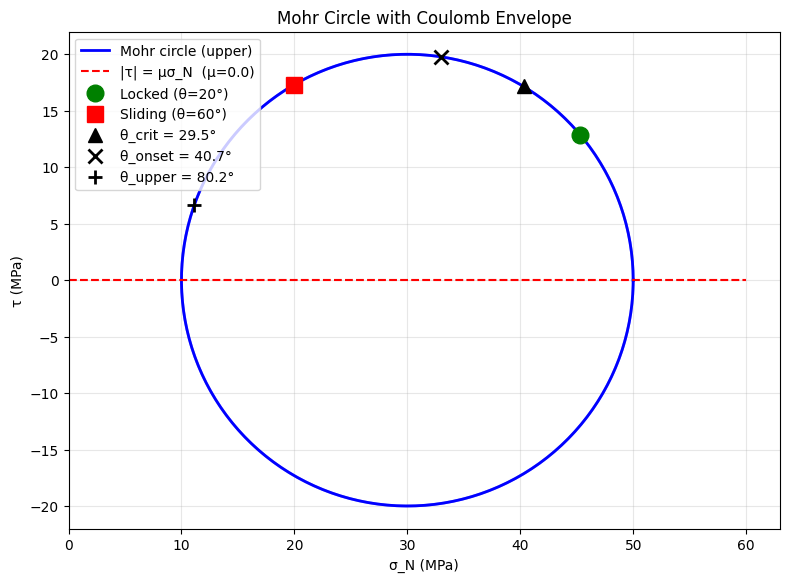

In [120]:
fig, ax = plt.subplots(figsize=(8, 6))

theta_range = np.linspace(0, np.pi, 300)
sN_range, tau_range = mohr_tractions(theta_range)
ax.plot(sN_range, tau_range, 'b-', lw=2, label='Mohr circle (upper)')
ax.plot(sN_range, -tau_range, 'b-', lw=2, alpha=0.4)

sN_env = np.linspace(0, S1 * 1.2, 100)
ax.plot(sN_env, MU * sN_env, 'r--', lw=1.5, label=f'|τ| = μσ_N  (μ={MU})')
ax.plot(sN_env, -MU * sN_env, 'r--', lw=1.5, alpha=0.4)

ax.plot(sN_locked, tau_locked, 'go', ms=12, zorder=5,
        label=f'Locked (θ={np.degrees(THETA_LOCKED):.0f}°)')
ax.plot(sN_sliding, tau_sliding, 'rs', ms=12, zorder=5,
        label=f'Sliding (θ={np.degrees(THETA_SLIDING):.0f}°)')

sN_crit, tau_crit = mohr_tractions(theta_crit)
ax.plot(sN_crit, tau_crit, 'k^', ms=10, zorder=5,
        label=f'θ_crit = {np.degrees(theta_crit):.1f}°')

sN_on, tau_on = mohr_tractions(theta_onset)
sN_up, tau_up = mohr_tractions(theta_upper)
ax.plot(sN_on, tau_on, 'kx', ms=10, mew=2, zorder=5,
        label=f'θ_onset = {np.degrees(theta_onset):.1f}°')
ax.plot(sN_up, tau_up, 'k+', ms=10, mew=2, zorder=5,
        label=f'θ_upper = {np.degrees(theta_upper):.1f}°')

ax.set_xlabel('σ_N (MPa)')
ax.set_ylabel('τ (MPa)')
ax.set_title('Mohr Circle with Coulomb Envelope')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()


## 10. Solve — Sliding Test (θ = 27° ∈ failure zone)

Rebuild the same alpha-zero projected-Radau system with a prestress outside the Mohr-Coulomb cone. The total effective traction should be projected to the cone, tangential traction should oppose slip, and the gap should remain nonnegative.


In [121]:
# Previous global-resolution mesh builder kept for reference.
# builder_s = CrackMeshBuilder(
#     XMIN, XMAX, YMIN, YMAX, N_ELEM,
#     crack_theta=CRACK_THETA_SLIDING,
#     crack_x0=CRACK_X0, crack_y0=CRACK_Y0,
#     crack_length=CRACK_LENGTH,
#     element_type='tri', conforming=CONFORMING_CRACK_MESH, use_gmsh=True,
#     verbose=True,
# )
# mesh_s, el_p_s, el_u_s, crack_s, h_mesh_s = builder_s.build()

# Non-body-fitted Gmsh triangle mesh with a local size field around the true
# crack.  The crack line is only a Distance-field attractor; it is not
# fragmented into, or embedded in, the rectangle surface.
import gmsh
import meshio
from skfem import ElementTriP1
from skfem.io import from_meshio
from poroelasticity.cgporoelastostatics import ElementTriP1Bubble
from poroelasticity.crack_generator import RobustCrackGenerator
from poroelasticity.mesh_builder import line_rotated_xy


def build_gmsh_tri_mesh_refined_near_crack(
    xmin, xmax, ymin, ymax,
    theta, x0, y0, length,
    *,
    h_far,
    h_crack,
    band_inner,
    band_outer,
    msh_path='/tmp/local_crack_refined_tri.msh',
):
    X_fn, _ = line_rotated_xy(theta, x0, y0, length)
    XA = X_fn(0.0).reshape(2,)
    XB = X_fn(1.0).reshape(2,)

    gmsh.initialize()
    try:
        gmsh.option.setNumber('General.Verbosity', 0)
        gmsh.model.add('local_crack_refined_tri')

        rect = gmsh.model.occ.addRectangle(
            float(xmin), float(ymin), 0.0,
            float(xmax - xmin), float(ymax - ymin),
        )

        # This line is deliberately independent of the surface.  Gmsh uses it
        # for mesh sizing only, so the final triangles do not fit the crack.
        pA = gmsh.model.occ.addPoint(float(XA[0]), float(XA[1]), 0.0)
        pB = gmsh.model.occ.addPoint(float(XB[0]), float(XB[1]), 0.0)
        crack_line = gmsh.model.occ.addLine(pA, pB)

        gmsh.model.occ.synchronize()

        domain_tags = [tag for dim, tag in gmsh.model.getEntities(2)]
        gmsh.model.addPhysicalGroup(2, domain_tags, name='domain')
        gmsh.model.mesh.setSize(gmsh.model.getEntities(0), float(h_far))

        dist = gmsh.model.mesh.field.add('Distance')
        gmsh.model.mesh.field.setNumbers(dist, 'CurvesList', [crack_line])
        gmsh.model.mesh.field.setNumber(dist, 'Sampling', 200)

        thresh = gmsh.model.mesh.field.add('Threshold')
        gmsh.model.mesh.field.setNumber(thresh, 'InField', dist)
        gmsh.model.mesh.field.setNumber(thresh, 'SizeMin', float(h_crack))
        gmsh.model.mesh.field.setNumber(thresh, 'SizeMax', float(h_far))
        gmsh.model.mesh.field.setNumber(thresh, 'DistMin', float(band_inner))
        gmsh.model.mesh.field.setNumber(thresh, 'DistMax', float(band_outer))
        gmsh.model.mesh.field.setAsBackgroundMesh(thresh)

        gmsh.option.setNumber('Mesh.MshFileVersion', 2.2)
        gmsh.option.setNumber('Mesh.ElementOrder', 1)
        gmsh.option.setNumber('Mesh.Algorithm', 5)
        gmsh.option.setNumber('Mesh.RecombineAll', 0)

        gmsh.model.mesh.generate(2)
        gmsh.write(msh_path)
    finally:
        gmsh.finalize()

    msh = meshio.read(msh_path)
    tri_cells = [c for c in msh.cells if c.type == 'triangle']
    if not tri_cells:
        raise RuntimeError('Gmsh produced no triangle cells.')

    mesh = from_meshio(meshio.Mesh(points=msh.points, cells=tri_cells))
    mesh = mesh.remove_unused_nodes()

    bnd_labels = {
        'left':   lambda x: np.isclose(x[0], xmin),
        'right':  lambda x: np.isclose(x[0], xmax),
        'top':    lambda x: np.isclose(x[1], ymax),
        'bottom': lambda x: np.isclose(x[1], ymin),
    }
    return mesh.with_boundaries(bnd_labels)


GMSH_H_FAR_S = min(XMAX - XMIN, YMAX - YMIN) / float(N_ELEM)
GMSH_H_CRACK_S = GMSH_H_FAR_S / 4.0
GMSH_BAND_INNER_S = 0.25
GMSH_BAND_OUTER_S = 1.50

mesh_s = build_gmsh_tri_mesh_refined_near_crack(
    XMIN, XMAX, YMIN, YMAX,
    CRACK_THETA_SLIDING, CRACK_X0, CRACK_Y0, CRACK_LENGTH,
    h_far=GMSH_H_FAR_S,
    h_crack=GMSH_H_CRACK_S,
    band_inner=GMSH_BAND_INNER_S,
    band_outer=GMSH_BAND_OUTER_S,
)
el_p_s = ElementTriP1()
el_u_s = ElementTriP1Bubble()

X_crack_s, dXdt_s = line_rotated_xy(
    CRACK_THETA_SLIDING, CRACK_X0, CRACK_Y0, CRACK_LENGTH,
)
crack_s = RobustCrackGenerator(
    mesh=mesh_s, X=X_crack_s, dXdt=dXdt_s, d2Xdt2=None,
    verbose=True, align_min=0.01, dist_mult=GMSH_H_CRACK_S,
)
nfacets_s = len(crack_s.surrogate_facets)
crack_s.finalize()
h_mesh_s = float(np.max(mesh_s.param()))

print(
    f'Local Gmsh tri mesh: {mesh_s.nelements} elements, '
    f'{mesh_s.p.shape[1]} vertices, h_far={GMSH_H_FAR_S:.3e}, '
    f'h_crack={GMSH_H_CRACK_S:.3e}, h_max={h_mesh_s:.3e}'
)
print(f'Crack surrogate facets: {nfacets_s}')

bc_s = make_bc()

poro_s = CGPoroelastostatics(
    mesh=mesh_s,
    element_p=el_p_s,
    element_u=el_u_s,
    params=PARAMS, material=MATERIAL,
    crack=crack_s,
    model_params=CRACK_MODEL_PARAMS,
    intorder=6,
    scales=(SCALE_L, SCALE_EPS),
    bc=bc_s,
    P_scale=None,
    verbose=True,
    free_memory=False,
    enforcement_type='nodal',
    apply_transform=True,
    include_taylor=INCLUDE_TAYLOR,
        include_taylor_test=INCLUDE_TAYLOR_TEST,
    include_hessian=INCLUDE_HESSIAN,
    include_sbm=INCLUDE_SBM,
    taylor_method='nodal',
    lumped_coupling='consistent',
    crack_law='nonsmooth',
    rotate_crack_to_nt=True,
    bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
)

poro_s.strip_multiplier_dynamics()
projection_s, meta_s = poro_s.build_projection()
dyn_s = poro_s.build_first_order_dynamic_system(meta_s)

A_dyn_s          = dyn_s['A']
rhs_dyn_s        = dyn_s['rhs']
rhs_jac_dyn_s    = dyn_s['rhs_jac']
velocity_slice_s = dyn_s['velocity_slice']
n_base_s         = dyn_s['n_base']
comp_slices_s    = dyn_s['component_slices']

Np_s = poro_s.basis_p.N
Nu_s = poro_s.basis_u.N

print(f"Sliding mesh: {mesh_s.nelements} elements, {mesh_s.p.shape[1]} vertices")
print(f"n_base = {n_base_s}, |x| = {A_dyn_s.shape[0]}")


[RobustCrackGenerator] KDTree facet query: 122 candidates, 89 good (both endpoints within 1.0h, strict)
[RobustCrackGenerator] Facet hits: 54 | t-range=[0.000, 1.000]
[RobustCrackGenerator] 93 good facets (BOTH endpoints within h), 54 direct hits
[RobustCrackGenerator] Final: 93 good facets (no connectors)
[RobustCrackGenerator] TRI mesh detected
[RobustCrackGenerator] Diagonal crack detected
[EXTEND] Starting with 13 facets, t-range=[0.000000, 1.000000]
[EXTEND] Global t-range=[0.000000, 1.000000]
[EXTEND] Initial frontier (start): 44 facets
[EXTEND] Final: 13 facets, t-range=[0.000000, 1.000000]
[EXTEND] Starting with 13 facets, t-range=[0.000000, 1.000000]
[EXTEND] Global t-range=[0.000000, 1.000000]
[EXTEND] Initial frontier (start): 44 facets
[EXTEND] Final: 13 facets, t-range=[0.000000, 1.000000]
[RobustCrackGenerator] Articulation points: 11, removable: 2
[RobustCrackGenerator] Selected 13 connected facets
[RobustCrackGenerator] Selected t-range=[0.000, 1.000] | coverage vs goo

### 10aa. True crack vs SBM surrogate (sliding mesh)


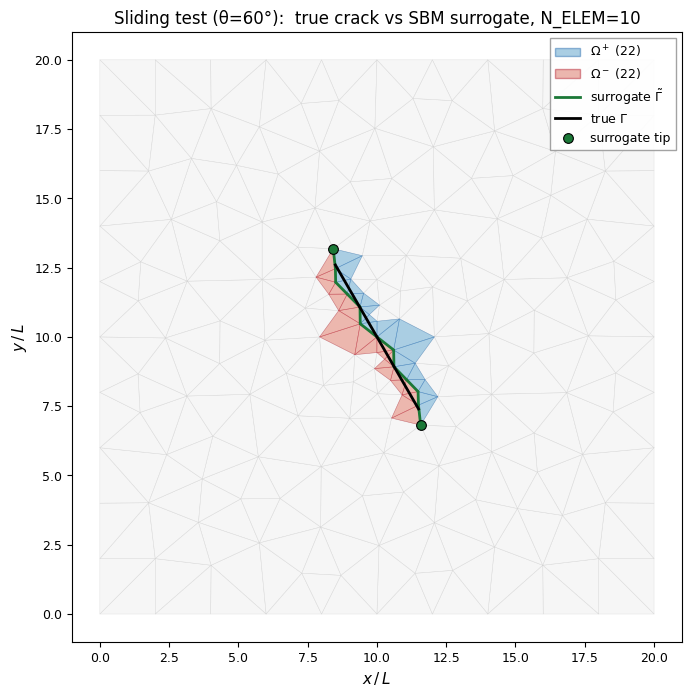

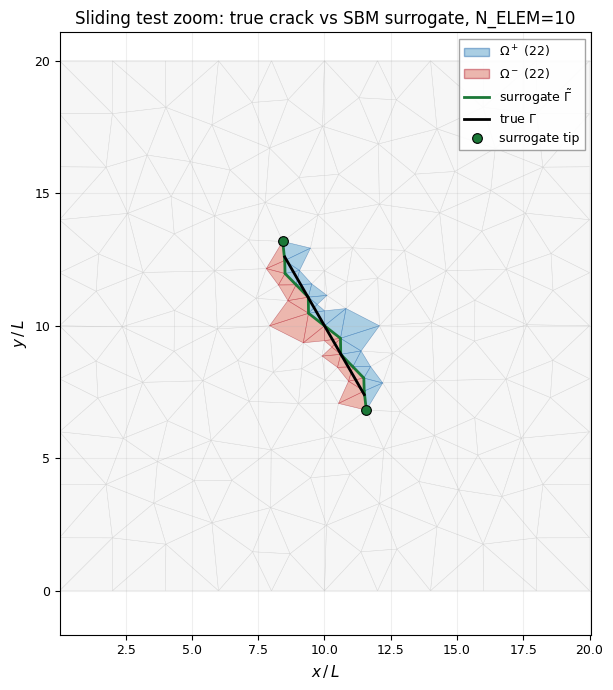

In [122]:
fig_sides_s, ax_sides_s = poro_s.plot_element_sides(
    show_true_crack=True,
    show_surrogate_crack=True,
    show_true_tips=True,
    show_surrogate_tips=True,
)
ax_sides_s.set_title(
    f'Sliding test (\u03b8={np.degrees(THETA_SLIDING):.0f}\u00b0):  '
    f'true crack vs SBM surrogate, N_ELEM={N_ELEM}'
)
plt.show()

_crack_center_plot_s = np.array([CRACK_X0, CRACK_Y0], dtype=float) / SCALE_L
_crack_tangent_plot_s = np.array([
    np.sin(CRACK_THETA_SLIDING),
    np.cos(CRACK_THETA_SLIDING),
], dtype=float)
_true_tip_pts_plot_s = np.column_stack([
    _crack_center_plot_s - 0.5 * CRACK_LENGTH / SCALE_L * _crack_tangent_plot_s,
    _crack_center_plot_s + 0.5 * CRACK_LENGTH / SCALE_L * _crack_tangent_plot_s,
])
_surrogate_pts_plot_s = np.asarray(
    poro_s._nodal_interface_info.get('lambda_coords', np.empty((2, 0))),
    dtype=float,
)
if _surrogate_pts_plot_s.ndim != 2:
    _surrogate_pts_plot_s = np.empty((2, 0))
elif _surrogate_pts_plot_s.shape[0] != 2 and _surrogate_pts_plot_s.shape[1] == 2:
    _surrogate_pts_plot_s = _surrogate_pts_plot_s.T
_surrogate_pts_plot_s = _surrogate_pts_plot_s[:2, :]
_zoom_pts_plot_s = np.hstack([_true_tip_pts_plot_s, _surrogate_pts_plot_s])
_zoom_min_plot_s = _zoom_pts_plot_s.min(axis=1)
_zoom_max_plot_s = _zoom_pts_plot_s.max(axis=1)
_zoom_pad_plot_s = max(3.0 * h_mesh_s, 0.08 * CRACK_LENGTH / SCALE_L)

fig_sides_zoom_s, ax_sides_zoom_s = poro_s.plot_element_sides(
    show_true_crack=True,
    show_surrogate_crack=True,
    show_true_tips=True,
    show_surrogate_tips=True,
)
ax_sides_zoom_s.set_xlim(
    _zoom_min_plot_s[0] - _zoom_pad_plot_s,
    _zoom_max_plot_s[0] + _zoom_pad_plot_s,
)
ax_sides_zoom_s.set_ylim(
    _zoom_min_plot_s[1] - _zoom_pad_plot_s,
    _zoom_max_plot_s[1] + _zoom_pad_plot_s,
)
ax_sides_zoom_s.set_aspect('equal', adjustable='box')
ax_sides_zoom_s.grid(alpha=0.2)
ax_sides_zoom_s.set_title(
    f'Sliding test zoom: true crack vs SBM surrogate, N_ELEM={N_ELEM}'
)
fig_sides_zoom_s.tight_layout()
plt.show()


In [123]:

info_s = poro_s._transform_info
n_c_s  = int(poro_s.n_lambda_q)

lam_s_sl_s = meta_s['lam_s_sl']

off_jmpu_s  = info_s['off_jmpu']
n_iu_s      = info_s['n_intf_u']
off_avgls_s = info_s['off_avgls']
off_jmpls_s = info_s['off_jmpls']
n_lsig_s    = info_s['n_lam_sig']

jmpu_n_idx_s = np.arange(off_jmpu_s, off_jmpu_s + n_c_s)
jmpu_t_idx_s = np.arange(off_jmpu_s + n_c_s, off_jmpu_s + n_iu_s)
jmpu_all_s   = np.concatenate([jmpu_n_idx_s, jmpu_t_idx_s])
jmpls_cols_s = np.arange(off_jmpls_s, off_jmpls_s + n_lsig_s)
n_extract_s = 2 * n_c_s

# SIM-consistent contact kinematics: evaluate the constitutive variables on
# the approximate true crack, u_hat = u_tilde + Delta_j u_,j.  The stored
# transformed [[u_n]], [[u_t]] block is only the surrogate nodal jump.
crack_mats_s = getattr(poro_s, '_crack_matrices', {})
C_exp_u_plus_s = crack_mats_s.get('C_exp_u_plus')
C_exp_u_minus_s = crack_mats_s.get('C_exp_u_minus')
if C_exp_u_plus_s is None or C_exp_u_minus_s is None:
    raise RuntimeError('Missing shifted displacement trace operators C_exp_u_plus/minus')
C_exp_u_jump_xy_s = (C_exp_u_plus_s + C_exp_u_minus_s).tocsr()
if info_s.get('rotated_to_nt', False):
    C_exp_u_jump_nt_s = (info_s['R_nt'] @ C_exp_u_jump_xy_s).tocsr()
else:
    C_exp_u_jump_nt_s = C_exp_u_jump_xy_s

T_inv_u_static_s = poro_s._T_inv[Np_s:Np_s + Nu_s, :].tocsr()
gap_u_hat_from_z_s = (C_exp_u_jump_nt_s @ T_inv_u_static_s).tocsr()
gap_u_raw_from_z_s = sp.csr_matrix(
    (np.ones(n_extract_s), (np.arange(n_extract_s), jmpu_all_s)),
    shape=(n_extract_s, n_base_s),
)
_gap_shift_norm_s = sp.linalg.norm(gap_u_hat_from_z_s - gap_u_raw_from_z_s)
_gap_hat_norm_s = max(1.0, sp.linalg.norm(gap_u_hat_from_z_s))
print(f"SIM shifted gap extraction ||hat-raw||/||hat|| = {_gap_shift_norm_s / _gap_hat_norm_s:.2e}")

R_v_s = dyn_s.get('R_v')
if R_v_s is not None:
    D_s = (C_exp_u_jump_nt_s @ R_v_s.T).tocsr()
else:
    D_s = C_exp_u_jump_nt_s.tocsr()

A_csr_s = poro_s.A.tocsr()
B_u_s = (A_csr_s[Np_s:Np_s + Nu_s, :][:, jmpls_cols_s]).tocsr()
if R_v_s is not None:
    B_u_s = (R_v_s @ B_u_s).tocsr()

dirichlet_local_s = np.array(
    [d - Np_s for d in np.asarray(getattr(poro_s, '_dirichlet_dof_set', []), dtype=int)
     if Np_s <= d < Np_s + Nu_s],
    dtype=int,
)
if dirichlet_local_s.size:
    B_u_s = B_u_s.tolil()
    B_u_s[dirichlet_local_s, :] = 0.0
    B_u_s = B_u_s.tocsr()

scale_s = h_mesh_s / 2.0
err_wc_s = sp.linalg.norm(B_u_s - scale_s * D_s.T) / sp.linalg.norm(B_u_s)
print(f"Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = {err_wc_s:.2e}")
print("  Exact contact weights are checked below through D_contact @ B.")

perm_s = [idx for k in range(n_c_s) for idx in (k, n_c_s + k)]
B_u_perm_s = B_u_s[:, perm_s].tocsr()
reaction_state_indices_s = jmpls_cols_s[perm_s]
reaction_rows_s = np.array([row for k in range(n_c_s) for row in (k, n_c_s + k)], dtype=int)

contacts_s = [
    {
        'vel_normal_idx': k,
        'vel_tangential_idx': [n_c_s + k],
        'mu': MU,
        'e': 0.0,
    }
    for k in range(n_c_s)
]

n_phys_s = A_dyn_s.shape[0]
n_aug_phys_s = n_phys_s
n_vel_s = n_aug_phys_s - n_base_s
n_extract_s = 2 * n_c_s
assert gap_u_hat_from_z_s.shape == (n_extract_s, n_base_s)
assert D_s.shape == (n_extract_s, n_vel_s)

gap_extract_dyn_s = sp.hstack(
    [gap_u_hat_from_z_s, sp.csr_matrix((n_extract_s, n_vel_s))],
    format='csr',
)
vel_extract_dyn_s = sp.hstack(
    [sp.csr_matrix((n_extract_s, n_base_s)), D_s],
    format='csr',
)
B_c_dyn_s = sp.vstack(
    [sp.csr_matrix((n_base_s, B_u_perm_s.shape[1])), B_u_perm_s],
    format='csr',
)
B_dyn_s = B_c_dyn_s
B_n_dyn_s = B_c_dyn_s[:, 0::2]
B_t_dyn_s = B_c_dyn_s[:, 1::2]

vel_contact_extract_dyn_s = vel_extract_dyn_s[reaction_rows_s, :].tocsr()
M_cc_s = (vel_contact_extract_dyn_s @ B_c_dyn_s).toarray()
off_diag_s = np.max(np.abs(M_cc_s - np.diag(np.diag(M_cc_s))))
omega_s = np.diag(M_cc_s)
omega_n_s = omega_s[0::2]
omega_t_s = omega_s[1::2]
print(f"sliding D_contact @ B diag range: {omega_s.min():.3e} .. {omega_s.max():.3e}; offdiag max {off_diag_s:.3e}")
# if USE_SBM:
#     print(f"  [SBM] omega_n range: {float(omega_n_s.min()):.3e} .. {float(omega_n_s.max()):.3e}")
#     print(f"  [SBM] omega_t range: {float(omega_t_s.min()):.3e} .. {float(omega_t_s.max()):.3e}")
#     print(f"  [SBM] omega_n - omega_t max: {np.max(np.abs(omega_n_s - omega_t_s)):.3e}")
# assert np.all(omega_s > 0), "Expected positive weak-form interface weights"
# if USE_SBM:
#     assert off_diag_s <= 1e-3 * max(1.0, np.max(np.abs(omega_s))), f"off-diag {off_diag_s:.3e} exceeds SBM tol vs diag {np.max(np.abs(omega_s)):.3e}"
# else:
#     assert off_diag_s < 1e-10 * max(1.0, np.max(np.abs(omega_s)))
# if USE_SBM:
#     _diff = np.max(np.abs(omega_n_s - omega_t_s))
#     _max  = max(1.0, np.max(np.abs(omega_n_s)))
#     assert _diff <= 1e-3 * _max, f"omega_n vs omega_t mismatch {_diff:.3e} > tol"
# else:
#     assert np.allclose(omega_n_s, omega_t_s, rtol=1e-12, atol=1e-12)

off_avgp_s = info_s['off_avgp']
n_intf_p_s = info_s['n_intf_p']
assert n_intf_p_s == n_c_s, "This notebook assumes one pore-pressure trace value per contact node"
# Taylor-shifted average pressure trace at the actual crack face:
# 0.5 (C_exp_p_plus + C_exp_p_minus) @ p_old gives {{p_hat}}.  Map
# y_dyn -> p_old via the static-side T_inv, padded for the velocity tail.
T_inv_p_static_s = poro_s._T_inv[0:Np_s, :].tocsr()
P_old_from_dyn_s = sp.hstack(
    [T_inv_p_static_s,
     sp.csr_matrix((Np_s, n_aug_phys_s - T_inv_p_static_s.shape[1]))],
    format='csr',
)
p_gamma_extract_dyn_s = (
    0.5 * (poro_s.C_exp_p_plus + poro_s.C_exp_p_minus) @ P_old_from_dyn_s
).tocsr()
pressure_normal_correction_s = -ALPHA_BIOT * (B_n_dyn_s @ p_gamma_extract_dyn_s)
pressure_normal_correction_s.eliminate_zeros()
# assert pressure_normal_correction_s.nnz == 0, "Alpha-zero phase should have no pressure-normal correction"
# print("Sliding alpha-zero matrix/unit checks: PASS")

# Keep the sliding branch executable on its own during smoke checks.
if '_contact_offset_vector' not in globals():
    def _contact_offset_vector(s0, w0):
        s0 = np.asarray(s0, dtype=float).ravel()
        w0 = np.asarray(w0, dtype=float).ravel()
        out = np.zeros(2 * s0.size)
        out[0::2] = s0
        out[1::2] = w0
        return out

if '_constraint_residual_inf' not in globals():
    def _constraint_residual_inf(model, y_phys):
        proj = getattr(model, 'algebraic_projection', None)
        slices = getattr(model, 'constraint_q_slices', None)
        if proj is None or not slices:
            return 0.0
        residual = proj.constraint_residual(np.asarray(y_phys, dtype=float))
        return float(max(np.linalg.norm(residual[sl], ord=np.inf) for sl in slices))

def _contact_history(y_hist, cs_or_n_phys, n_contact, s0, w0):
    y_hist = np.asarray(y_hist, dtype=float)
    if hasattr(cs_or_n_phys, 'reaction_history'):
        r_pert = np.asarray(cs_or_n_phys.reaction_history(y_hist), dtype=float)
    else:
        n_phys = int(cs_or_n_phys)
        r_pert = y_hist[:, n_phys:n_phys + 2 * n_contact]
    r_total = r_pert + _contact_offset_vector(s0, w0)[None, :]
    return r_pert, r_total, r_total[:, 0::2], r_total[:, 1::2]

if USE_LYSMER:
    _C_lysmer_sliding = lysmer_descriptor_block(
        poro_s, n_phys_s, n_base_s, a_p=LYSMER_AP, a_s=LYSMER_AS,
    )
else:
    _C_lysmer_sliding = None

if USE_WINKLER:
    _K_winkler_sliding = winkler_descriptor_block(
        poro_s, n_phys_s, n_base_s,
        u_state_indices=dyn_s['u_state_indices'],
        b_p=WINKLER_BP, b_s=WINKLER_BS,
    )
else:
    _K_winkler_sliding = None

def rhs_dyn_s_eff(t, y, *extra):
    out = rhs_dyn_s(t, y, *extra) + pressure_normal_correction_s @ y
    if _C_lysmer_sliding is not None:
        out = out - _C_lysmer_sliding @ y
    if _K_winkler_sliding is not None:
        out = out - _K_winkler_sliding @ y
    return out

def rhs_jac_dyn_s_eff(t, y, *extra):
    J = rhs_jac_dyn_s(t, y, *extra) + pressure_normal_correction_s
    if _C_lysmer_sliding is not None:
        J = J - _C_lysmer_sliding
    if _K_winkler_sliding is not None:
        J = J - _K_winkler_sliding
    return J

sigma_N_sliding, tau_sliding_val = mohr_tractions(THETA_SLIDING)
_sN_phys_s, _tau_phys_s = prestress_offsets(sigma_N_sliding, tau_sliding_val)
_s0_val_s = np.full(n_c_s, _sN_phys_s / Sigma_scale)
_w0_val_s = np.full(n_c_s, _tau_phys_s / Sigma_scale)
assert _s0_val_s.shape == (n_c_s,)
assert _w0_val_s.shape == (n_c_s,)
assert np.allclose(_s0_val_s, _sN_phys_s / Sigma_scale)
assert np.allclose(_w0_val_s, _tau_phys_s / Sigma_scale)

def get_s0_sliding(y):
    return _s0_val_s

def get_w0_sliding(y, k):
    return np.array([_w0_val_s[int(k)]])

flux_constraint_s = meta_s['constraints'][0]
avg_lam_s_sl_s = slice(off_avgls_s, off_avgls_s + n_lsig_s)
zero_avg_lam_s_s = {
    'g': lambda zf, *_a, _n=n_lsig_s: np.zeros(_n),
    'dg_dy': lambda zf, *_a, _n=n_lsig_s: np.zeros((_n, _n)),
    'y_slice': avg_lam_s_sl_s,
    'q_slice': avg_lam_s_sl_s,
}

cs_s = build_projected_radau_contact(
    A_dyn_s,
    rhs_dyn_s_eff,
    np.zeros(A_dyn_s.shape[0]),
    contacts=contacts_s,
    C_extract=gap_extract_dyn_s,
    D_extract=vel_extract_dyn_s,
    B=B_c_dyn_s,
    constraints=[flux_constraint_s, zero_avg_lam_s_s],
    component_slices=comp_slices_s,
    rhs_jac=rhs_jac_dyn_s_eff,
    get_s0=get_s0_sliding,
    get_w0=get_w0_sliding,
    normal_r='auto',
    friction_r='auto',
    endpoint_inactive_handling='natural_map',
    contact_law=CONTACT_LAW,
    reported_reaction_units='force',
    auto_rho_strategy='delassus',
    reaction_state_indices=reaction_state_indices_s,
    reaction_state_to_reported_scale=0.5,
    mask_reaction_state_in_smooth_rhs=True,
)
print("sliding contact system:", cs_s.A.shape, "unknowns", cs_s.y0.size, "avg traction constrained; jump traction stores 2r")


SIM shifted gap extraction ||hat-raw||/||hat|| = 6.63e-01
Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = 6.04e+00
  Exact contact weights are checked below through D_contact @ B.
sliding D_contact @ B diag range: 2.446e-01 .. 5.146e-01; offdiag max 1.944e-01
sliding contact system: (2343, 2343) unknowns 2343 avg traction constrained; jump traction stores 2r


In [124]:
n_aug_sliding = cs_s.y0.size
n_phys_sliding = A_dyn_s.shape[0]
factor = 100
nl_atol_sliding = np.full(n_aug_sliding, 1e-8*factor)
nl_rtol_sliding = np.full(n_aug_sliding, 1e-6*factor)
reaction_state_idx_s = getattr(cs_s, 'reaction_state_indices', None)
if reaction_state_idx_s is not None:
    # Reaction storage feeds the Radau dPi unknowns; use a small
    # relative tolerance so large-h impulse solves are not absolute-only.
    nl_atol_sliding[reaction_state_idx_s] = 1e-10
    nl_rtol_sliding[reaction_state_idx_s] = 1e-8*0
else:
    nl_atol_sliding[n_phys_sliding:] = 1e-10
    nl_rtol_sliding[n_phys_sliding:] = 1e-8*0

solver_opts_sliding = dict(cs_s.solver_opts)
solver_opts_sliding.update(
    tol=1e-8,
    max_iter=50,
    rhs_jac=cs_s.rhs_jac,
    linear_solver='petsc',
    petsc_options={
        'ksp_type': 'preonly',
        'pc_type': 'lu',
        'pc_factor_mat_solver_type': 'mumps',
    },
    petsc_reuse_steps=1,
)

integrator_opts_sliding = dict(cs_s.integrator_opts)
integrator_opts_sliding.update({'stages': 2, 'use_coupled_newton': True})

print(
    f"Solving sliding test: projected Radau IIA s=2 (adaptive PETSc/MUMPS), "
    f"h0={H0_ADAPTIVE}, tmax={TMAX}, rtol={ADAPTIVE_RTOL}, atol={ADAPTIVE_ATOL}"
)

_do_phase_split = (
    LOADING_MODE == 'displacement' and RAMP_HOLD_AFTER and T_LOAD < TMAX
)
_t_phase_end = float(T_LOAD) if _do_phase_split else float(TMAX)

print(f"  phase 1 (ramp): t_span = (0, {_t_phase_end})")

warm_r_sliding = coulomb_cone_warm_start(_s0_val_s, _w0_val_s, MU)
y0_sliding_init = cs_s.y0.copy()
if reaction_state_idx_s is not None:
    y0_sliding_init[reaction_state_idx_s] = (
        warm_r_sliding / cs_s.reaction_state_to_reported_scale
    )
else:
    y0_sliding_init[-2 * n_c_s:] = warm_r_sliding

skip_error_indices_sliding = [0]
if reaction_state_idx_s is not None:
    skip_error_indices_sliding.extend(
        i for i in range(8, 13) if i < len(cs_s.component_slices)
    )
else:
    skip_error_indices_sliding.append(len(cs_s.component_slices) - 1)

(
    t_sliding, y_sliding, h_sliding, fk_sliding, info_sliding, attempts_sliding
) = solve_nivp.solve_ivp_ns(
    fun=cs_s.rhs,
    t_span=(0, _t_phase_end),
    y0=y0_sliding_init,
    method='radau_iia',
    integrator_opts=integrator_opts_sliding,
    projection=cs_s.projection,
    solver='semismooth_newton',
    projection_opts={'component_slices': cs_s.component_slices},
    solver_opts=solver_opts_sliding,
    adaptive=True,
    h0=H0_ADAPTIVE,
    rtol=ADAPTIVE_RTOL,
    atol=ADAPTIVE_ATOL,
    skip_error_indices=skip_error_indices_sliding,
    active_set_filter=False,
    return_attempts=True,
    adaptive_opts=dict(
        h0=H0_ADAPTIVE,
        h_min=ADAPTIVE_H_MIN,
        h_max=ADAPTIVE_H_MAX,
        h_up=2.0,
        h_down=0.5,
        method_order=2,
    ),
    nl_atol=nl_atol_sliding,
    nl_rtol=nl_rtol_sliding,
    component_slices=cs_s.component_slices,
    verbose=True,
    A=cs_s.A,
    dae_var_weight='auto',
)

# --- Phase 2: ramp-then-hold ---------------------------------------------
# Rebuild poro_s, the dynamic system, and the projected-Radau contact wrapper
# under the hold BC (top pinned at TOP_COMPRESSION reached at T_LOAD).  Mesh,
# crack, scales, params, viscosity are identical, so the DOF layout matches
# and y_phase1[-1] can be passed straight through as the phase-2 IC.
if _do_phase_split:
    from solve_nivp.projected_radau_contact import build_projected_radau_contact as _bprc

    print(f"  phase 2 (hold): rebuilding poro with bc=make_hold_bc({-TOP_COMPRESSION})…")
    bc_hold = make_hold_bc(-TOP_COMPRESSION)
    poro_h = CGPoroelastostatics(
        mesh=mesh_s, element_p=el_p_s, element_u=el_u_s, params=PARAMS, material=MATERIAL,
        crack=crack_s, model_params=CRACK_MODEL_PARAMS, intorder=6,
        scales=(SCALE_L, SCALE_EPS), bc=bc_hold, P_scale=None,
        verbose=False, free_memory=False,
        enforcement_type='nodal', apply_transform=True,
        include_taylor=False, include_hessian=False, include_sbm=False,
        taylor_method='nodal',
        lumped_coupling='consistent',
        crack_law='nonsmooth', rotate_crack_to_nt=True,
        bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
    )
    poro_h.strip_multiplier_dynamics()
    _, meta_h = poro_h.build_projection()
    dyn_h = poro_h.build_first_order_dynamic_system(meta_h)
    A_dyn_h = dyn_h['A']
    rhs_dyn_h = dyn_h['rhs']
    rhs_jac_dyn_h = dyn_h['rhs_jac']
    n_base_h = dyn_h['n_base']
    comp_slices_h = dyn_h['component_slices']

    if A_dyn_h.shape != A_dyn_s.shape:
        raise RuntimeError(
            f"phase-2 DOF layout mismatch: A_dyn_h={A_dyn_h.shape} "
            f"vs A_dyn_s={A_dyn_s.shape}.  bc-driven Dirichlet pattern differs."
        )

    pressure_normal_correction_h = -ALPHA_BIOT * (B_n_dyn_s @ p_gamma_extract_dyn_s)
    pressure_normal_correction_h.eliminate_zeros()

    if USE_LYSMER:
        _C_lysmer_hold = lysmer_descriptor_block(
            poro_h, A_dyn_h.shape[0], n_base_h, a_p=LYSMER_AP, a_s=LYSMER_AS,
        )
    else:
        _C_lysmer_hold = None

    def rhs_dyn_h_eff(t, y, *extra):
        out = rhs_dyn_h(t, y, *extra) + pressure_normal_correction_h @ y
        if _C_lysmer_hold is not None:
            out = out - _C_lysmer_hold @ y
        return out

    def rhs_jac_dyn_h_eff(t, y, *extra):
        J = rhs_jac_dyn_h(t, y, *extra) + pressure_normal_correction_h
        if _C_lysmer_hold is not None:
            J = J - _C_lysmer_hold
        return J

    flux_constraint_h = meta_h['constraints'][0]
    cs_h = _bprc(
        A_dyn_h, rhs_dyn_h_eff, np.zeros(A_dyn_h.shape[0]),
        contacts=contacts_s,
        C_extract=gap_extract_dyn_s,
        D_extract=vel_extract_dyn_s,
        B=B_c_dyn_s,
        constraints=[flux_constraint_h, zero_avg_lam_s_s],
        component_slices=comp_slices_h,
        rhs_jac=rhs_jac_dyn_h_eff,
        get_s0=get_s0_sliding, get_w0=get_w0_sliding,
        normal_r='auto', friction_r='auto',
        endpoint_inactive_handling='natural_map',
        contact_law=CONTACT_LAW,
        reported_reaction_units='force',
        auto_rho_strategy='delassus',
        reaction_state_indices=reaction_state_indices_s,
        reaction_state_to_reported_scale=0.5,
        mask_reaction_state_in_smooth_rhs=True,
    )

    y0_phase2 = y_sliding[-1].copy()
    if y0_phase2.size != cs_h.y0.size:
        raise RuntimeError(
            f"phase-2 IC size mismatch: y0={y0_phase2.size} vs cs_h.y0={cs_h.y0.size}"
        )

    skip_error_indices_h = [0]
    if getattr(cs_h, 'reaction_state_indices', None) is not None:
        skip_error_indices_h.extend(
            i for i in range(8, 13) if i < len(cs_h.component_slices)
        )
    else:
        skip_error_indices_h.append(len(cs_h.component_slices) - 1)

    print(f"  phase 2 (hold): t_span = ({_t_phase_end}, {TMAX})")
    (
        t_p2, y_p2, h_p2, fk_p2, info_p2, attempts_p2
    ) = solve_nivp.solve_ivp_ns(
        fun=cs_h.rhs,
        t_span=(_t_phase_end, float(TMAX)),
        y0=y0_phase2,
        method='radau_iia',
        integrator_opts={**dict(cs_h.integrator_opts), 'stages': 2, 'use_coupled_newton': True},
        projection=cs_h.projection,
        solver='semismooth_newton',
        projection_opts={'component_slices': cs_h.component_slices},
        solver_opts={**dict(cs_h.solver_opts), 'tol': 1e-8, 'max_iter': 500,
                     'rhs_jac': cs_h.rhs_jac, 'linear_solver': 'petsc',
                     'petsc_options': {'ksp_type': 'preonly', 'pc_type': 'lu',
                                       'pc_factor_mat_solver_type': 'mumps'}},
        adaptive=True,
        h0=H0_ADAPTIVE, rtol=ADAPTIVE_RTOL, atol=ADAPTIVE_ATOL,
        skip_error_indices=skip_error_indices_h, active_set_filter=False, return_attempts=True,
        adaptive_opts=dict(h0=H0_ADAPTIVE, h_min=ADAPTIVE_H_MIN,
                           h_max=ADAPTIVE_H_MAX, h_up=2.0, h_down=0.5,
                           method_order=1),
        nl_atol=nl_atol_sliding, nl_rtol=nl_rtol_sliding,
        component_slices=cs_h.component_slices,
        verbose=True, A=cs_h.A, dae_var_weight='auto',
    )

    # Concatenate (drop the duplicate state at t = T_LOAD)
    t_sliding = np.concatenate([np.asarray(t_sliding), np.asarray(t_p2)[1:]])
    y_sliding = np.concatenate([np.asarray(y_sliding), np.asarray(y_p2)[1:]], axis=0)
    h_sliding = np.concatenate([np.asarray(h_sliding), np.asarray(h_p2)[1:]])
    fk_sliding = (np.concatenate([np.asarray(fk_sliding), np.asarray(fk_p2)[1:]], axis=0)
                  if fk_sliding is not None and fk_p2 is not None else fk_sliding)
    if isinstance(attempts_sliding, dict) and isinstance(attempts_p2, dict):
        attempts_sliding = {
            key: np.concatenate([np.asarray(attempts_sliding[key]), np.asarray(attempts_p2[key])])
            for key in attempts_sliding.keys() & attempts_p2.keys()
        }
    elif attempts_sliding is not None and attempts_p2 is not None:
        attempts_sliding = np.concatenate([np.asarray(attempts_sliding),
                                           np.asarray(attempts_p2)])

    # cs_s now points to the hold-phase model so post-processing
    # diagnostics evaluate the rhs in the phase-2 BC frame.
    cs_s = cs_h
    A_dyn_s = A_dyn_h

def _attempt_accept_array(attempts):
    if attempts is None:
        return None
    if isinstance(attempts, dict):
        return np.asarray(attempts.get('accepted', []), dtype=bool)
    return np.asarray(attempts, dtype=bool)

h_arr_sliding = np.asarray(h_sliding, dtype=float)
acc_sliding = _attempt_accept_array(attempts_sliding)
n_acc_sliding = int(acc_sliding.sum()) if acc_sliding is not None else len(t_sliding) - 1
n_rej_sliding = int((~acc_sliding).sum()) if acc_sliding is not None else 0
print(
    f"Done: {len(t_sliding)} states, t_final = {t_sliding[-1]:.4e}; "
    f"steps accepted={n_acc_sliding}, rejected={n_rej_sliding}; "
    f"h range=[{h_arr_sliding.min():.2e}, {h_arr_sliding.max():.2e}], "
    f"median h={np.median(h_arr_sliding):.2e}"
)

y_final_s = y_sliding[-1]
u_pert_max_s = np.max(np.abs(y_final_s[:n_base_s]))
v_pert_max_s = np.max(np.abs(y_final_s[n_base_s:n_phys_s]))
r_pert_final_s = np.asarray(cs_s.reaction_history(y_final_s), dtype=float)
print(f"sliding max |z|={u_pert_max_s:.3e}, max |v|={v_pert_max_s:.3e}, max |r_pert|={np.max(np.abs(r_pert_final_s)):.3e}")

sliding_jump = np.asarray((gap_extract_dyn_s @ y_sliding[:, :n_phys_s].T).T, dtype=float)
# True-crack hatted normal/tangential jumps from the shifted-interface extractor.
# This is the quantity to use for normal interpenetration, not the raw surrogate jump.
sliding_gap = sliding_jump[:, :n_c_s]
sliding_slip = sliding_jump[:, n_c_s:]
sliding_gap_phys = sliding_gap * DISP_UNIT_TO_PHYS
NORMAL_GAP_TOL_PHYS = max(1.0e-12, 1.0e-10 * DISP_UNIT_TO_PHYS)
NORMAL_GAP_TOL_NONDIM = NORMAL_GAP_TOL_PHYS / DISP_UNIT_TO_PHYS
sliding_vjump = np.asarray((vel_extract_dyn_s @ y_sliding[:, :n_phys_s].T).T, dtype=float)
sliding_vn = sliding_vjump[:, :n_c_s]
sliding_vt = sliding_vjump[:, n_c_s:]
r_pert_sliding, r_total_sliding_nd, r_n_sliding_nd, r_t_sliding_nd = _contact_history(
    y_sliding, cs_s, n_c_s, _s0_val_s, _w0_val_s
)
r_n_sliding = r_n_sliding_nd * Sigma_scale
r_t_sliding = r_t_sliding_nd * Sigma_scale
sliding_cone_margin = MU * r_n_sliding - np.abs(r_t_sliding)
sliding_constraint_inf = _constraint_residual_inf(cs_s.projected_radau_contact, y_final_s[:n_phys_s])

# The IC carries the prestress directly, so its cone margin is negative by
# construction.  Validate the trajectory from the first stepped state onwards.
post_ic = slice(1, None)
sliding_cone_margin_run = sliding_cone_margin[post_ic]
sliding_slip_run = sliding_slip[post_ic]
sliding_vt_run = sliding_vt[post_ic]
sliding_gap_run = sliding_gap[post_ic]
sliding_gap_phys_run = sliding_gap_phys[post_ic]
min_true_normal_gap_phys = float(np.min(sliding_gap_phys_run))
max_true_normal_closure_phys = max(0.0, -min_true_normal_gap_phys)
no_true_normal_interpenetration = min_true_normal_gap_phys >= -NORMAL_GAP_TOL_PHYS
final_vt = sliding_vt[-1]
final_slip = sliding_slip[-1]
final_tau = r_t_sliding[-1]
velocity_opposes = bool(np.max(np.abs(final_vt)) <= 1e-10 or np.all(final_tau * final_vt <= 1e-7))
slip_opposes = bool(np.max(np.abs(final_slip)) <= 1e-10 or np.all(final_tau * final_slip <= 1e-7))

sliding_tol = 1e-7
cone_tol_mpa = 1e-2
sliding_checks = {
    "gap_nonnegative": float(np.min(sliding_gap_run)) >= -NORMAL_GAP_TOL_NONDIM,
    "true_crack_normal_gap_nonnegative": no_true_normal_interpenetration,
    "slip_develops": float(np.max(np.abs(sliding_slip_run))) > 1e-10,
    "cone_not_violated": float(np.min(sliding_cone_margin_run)) >= -cone_tol_mpa,
    "final_total_traction_on_cone": float(np.max(np.abs(sliding_cone_margin[-1]))) <= cone_tol_mpa,
    "traction_opposes_motion_or_slip": velocity_opposes or slip_opposes,
    "constraints_satisfied": sliding_constraint_inf <= sliding_tol,
}
sliding_checks_pass = bool(all(sliding_checks.values()))
import json as _json
with open('/tmp/sliding_checks_results.json', 'w') as _f:
    _payload = {k: bool(v) for k, v in sliding_checks.items()}
    _payload.update({
        'sliding_checks_pass': sliding_checks_pass,
        'min_cone_margin_run_MPa': float(np.min(sliding_cone_margin_run)),
        'max_abs_final_cone_margin_MPa': float(np.max(np.abs(sliding_cone_margin[-1]))),
        'max_abs_slip_run': float(np.max(np.abs(sliding_slip_run))),
        'max_abs_v_t_run': float(np.max(np.abs(sliding_vt_run))),
        'min_gap': float(np.min(sliding_gap_run)),
        'min_true_normal_gap_phys_m': min_true_normal_gap_phys,
        'max_true_normal_closure_phys_m': max_true_normal_closure_phys,
        'normal_gap_tol_phys_m': NORMAL_GAP_TOL_PHYS,
        'no_true_normal_interpenetration': bool(no_true_normal_interpenetration),
        'sliding_constraint_inf': float(sliding_constraint_inf),
        'velocity_opposes': bool(velocity_opposes),
        'slip_opposes': bool(slip_opposes),
    })
    _json.dump(_payload, _f, indent=2)
print(f"sliding_checks_pass = {sliding_checks_pass}")
print(f"sliding_checks = {sliding_checks}")
print(f"sliding cone margin MPa: min(post-IC)={sliding_cone_margin_run.min():.6e}, "
      f"final max abs={np.max(np.abs(sliding_cone_margin[-1])):.6e}")
print(f"true normal gap: min(post-IC)={min_true_normal_gap_phys:.6e} m, "
      f"max closure={max_true_normal_closure_phys:.6e} m, "
      f"no interpenetration={no_true_normal_interpenetration}")
print(f"sliding constraint residual inf: {sliding_constraint_inf:.3e}")
print(f"SLIDING validation: {'PASS' if sliding_checks_pass else 'FAIL'}")


Solving sliding test: projected Radau IIA s=2 (adaptive PETSc/MUMPS), h0=1.008115219752334, tmax=18.00205749557739, rtol=0.001, atol=1e-06
  phase 1 (ramp): t_span = (0, 18.00205749557739)
[adaptive/DAE] detected 152 algebraic DOFs (of 2343 total) — excluded from error norm
[adaptive/emb] reject @ t=0, E=9.587e+02, h=1.008e+00 -> h_next=1.008e-01
[adaptive/emb] reject @ t=0, E=2.788e+02, h=1.008e-01 -> h_next=1.389e-02
[adaptive/emb] reject @ t=0, E=8.454e+01, h=1.389e-02 -> h_next=2.848e-03
[adaptive/emb] reject @ t=0, E=2.465e+01, h=2.848e-03 -> h_next=8.807e-04
[adaptive/emb] reject @ t=0, E=6.856e+00, h=8.807e-04 -> h_next=4.173e-04
[adaptive/emb] reject @ t=0, E=5.116e+00, h=4.173e-04 -> h_next=2.179e-04
[adaptive/emb] reject @ t=0, E=3.643e+00, h=2.179e-04 -> h_next=1.275e-04
[adaptive/emb] reject @ t=0, E=2.583e+00, h=1.275e-04 -> h_next=8.361e-05
[adaptive/emb] reject @ t=0, E=1.899e+00, h=8.361e-05 -> h_next=6.077e-05
[adaptive/emb] reject @ t=0, E=1.476e+00, h=6.077e-05 -> h_

KeyboardInterrupt: 

### 10b. Analytical Mohr-Coulomb Slip Reference

For a plane-strain Mode-II crack of half-length $a$ embedded in an infinite medium
under a uniform tangential stress drop $\Delta\tau = |\tau| - \mu\,\sigma_N$
on the crack plane, the Sneddon/Comninou solution gives an elliptic slip profile:

$$[[u_t]](x) = \frac{2\,\Delta\tau\,(1-\nu)}{G}\,\sqrt{a^2 - x^2},
\qquad [[u_t]]_{\max} = \frac{2\,\Delta\tau\,(1-\nu)\,a}{G}.$$

The unit square is finite, so this is an upper bound that the converged dynamic
solution should approach to within a $\mathcal{O}(a/L)$ correction.  This estimate
is **viscosity-independent** — it sets the static target the dynamic solution must
recover regardless of $\eta_v$.


Analytical max slip (physical units) = 2.2346e-03  (applied scale 1.0e-03)
FE jump-DOF coverage: outermost |s| = 1.0694 (closest jump DOF to tip), tips at |s| = 1 set to 0 explicitly


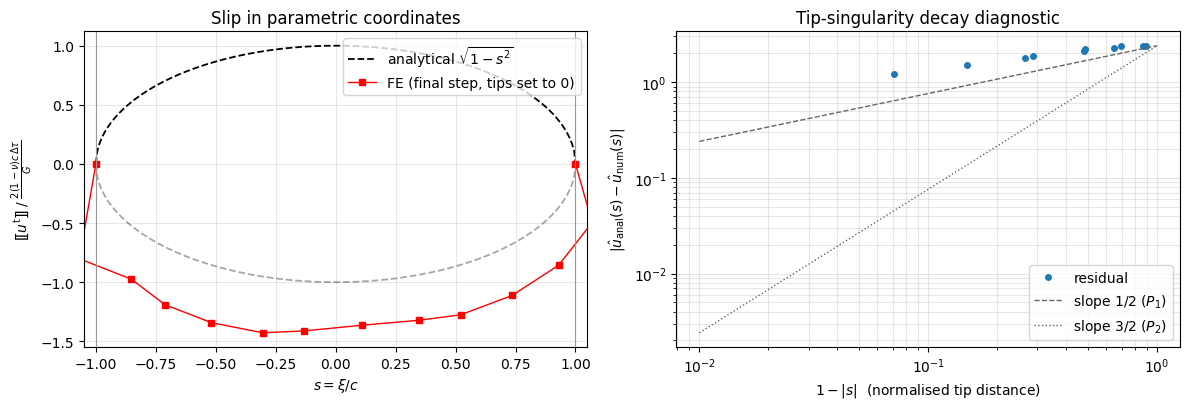

slip_max  analytical (phys) = 2.2346e-03
slip_max  FE          (phys)= -3.0491e-03   (centre, s ~ 0)
FE tip slip  |s| -> 1       = -1.7915e-03, -1.1070e-03   (should be 0 in the analytical limit)

Tip values are NOT expected to be zero in the FE solution because the
nearest jump DOF is one element-edge from the geometric tip, the
sqrt-singularity in D(xi) is unresolvable by polynomial bases, and the
finite box adds a domain correction.  The tip-decay log-log slope on
the right panel is the diagnostic: P1 elements should give slope 1/2,
P2 should give slope 3/2; departures indicate cone-tolerance noise or
BOX_SCALE-induced finite-domain bias.
Pollard L2 (interior |s|<0.95): err=3.140e-03 m, ref=5.731e-03 m, rel=0.548


In [ ]:
# =============================================================================
# Slip profile vs Crouch-Starfield / Pollard-Segall analytical
# =============================================================================
# Numerical:   stored in DOF order, NOT arclength order — must be sorted by
#              actual contact-node coordinates (poro_s._nodal_interface_info).
# Analytical:  hat_u(s) = sqrt(1 - s^2), s = xi / c.
# Tip closure: outermost FE jump DOFs sit one element-edge inside the geometric
#              tip; the geometric tip itself has [[u_t]] = 0, so we explicitly
#              prepend / append (s = ±1, slip = 0).
# =============================================================================

# Analytical scale (was previously computed in a deleted preamble cell)
crack_half_length = CRACK_LENGTH / 2.0
delta_tau_mpa     = abs(tau_sliding_val) - MU * sigma_N_sliding

c_half        = crack_half_length
slip_max_anal = 2.0 * delta_tau_mpa * (1.0 - NU) * c_half / G_SHEAR
DISP_SCALE    = SCALE_L * SCALE_EPS
print(f"Analytical max slip (physical units) = {slip_max_anal:.4e}  (applied scale {DISP_SCALE:.1e})")

# --- Sort numerical slip by actual tangent coordinate along the crack -------
# Works for conforming AND SBM meshes: SBM surrogate nodes are off the true
# crack but their projection onto the principal axis still gives a valid
# arclength ordering.
slip_phys = np.asarray(sliding_slip[-1], dtype=float) * DISP_SCALE
n_nodes   = slip_phys.size

_contact_coords = np.asarray(
    poro_s._nodal_interface_info["lambda_coords"], dtype=float
)  # shape (dim, n_c)
_centered = _contact_coords - _contact_coords.mean(axis=1, keepdims=True)
_axis     = np.linalg.svd(_centered, full_matrices=False)[0][:, 0]
_xi_raw   = _axis @ _contact_coords
xi_phys   = _xi_raw - 0.5 * (_xi_raw.min() + _xi_raw.max())

_sort_order = np.argsort(xi_phys)
xi_phys     = xi_phys[_sort_order]
slip_phys   = slip_phys[_sort_order]
s_param     = xi_phys / c_half

# --- Augment with geometric-tip zero values --------------------------------
xi_with_tips      = np.concatenate(([-c_half], xi_phys, [c_half]))
slip_with_tips    = np.concatenate(([0.0],     slip_phys, [0.0]))
s_param_with_tips = xi_with_tips / c_half

print(f"FE jump-DOF coverage: outermost |s| = {np.max(np.abs(s_param)):.4f} "
      f"(closest jump DOF to tip), tips at |s| = 1 set to 0 explicitly")

# Normalised numerical and analytical slip
slip_norm_num   = slip_phys / slip_max_anal
slip_norm_anal  = np.sqrt(np.clip(1.0 - s_param ** 2, 0.0, None))

# --- Plot: parametric profile + tip-decay diagnostic ------------------------
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 4.2))

s_dense = np.linspace(-1, 1, 401)
ax_left.plot(s_dense, np.sqrt(1.0 - s_dense ** 2), 'k--', lw=1.3,
             label=r'analytical $\sqrt{1-s^2}$')
ax_left.plot(s_dense, -np.sqrt(1.0 - s_dense ** 2), 'k--', lw=1.3, alpha=0.35)
slip_norm_num_with_tips = slip_with_tips / slip_max_anal
ax_left.plot(s_param_with_tips, slip_norm_num_with_tips, 'rs-', ms=4, lw=1.0,
             label='FE (final step, tips set to 0)')
ax_left.set_xlabel(r'$s = \xi / c$')
ax_left.set_ylabel(r'$[\![u^{\rm t}]\!] \; / \; \frac{2(1-\nu)c\,\Delta\tau}{G}$')
ax_left.set_title('Slip in parametric coordinates')
ax_left.set_xlim(-1.05, 1.05)
ax_left.axvline(-1, color='0.6', lw=0.8); ax_left.axvline(1, color='0.6', lw=0.8)
ax_left.legend(loc='upper right')
ax_left.grid(alpha=0.3)

tip_dist  = 1.0 - np.abs(s_param)
err       = np.abs(slip_norm_anal - slip_norm_num)
mask      = (tip_dist > 0) & (err > 0)
ax_right.loglog(tip_dist[mask], err[mask], 'o', ms=4, label='residual')
ref_x = np.array([1e-2, 1.0])
ref_y_p1 = err[mask].max() * (ref_x / ref_x.max()) ** 0.5
ref_y_p2 = err[mask].max() * (ref_x / ref_x.max()) ** 1.5
ax_right.loglog(ref_x, ref_y_p1, '--', color='0.4', lw=1.0,
                label=r'slope $1/2$ ($P_1$)')
ax_right.loglog(ref_x, ref_y_p2, ':',  color='0.4', lw=1.0,
                label=r'slope $3/2$ ($P_2$)')
ax_right.set_xlabel(r'$1 - |s|$  (normalised tip distance)')
ax_right.set_ylabel(r'$|\hat u_{\rm anal}(s) - \hat u_{\rm num}(s)|$')
ax_right.set_title('Tip-singularity decay diagnostic')
ax_right.legend(loc='lower right')
ax_right.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# --- Reporter ---
print(f"slip_max  analytical (phys) = {slip_max_anal:.4e}")
print(f"slip_max  FE          (phys)= {slip_phys[np.argmin(np.abs(s_param))]:.4e}"
      f"   (centre, s ~ 0)")
print(f"FE tip slip  |s| -> 1       = {slip_phys[0]:.4e}, {slip_phys[-1]:.4e}"
      f"   (should be 0 in the analytical limit)")
print()
print("Tip values are NOT expected to be zero in the FE solution because the")
print("nearest jump DOF is one element-edge from the geometric tip, the")
print("sqrt-singularity in D(xi) is unresolvable by polynomial bases, and the")
print("finite box adds a domain correction.  The tip-decay log-log slope on")
print("the right panel is the diagnostic: P1 elements should give slope 1/2,")
print("P2 should give slope 3/2; departures indicate cone-tolerance noise or")
print("BOX_SCALE-induced finite-domain bias.")

slip_anal_phys = slip_max_anal * slip_norm_anal
mask_interior  = np.abs(s_param) < 0.95
err_l2 = float(np.linalg.norm(np.abs(slip_phys[mask_interior]) - np.abs(slip_anal_phys[mask_interior])))
ref_l2 = float(np.linalg.norm(np.abs(slip_anal_phys[mask_interior])))
print(f"Pollard L2 (interior |s|<0.95): err={err_l2:.3e} m, ref={ref_l2:.3e} m, "
      f"rel={err_l2 / max(ref_l2, 1e-30):.3f}")

### 10d. Energy Balance Check

For the perturbation formulation with $\alpha = 0$ and roller BCs, the bulk power
identity reads
$$\frac{d}{dt}\bigl(\text{KE} + U_\text{el}\bigr) + D_\text{vis,rate}
   = \bigl(B\,r_\text{total}\bigr)\cdot v,$$
where $D_\text{vis,rate} = v^\top C\,v$ is the bulk Kelvin-Voigt dissipation rate
and the right-hand side is the power exerted by the contact reactions on the
bulk velocity.  Integrating gives
$$\text{KE}(t) + U_\text{el}(t) + D_\text{vis}(t) - W_\text{contact}(t) \approx 0.$$

A **growing** residual is a numerical-conservation diagnostic: at fixed material
parameters, larger residual at higher viscosity points to under-resolved
time-stepping (e.g. controller skipping the contact block, $h_{\max}$ too large).


Energy balance (sliding test):
  final KE                       = 1.569e-01   (≈ 0 expected at QS)
  final W_el                     = 1.858e+00   (cumulative bulk elastic work)
  final D_vis (incl. Lysmer)     = 6.824e-01   (bulk viscous + boundary dashpot, both in C_op)
  final D_fric (weak)            = 5.900e+00   (-tangential total contact work)
  final D_fric (lumped nodal)    = 4.217e+00   (independent diagnostic)
  final D_lysmer (boundary)      = 0.000e+00   (Lysmer dashpot energy out)

  final W_contact     (r_total)  = -5.900e+00   (sum of pert + offset)
    final W_contact_normal       = -8.663e-15
    final W_contact_tangent      = -5.900e+00
  final W_contact_pert(r_pert )  = 2.697e+00   (what BULK eqn integrates)
  final W_offset_reference       = -8.597e+00   (offset contribution in total-traction diagnostic)

  Bulk identity (masked smooth operator, r_pert): 2.693e-04   (rel: 9.987e-05)
    KE + W_el + D_vis - W_contact_pert approx 0
  Total-traction diagnostic residual

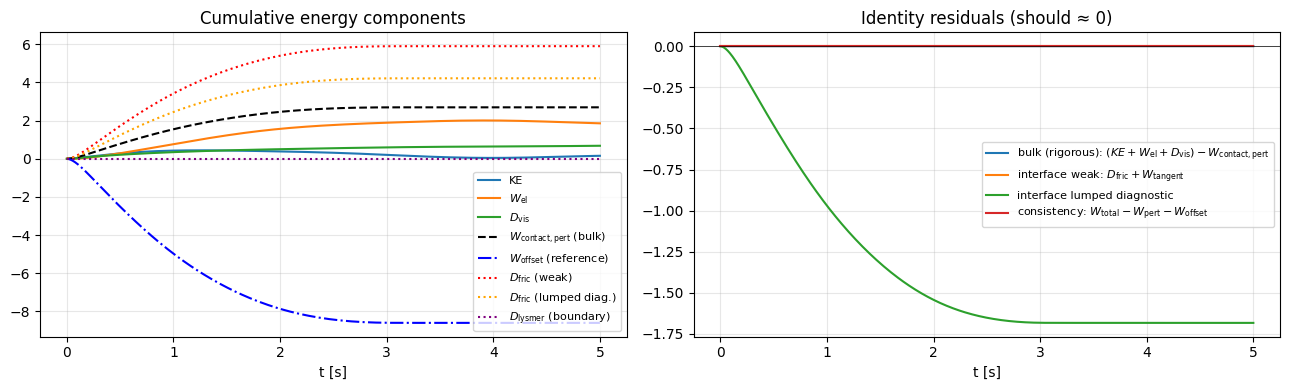

In [ ]:
y_hist_s = np.asarray(y_sliding, dtype=float)
t_arr_s  = np.asarray(t_sliding, dtype=float)

# ── Operators in the descriptor frame ──────────────────────────────────────
# Use the same smooth operator seen by projected Radau.  The raw descriptor
# Jacobian still contains columns for the stored jump-traction state, but those
# columns are masked during time stepping because B_c_dyn_s @ dPi supplies the
# contact coupling explicitly.  Leaving them in K_op double-counts contact work.
J0 = rhs_jac_dyn_s_eff(0.0, np.zeros(A_dyn_s.shape[0])).tocsr().tolil()
_reaction_state_idx_energy = getattr(cs_s, 'reaction_state_indices', None)
if _reaction_state_idx_energy is not None:
    J0[:, np.asarray(_reaction_state_idx_energy, dtype=int)] = 0.0
J0 = J0.tocsr()
A0 = A_dyn_s.tocsr()

mom_rows  = slice(n_base_s, n_phys_sliding)
base_cols = slice(0, n_base_s)
vel_cols  = slice(n_base_s, n_phys_sliding)

# All extracted from the descriptor Jacobian / mass; signs match the
# convention   M vdot = -K z - C v + B [[t_pert]].
K_op = -(J0[mom_rows, :][:, base_cols]).tocsr()   # rotated-frame stiffness
C_op = -(J0[mom_rows, :][:, vel_cols]).tocsr()    # viscous tangent
M_op = (A0[mom_rows, :][:, vel_cols]).tocsr()     # FE mass

# ── State histories ─────────────────────────────────────────────────────────
z_hist      = y_hist_s[:, :n_base_s]
v_hist      = y_hist_s[:, n_base_s:n_phys_sliding]

# The contact law/postprocessing uses the physical transmitted traction r.
# The poroelastic state stores [[t]] = 2r in the jump-traction multiplier block,
# and B_c_dyn_s is the matrix for that storage coordinate.
r_pert_hist = np.asarray(cs_s.reaction_history(y_hist_s), dtype=float)
reaction_scale_s = np.asarray(cs_s.reaction_state_to_reported_scale, dtype=float).ravel()
if reaction_scale_s.size == 1:
    reaction_scale_s = np.full(r_pert_hist.shape[1], float(reaction_scale_s[0]))
r_storage_pert_hist = r_pert_hist / reaction_scale_s[None, :]

sigma_offset_nondim = _contact_offset_vector(_s0_val_s, _w0_val_s)
sigma_offset_storage_nondim = sigma_offset_nondim / reaction_scale_s
r_total_hist = r_pert_hist + sigma_offset_nondim[None, :]
r_total_storage_hist = r_storage_pert_hist + sigma_offset_storage_nondim[None, :]

B_vel = B_c_dyn_s[n_base_s:n_phys_sliding, :].tocsr()
B_vel_n = B_vel[:, 0::2].tocsr()
B_vel_t = B_vel[:, 1::2].tocsr()

# Interface weights ω_k per contact node (the lumped FE measure)
omega_node = np.asarray(omega_n_s if 'omega_n_s' in globals() else omega_n, dtype=float)

# r_pert is interleaved [r_n_0, r_t_0, r_n_1, r_t_1, ...] in physical traction units.
r_n_pert_hist = r_pert_hist[:, 0::2]
r_t_pert_hist = r_pert_hist[:, 1::2]
r_n_total_storage_hist = r_total_storage_hist[:, 0::2]
r_t_total_storage_hist = r_total_storage_hist[:, 1::2]
r_n_total_hist_nd = r_n_pert_hist + _s0_val_s[None, :]
r_t_total_hist_nd = r_t_pert_hist + _w0_val_s[None, :]

# ── Per-step instantaneous power rates (nondim) ────────────────────────────
n_steps = len(t_arr_s)
KE          = np.zeros(n_steps)
P_elastic   = np.zeros(n_steps)   # rate of bulk elastic work: v · K_op · z
D_vis_rate  = np.zeros(n_steps)
P_contact         = np.zeros(n_steps)   # weak work rate from total reference traction r_total
P_contact_pert    = np.zeros(n_steps)   # weak work rate from r_pert; this is the bulk RHS contact power
P_offset_reference = np.zeros(n_steps)  # weak work rate from the constant offset used in the cone law
P_contact_normal  = np.zeros(n_steps)
P_contact_tangent = np.zeros(n_steps)
D_fric_rate       = np.zeros(n_steps)   # weak-form Coulomb dissipation: -P_contact_tangent
D_fric_lumped_rate = np.zeros(n_steps)  # independent lumped nodal estimate for comparison only
B_vel_offset = (B_vel @ sigma_offset_storage_nondim)  # constant in time

sliding_vt_arr = np.asarray(sliding_vt, dtype=float)

for k in range(n_steps):
    z_k = z_hist[k]
    v_k = v_hist[k]
    KE[k]          = 0.5 * float(v_k @ (M_op @ v_k))
    P_elastic[k]   = float(v_k @ (K_op @ z_k))
    D_vis_rate[k]  = float(v_k @ (C_op @ v_k))
    P_contact[k]   = float(v_k @ (B_vel @ r_total_storage_hist[k]))
    P_contact_pert[k]    = float(v_k @ (B_vel @ r_storage_pert_hist[k]))
    P_offset_reference[k] = float(v_k @ B_vel_offset)
    P_contact_normal[k]  = float(v_k @ (B_vel_n @ r_n_total_storage_hist[k]))
    P_contact_tangent[k] = float(v_k @ (B_vel_t @ r_t_total_storage_hist[k]))
    sigma_N_phys_nd = np.maximum(r_n_total_hist_nd[k], 0.0)
    D_fric_rate[k] = -P_contact_tangent[k]
    D_fric_lumped_rate[k] = float(np.sum(MU * sigma_N_phys_nd * np.abs(sliding_vt_arr[k]) * omega_node))

D_lysmer_rate = np.zeros(n_steps)
_have_lysmer = '_C_lysmer_sliding' in globals() and _C_lysmer_sliding is not None
if _have_lysmer:
    C_lysmer_vv = _C_lysmer_sliding[mom_rows, :][:, vel_cols].tocsr()
    for k in range(n_steps):
        v_k = v_hist[k]
        D_lysmer_rate[k] = float(v_k @ (C_lysmer_vv @ v_k))

# ── Cumulative integrals (trapezoidal) ──────────────────────────────────────
W_el              = np.zeros(n_steps)   # ∫ v · K_op z dτ  (bulk elastic work)
D_vis_int         = np.zeros(n_steps)
W_contact         = np.zeros(n_steps)   # ∫ v · B · [[t_total]] dτ
W_contact_pert    = np.zeros(n_steps)   # ∫ v · B · [[t_pert]]  dτ  (bulk RHS contact work)
W_offset_reference = np.zeros(n_steps)  # ∫ v · B · [[t_offset]] dτ; diagnostic reference work only
W_contact_normal  = np.zeros(n_steps)
W_contact_tangent = np.zeros(n_steps)
D_fric_int        = np.zeros(n_steps)
D_fric_lumped_int = np.zeros(n_steps)
for k in range(1, n_steps):
    dt_k = t_arr_s[k] - t_arr_s[k-1]
    W_el[k]       = W_el[k-1]       + 0.5 * (P_elastic[k]   + P_elastic[k-1])   * dt_k
    D_vis_int[k]  = D_vis_int[k-1]  + 0.5 * (D_vis_rate[k]  + D_vis_rate[k-1])  * dt_k
    W_contact[k]  = W_contact[k-1]  + 0.5 * (P_contact[k]   + P_contact[k-1])   * dt_k
    W_contact_pert[k]    = W_contact_pert[k-1]    + 0.5 * (P_contact_pert[k]    + P_contact_pert[k-1])    * dt_k
    W_offset_reference[k] = W_offset_reference[k-1] + 0.5 * (P_offset_reference[k] + P_offset_reference[k-1]) * dt_k
    W_contact_normal[k]  = W_contact_normal[k-1]  + 0.5 * (P_contact_normal[k]  + P_contact_normal[k-1])  * dt_k
    W_contact_tangent[k] = W_contact_tangent[k-1] + 0.5 * (P_contact_tangent[k] + P_contact_tangent[k-1]) * dt_k
    D_fric_int[k] = D_fric_int[k-1] + 0.5 * (D_fric_rate[k] + D_fric_rate[k-1]) * dt_k
    D_fric_lumped_int[k] = D_fric_lumped_int[k-1] + 0.5 * (D_fric_lumped_rate[k] + D_fric_lumped_rate[k-1]) * dt_k

D_lysmer_int = np.zeros(n_steps)
for k in range(1, n_steps):
    dt_k = t_arr_s[k] - t_arr_s[k-1]
    D_lysmer_int[k] = D_lysmer_int[k-1] + 0.5 * (D_lysmer_rate[k] + D_lysmer_rate[k-1]) * dt_k

# ── Identities ─────────────────────────────────────────────────────────────
# Bulk power balance for the actually integrated descriptor system:
#     d(KE)/dt = -P_elastic - D_vis_rate + P_contact_pert
#     => KE(t) + W_el(t) + D_vis(t) - W_contact_pert(t) ≈ 0.
# The offset is part of the reference traction used by the cone law; it is not
# an extra smooth bulk load in this shifted reaction variable formulation.
res_bulk_pert  = (KE + W_el + D_vis_int) - W_contact_pert
# Diagnostic only: what the same weak operator would do with total reference traction.
res_bulk_total = (KE + W_el + D_vis_int) - W_contact
# Weak-form interface sign check.  For sliding, tangential total traction should
# oppose tangential slip, so D_fric_int = -W_contact_tangent should be >= 0.
res_interface  = D_fric_int + W_contact_tangent
# Independent lumped nodal estimate; it need not be exact for consistent/SBM coupling.
res_interface_lumped = D_fric_lumped_int + W_contact_tangent
# Consistency (algebra): W_contact_total = W_contact_pert + W_offset_reference
res_consistency = W_contact - (W_contact_pert + W_offset_reference)

peak_w_total = max(float(np.max(np.abs(W_contact))), 1e-30)
peak_w_pert  = max(float(np.max(np.abs(W_contact_pert))), 1e-30)
peak_w_off   = max(float(np.max(np.abs(W_offset_reference))), 1e-30)
peak_res_bulk_pert  = float(np.max(np.abs(res_bulk_pert)))
peak_res_bulk_total = float(np.max(np.abs(res_bulk_total)))
peak_res_int        = float(np.max(np.abs(res_interface)))
peak_res_int_lumped = float(np.max(np.abs(res_interface_lumped)))
peak_res_consist    = float(np.max(np.abs(res_consistency)))
max_positive_friction_power = float(np.max(P_contact_tangent))
max_normal_contact_power = float(np.max(np.abs(P_contact_normal)))

print("Energy balance (sliding test):")
print(f"  final KE                       = {KE[-1]:.3e}   (≈ 0 expected at QS)")
print(f"  final W_el                     = {W_el[-1]:.3e}   (cumulative bulk elastic work)")
print(f"  final D_vis (incl. Lysmer)     = {D_vis_int[-1]:.3e}   (bulk viscous + boundary dashpot, both in C_op)")
print(f"  final D_fric (weak)            = {D_fric_int[-1]:.3e}   (-tangential total contact work)")
print(f"  final D_fric (lumped nodal)    = {D_fric_lumped_int[-1]:.3e}   (independent diagnostic)")
print(f"  final D_lysmer (boundary)      = {D_lysmer_int[-1]:.3e}   (Lysmer dashpot energy out)")
print()
print(f"  final W_contact     (r_total)  = {W_contact[-1]:.3e}   (sum of pert + offset)")
print(f"    final W_contact_normal       = {W_contact_normal[-1]:.3e}")
print(f"    final W_contact_tangent      = {W_contact_tangent[-1]:.3e}")
print(f"  final W_contact_pert(r_pert )  = {W_contact_pert[-1]:.3e}   (what BULK eqn integrates)")
print(f"  final W_offset_reference       = {W_offset_reference[-1]:.3e}   (offset contribution in total-traction diagnostic)")
print()
print(f"  Bulk identity (masked smooth operator, r_pert): {peak_res_bulk_pert:.3e}   (rel: {peak_res_bulk_pert/peak_w_pert:.3e})")
print(f"    KE + W_el + D_vis - W_contact_pert approx 0")
print(f"  Total-traction diagnostic residual           : {peak_res_bulk_total:.3e}   (rel: {peak_res_bulk_total/peak_w_total:.3e})")
print(f"    KE + W_el + D_vis - W_contact_total; not a bulk identity here")
print(f"  Interface sign check (weak, total tangent)    : {peak_res_int:.3e}   (rel: {peak_res_int/max(float(np.max(np.abs(W_contact_tangent))), 1e-30):.3e})")
print(f"    D_fric_weak + W_contact_tangent_total approx 0 by definition")
print(f"  Interface check (lumped nodal diagnostic)     : {peak_res_int_lumped:.3e}   (rel: {peak_res_int_lumped/max(float(np.max(np.abs(W_contact_tangent))), 1e-30):.3e})")
print(f"  Algebraic consistency W_total = W_pert + W_off: {peak_res_consist:.3e}   (rel: {peak_res_consist/peak_w_total:.3e})")
print()
print(f"  Power diagnostics:")
print(f"    max positive tangential contact power = {max_positive_friction_power:.3e}  (should be <= solver tolerance for dissipative friction)")
print(f"    max |normal contact power|            = {max_normal_contact_power:.3e}  (should be small for closed no-penetration contact)")
print(f"    The offset enters the cone law as a reference traction.  In this formulation it is not added as a separate smooth bulk load.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, KE, label='KE')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, W_el, label=r'$W_\mathrm{el}$')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, D_vis_int, label=r'$D_\mathrm{vis}$')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, W_contact_pert, ls='--', color='black',
             label=r'$W_\mathrm{contact, pert}$ (bulk)')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, W_offset_reference, ls='-.', color='blue',
             label=r'$W_\mathrm{offset}$ (reference)')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, D_fric_int, ls=':', color='red',
             label=r'$D_\mathrm{fric}$ (weak)')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, D_fric_lumped_int, ls=':', color='orange',
             label=r'$D_\mathrm{fric}$ (lumped diag.)')
axes[0].plot(t_arr_s * TIME_UNIT_TO_PHYS, D_lysmer_int, ls=':', color='purple',
             label=r'$D_\mathrm{lysmer}$ (boundary)')
axes[0].set_xlabel('t [s]')
axes[0].set_title('Cumulative energy components')
axes[0].legend(loc='best', fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].plot(t_arr_s * TIME_UNIT_TO_PHYS, res_bulk_pert,
             label=r'bulk (rigorous): $(KE+W_\mathrm{el}+D_\mathrm{vis}) - W_\mathrm{contact, pert}$')
axes[1].plot(t_arr_s * TIME_UNIT_TO_PHYS, res_interface,
             label=r'interface weak: $D_\mathrm{fric} + W_\mathrm{tangent}$')
axes[1].plot(t_arr_s * TIME_UNIT_TO_PHYS, res_interface_lumped,
             label=r'interface lumped diagnostic')
axes[1].plot(t_arr_s * TIME_UNIT_TO_PHYS, res_consistency,
             label=r'consistency: $W_\mathrm{total} - W_\mathrm{pert} - W_\mathrm{offset}$')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('t [s]')
axes[1].set_title('Identity residuals (should ≈ 0)')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


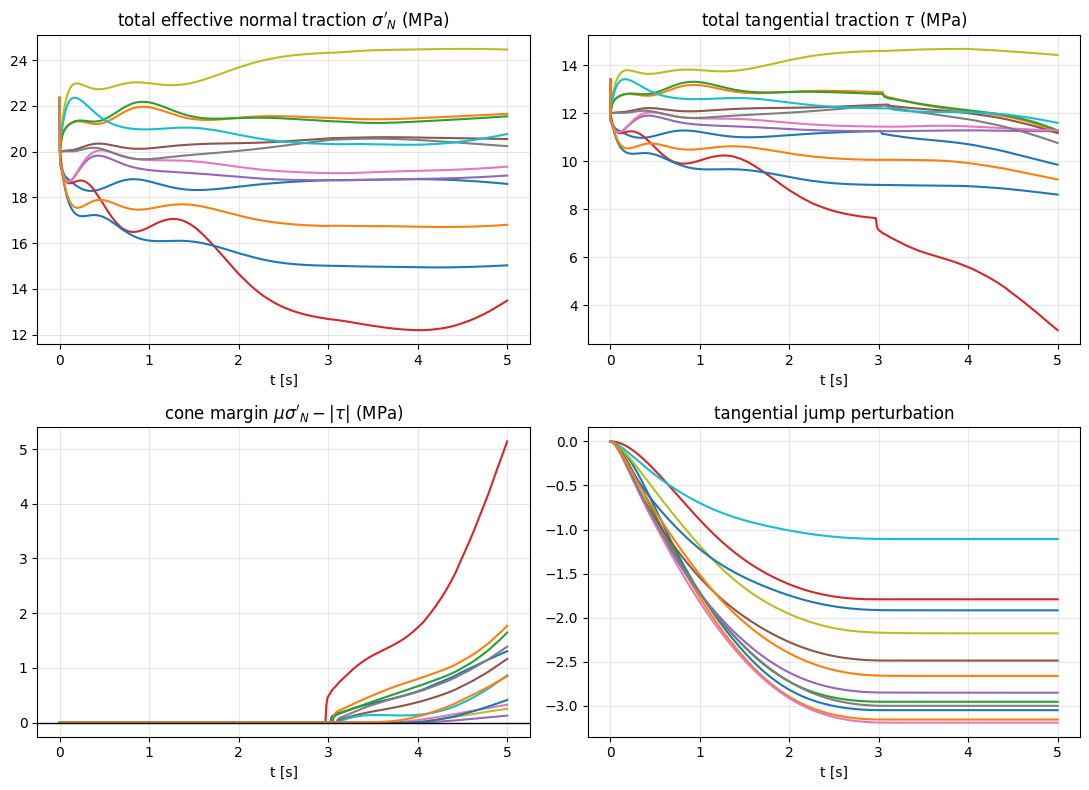

final min cone margin MPa 0.12877449544389208
final max |cone margin| MPa 5.139102561927491


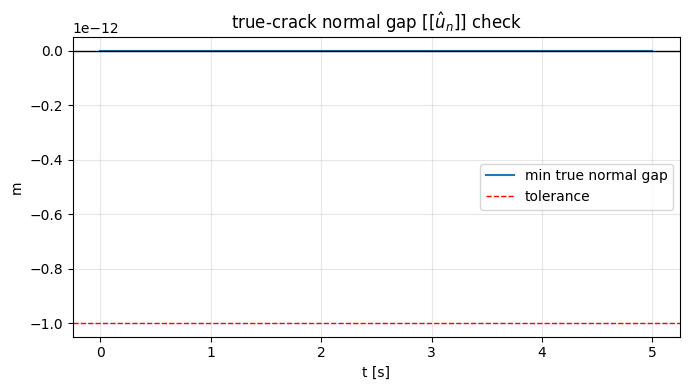

min true normal gap post-IC [m] -1.9665720864200655e-19
max true normal closure post-IC [m] 1.9665720864200655e-19
no true-normal interpenetration True


In [ ]:

# Plot sliding response in physical total effective traction units.
r_n = r_n_sliding
r_t = r_t_sliding
cone_margin = sliding_cone_margin

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0,0].plot(t_sliding * TIME_UNIT_TO_PHYS, r_n)
axes[0,0].set_title(r"total effective normal traction $\sigma'_N$ (MPa)")
axes[0,0].set_xlabel('t [s]')
axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(t_sliding * TIME_UNIT_TO_PHYS, r_t)
axes[0,1].set_title(r"total tangential traction $\tau$ (MPa)")
axes[0,1].set_xlabel('t [s]')
axes[0,1].grid(True, alpha=0.3)
axes[1,0].plot(t_sliding * TIME_UNIT_TO_PHYS, cone_margin)
axes[1,0].axhline(0, color='k', lw=1)
axes[1,0].set_title(r"cone margin $\mu\sigma'_N-|\tau|$ (MPa)")
axes[1,0].set_xlabel('t [s]')
axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(t_sliding * TIME_UNIT_TO_PHYS, sliding_slip)
axes[1,1].set_title(r"tangential jump perturbation")
axes[1,1].set_xlabel('t [s]')
axes[1,1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("final min cone margin MPa", cone_margin[-1].min())
print("final max |cone margin| MPa", np.max(np.abs(cone_margin[-1])))

fig_gap, ax_gap = plt.subplots(figsize=(7, 4))
ax_gap.plot(t_sliding * TIME_UNIT_TO_PHYS, np.min(sliding_gap_phys, axis=1), label='min true normal gap')
ax_gap.axhline(0, color='k', lw=1)
ax_gap.axhline(-NORMAL_GAP_TOL_PHYS, color='r', ls='--', lw=1, label='tolerance')
ax_gap.set_title(r"true-crack normal gap $[[\hat u_n]]$ check")
ax_gap.set_xlabel('t [s]')
ax_gap.set_ylabel('m')
ax_gap.legend()
ax_gap.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("min true normal gap post-IC [m]", min_true_normal_gap_phys)
print("max true normal closure post-IC [m]", max_true_normal_closure_phys)
print("no true-normal interpenetration", no_true_normal_interpenetration)


### 10aa. Total-stress smoothness across the crack

Variational identity check (rotated nt frame, avg/jmp transform): $[[\sigma_\mathrm{tot}\!\cdot\!n]]$ should be $\approx 0$ (no jump in *total* bulk traction across the crack), and the average $\{\!\{\sigma_\mathrm{tot}\!\cdot\!n\}\!\}$ should equal $\pm R$ (contact reaction). The *effective* traction does jump by $\alpha[[p]]\,n$ via the Biot decomposition — that's separate.


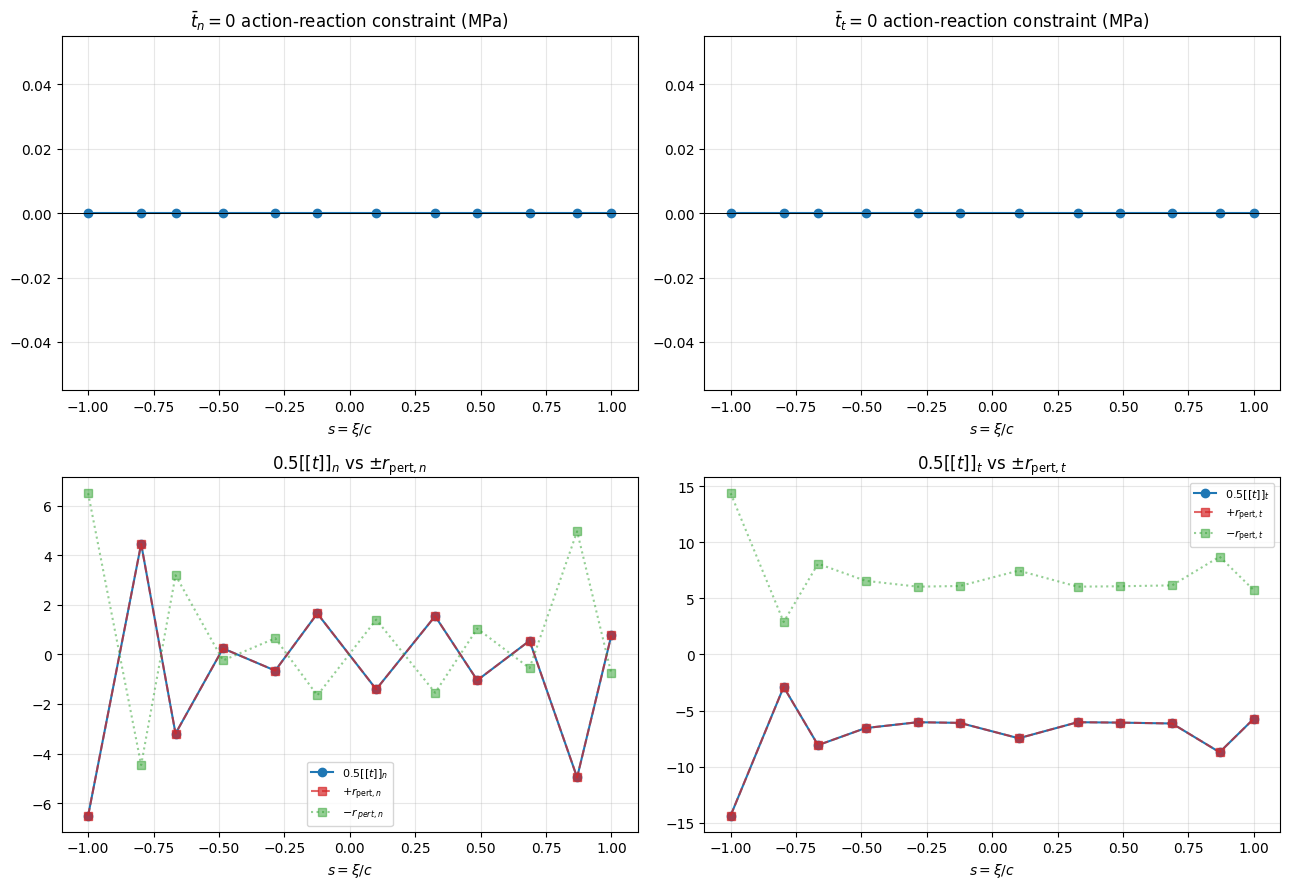

Interface traction identities (final time):
  max |avg(t)_n|                 = 0.000e+00 MPa
  max |avg(t)_t|                 = 0.000e+00 MPa
  max |0.5[[t]]_n - r_pert,n|   = 0.000e+00 MPa
  max |0.5[[t]]_n + r_pert,n|   = 1.301e+01 MPa  (smaller one gives sign convention)
  max |0.5[[t]]_t - r_pert,t|   = 0.000e+00 MPa
  max |0.5[[t]]_t + r_pert,t|   = 2.873e+01 MPa

For reference: per-side TOTAL effective traction range  R_n: [13.49, 24.46] MPa,  R_t: [2.96, 14.43] MPa


In [ ]:
# === 10aa. Interface traction-state diagnostics =============================
# Rotated-nt + avg/jmp traction multiplier convention:
#     avg = 0.5 (t^+ + t^-)       -> action-reaction constraint, should be zero
#     jmp = t^+ - t^- = 2 r       -> transmitted traction storage coordinate
# The contact law and plots use the physical transmitted traction r = 0.5*jmp.

info_st = poro_s._transform_info
off_avgls_s = info_st.get('off_avgls', None)
off_jmpls_s = info_st['off_jmpls']

y_final_s = np.asarray(y_sliding[-1], dtype=float)

# Layout (rotated_to_nt + avg/jmp): block-grouped, n then t.
jmp_sigma_n_nondim = y_final_s[off_jmpls_s + 0          : off_jmpls_s + n_c_s    ]
jmp_sigma_t_nondim = y_final_s[off_jmpls_s + n_c_s      : off_jmpls_s + 2 * n_c_s]
half_jmp_sigma_n_MPa = 0.5 * jmp_sigma_n_nondim * Sigma_scale
half_jmp_sigma_t_MPa = 0.5 * jmp_sigma_t_nondim * Sigma_scale

if off_avgls_s is not None:
    avg_sigma_n_nondim = y_final_s[off_avgls_s + 0          : off_avgls_s + n_c_s    ]
    avg_sigma_t_nondim = y_final_s[off_avgls_s + n_c_s      : off_avgls_s + 2 * n_c_s]
    avg_sigma_n_MPa = avg_sigma_n_nondim * Sigma_scale
    avg_sigma_t_MPa = avg_sigma_t_nondim * Sigma_scale
else:
    avg_sigma_n_MPa = avg_sigma_t_MPa = None

# Contact reactions in physical transmitted-traction units, interleaved [n0,t0,n1,t1,...].
r_pert_final_nondim = np.asarray(cs_s.reaction_history(y_final_s), dtype=float)
offset_final = np.zeros(2 * n_c_s)
offset_final[0::2] = _s0_val_s
offset_final[1::2] = _w0_val_s
r_total_final_nondim = r_pert_final_nondim + offset_final

R_n_MPa     = r_total_final_nondim[0::2] * Sigma_scale
R_t_MPa     = r_total_final_nondim[1::2] * Sigma_scale
rp_n_MPa    = r_pert_final_nondim[0::2]  * Sigma_scale
rp_t_MPa    = r_pert_final_nondim[1::2]  * Sigma_scale

# --- Sort by actual tangent coordinate along the crack ----------------------
_contact_coords = np.asarray(
    poro_s._nodal_interface_info['lambda_coords'], dtype=float
)
_centered    = _contact_coords - _contact_coords.mean(axis=1, keepdims=True)
_axis        = np.linalg.svd(_centered, full_matrices=False)[0][:, 0]
_xi_raw      = _axis @ _contact_coords
xi_phys      = _xi_raw - 0.5 * (_xi_raw.min() + _xi_raw.max())
_sort_order  = np.argsort(xi_phys)
xi_sorted    = xi_phys[_sort_order]
s_arc        = xi_sorted / max(np.max(np.abs(xi_sorted)), 1e-30)

half_jmp_sigma_n_MPa = half_jmp_sigma_n_MPa[_sort_order]
half_jmp_sigma_t_MPa = half_jmp_sigma_t_MPa[_sort_order]
if avg_sigma_n_MPa is not None:
    avg_sigma_n_MPa = avg_sigma_n_MPa[_sort_order]
    avg_sigma_t_MPa = avg_sigma_t_MPa[_sort_order]
R_n_MPa  = R_n_MPa [_sort_order]
R_t_MPa  = R_t_MPa [_sort_order]
rp_n_MPa = rp_n_MPa[_sort_order]
rp_t_MPa = rp_t_MPa[_sort_order]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

if avg_sigma_n_MPa is not None:
    axes[0, 0].plot(s_arc, avg_sigma_n_MPa, 'o-', color='C0')
    axes[0, 1].plot(s_arc, avg_sigma_t_MPa, 'o-', color='C0')
else:
    axes[0, 0].plot(s_arc, np.zeros_like(s_arc), 'o-', color='C0')
    axes[0, 1].plot(s_arc, np.zeros_like(s_arc), 'o-', color='C0')
axes[0, 0].axhline(0, color='k', lw=0.7)
axes[0, 0].set_title(r'$\bar t_n = 0$ action-reaction constraint (MPa)')
axes[0, 0].set_xlabel(r'$s = \xi / c$')
axes[0, 0].grid(alpha=0.3)
axes[0, 1].axhline(0, color='k', lw=0.7)
axes[0, 1].set_title(r'$\bar t_t = 0$ action-reaction constraint (MPa)')
axes[0, 1].set_xlabel(r'$s = \xi / c$')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(s_arc, half_jmp_sigma_n_MPa, 'o-',  color='C0', label=r'$0.5[[t]]_n$')
axes[1, 0].plot(s_arc,  rp_n_MPa,            's--', color='C3', alpha=0.7, label=r'$+r_{\mathrm{pert},n}$')
axes[1, 0].plot(s_arc, -rp_n_MPa,            's:',  color='C2', alpha=0.5, label=r'$-r_{\,pert,n}$')
axes[1, 0].set_title(r'$0.5[[t]]_n$ vs $\pm r_{\mathrm{pert},n}$')
axes[1, 0].set_xlabel(r'$s = \xi / c$')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(s_arc, half_jmp_sigma_t_MPa, 'o-',  color='C0', label=r'$0.5[[t]]_t$')
axes[1, 1].plot(s_arc,  rp_t_MPa,            's--', color='C3', alpha=0.7, label=r'$+r_{\mathrm{pert},t}$')
axes[1, 1].plot(s_arc, -rp_t_MPa,            's:',  color='C2', alpha=0.5, label=r'$-r_{\mathrm{pert},t}$')
axes[1, 1].set_title(r'$0.5[[t]]_t$ vs $\pm r_{\mathrm{pert},t}$')
axes[1, 1].set_xlabel(r'$s = \xi / c$')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Interface traction identities (final time):')
if avg_sigma_n_MPa is not None:
    print(f'  max |avg(t)_n|                 = {np.max(np.abs(avg_sigma_n_MPa)):.3e} MPa')
    print(f'  max |avg(t)_t|                 = {np.max(np.abs(avg_sigma_t_MPa)):.3e} MPa')
res_pos_n = np.max(np.abs(half_jmp_sigma_n_MPa - rp_n_MPa))
res_neg_n = np.max(np.abs(half_jmp_sigma_n_MPa + rp_n_MPa))
res_pos_t = np.max(np.abs(half_jmp_sigma_t_MPa - rp_t_MPa))
res_neg_t = np.max(np.abs(half_jmp_sigma_t_MPa + rp_t_MPa))
print(f'  max |0.5[[t]]_n - r_pert,n|   = {res_pos_n:.3e} MPa')
print(f'  max |0.5[[t]]_n + r_pert,n|   = {res_neg_n:.3e} MPa  (smaller one gives sign convention)')
print(f'  max |0.5[[t]]_t - r_pert,t|   = {res_pos_t:.3e} MPa')
print(f'  max |0.5[[t]]_t + r_pert,t|   = {res_neg_t:.3e} MPa')
print()
print(f'For reference: per-side TOTAL effective traction range  R_n: '
      f'[{R_n_MPa.min():.2f}, {R_n_MPa.max():.2f}] MPa,  '
      f'R_t: [{R_t_MPa.min():.2f}, {R_t_MPa.max():.2f}] MPa')


### 10a. Dashboard — Sliding

Full-field perturbation contours.  Expect visible displacement discontinuity at the crack
and stress redistribution near the crack tips.

In [ ]:
from poroelasticity.cg_dashboard import build_velocity_field

z_sliding = y_sliding[:, :n_base_s]

fields_sliding = poro_s.sol_to_fields_dict_with_dimensions(
    np.asarray(t_sliding),
    z_sliding.T,
    use_taylor_correction=False,
    constrained_l2=False,
)
fields_sliding['y_raw'] = z_sliding.T
fields_sliding['t_raw'] = np.asarray(t_sliding)

fields_sliding['v'] = build_velocity_field(
    poro_s, y_sliding, velocity_slice_s,
    scale_factor=DISP_SCALE / TIME_UNIT_TO_PHYS,
)

dashboard_sliding = CGPoroelasticDashboard(poro_s, fields_sliding, levels=40)
dashboard_sliding.show()


## 10e. Optional Slip-Weakening Friction / Rupture Extension

This section augments the dynamic state with one cumulative slip variable per contact node and uses a slip-weakening friction coefficient.  Set `SW_NUCLEATION_MODE = 'patch'` to start only a finite patch weakened/slipping, `'uniform'` to pre-weaken the whole interface, or `'none'` to start from the metastable prestress without an initial weakened patch.

The diagnostics below check both the Coulomb cone and the true-crack normal gap computed from the shifted/hatted extractor, so interpenetration is assessed on `[[\hat u_n]]`, not the raw surrogate jump.

In [ ]:
# # === Slip-weakening config, partial nucleation patch, and system build ======
# if CONTACT_LAW != 'soc_fb':
#     raise RuntimeError('Slip-weakening section expects CONTACT_LAW = soc_fb')

# Optional nucleation choice: 'patch' = finite central rupture seed,
# 'uniform' = whole-fault pre-weakening, 'none' = no initial weakening.
SW_NUCLEATION_MODE = 'patch'

# Slip-weakening law.  MU_STATIC_SW should match the constant-Coulomb value
# used above; MU_RES_SW < MU_STATIC_SW creates weakening.
MU_STATIC_SW = float(MU)
MU_RES_SW    = 0.30
DMU_SW       = MU_RES_SW - MU_STATIC_SW
DC_PHYS_SW   = 0.10 / 1000.0
DC_NONDIM_SW = DC_PHYS_SW / DISP_SCALE

if not (MU_RES_SW > 0.0 and MU_STATIC_SW >= MU_RES_SW):
    raise ValueError('Require 0 < MU_RES_SW <= MU_STATIC_SW')
if DC_NONDIM_SW <= 0.0:
    raise ValueError('DC_NONDIM_SW must be positive')

# Choose a metastable prestress for rupture nucleation: below static strength
# outside the patch, above residual strength in the pre-weakened patch.
SW_TAU_STATIC_UTILIZATION = 0.98
sigma_N_sw_phys = float(sigma_N_sliding)
tau_sign_sw = 1.0 if tau_sliding_val >= 0.0 else -1.0
tau_sw_phys = tau_sign_sw * SW_TAU_STATIC_UTILIZATION * MU_STATIC_SW * sigma_N_sw_phys
_s0_val_sw = np.full(n_c_s, sigma_N_sw_phys / Sigma_scale)
_w0_val_sw = np.full(n_c_s, tau_sw_phys / Sigma_scale)

# Contact-node coordinate along the crack, normalized to [-1, 1].
_contact_coords_raw_sw = np.asarray(
    poro_s._nodal_interface_info['lambda_coords'], dtype=float,
)
if _contact_coords_raw_sw.shape == (2, n_c_s):
    contact_coords_sw = _contact_coords_raw_sw.T
elif _contact_coords_raw_sw.shape == (n_c_s, 2):
    contact_coords_sw = _contact_coords_raw_sw
else:
    raise ValueError(
        'Expected lambda_coords with shape (2, n_c) or (n_c, 2); '
        f'got {_contact_coords_raw_sw.shape}'
    )
_centered_sw = contact_coords_sw - contact_coords_sw.mean(axis=0, keepdims=True)
_, _, _vh_sw = np.linalg.svd(_centered_sw, full_matrices=False)
_xi_sw = _centered_sw @ _vh_sw[0]
s_contact_sw = _xi_sw / max(np.max(np.abs(_xi_sw)), 1e-30)
sort_contact_sw = np.argsort(s_contact_sw)

# Optional initial weakening.  The cosine taper avoids a sharp discontinuity
# in mu(s) at the edge of the nucleation patch.
SW_PATCH_HALF_FRACTION = 0.28
SW_INITIAL_SLIP_DC = 0.5
mode_sw = str(SW_NUCLEATION_MODE).strip().lower().replace('-', '_')
abs_s_sw = np.abs(s_contact_sw)
taper_sw = np.zeros(n_c_s, dtype=float)
if mode_sw == 'patch':
    inside_patch_sw = abs_s_sw <= SW_PATCH_HALF_FRACTION
    taper_sw[inside_patch_sw] = 0.5 * (
        1.0 + np.cos(np.pi * abs_s_sw[inside_patch_sw] / SW_PATCH_HALF_FRACTION)
    )
elif mode_sw == 'uniform':
    inside_patch_sw = np.ones(n_c_s, dtype=bool)
    taper_sw[:] = 1.0
elif mode_sw == 'none':
    inside_patch_sw = np.zeros(n_c_s, dtype=bool)
else:
    raise ValueError("SW_NUCLEATION_MODE must be 'patch', 'uniform', or 'none'")
slip0_sw = SW_INITIAL_SLIP_DC * DC_NONDIM_SW * taper_sw


def mu_from_slip_sw(slip_state):
    slip_state = np.asarray(slip_state, dtype=float)
    s_eff = np.maximum(slip_state, 0.0)
    return MU_RES_SW - DMU_SW * np.exp(-s_eff / DC_NONDIM_SW)


mu0_sw = mu_from_slip_sw(slip0_sw)
static_margin_sw = MU_STATIC_SW * sigma_N_sw_phys - abs(tau_sw_phys)
local_margin0_sw = mu0_sw * sigma_N_sw_phys - abs(tau_sw_phys)
initial_sliding_nodes_sw = local_margin0_sw <= 0.0

print(f'Slip-weakening: mode={mode_sw!r}, mu_static={MU_STATIC_SW:.3f}, mu_res={MU_RES_SW:.3f}, Dc={DC_PHYS_SW:.3e} m')
print(f'  metastable prestress: sigma_N={sigma_N_sw_phys:.3f} MPa, tau={tau_sw_phys:.3f} MPa')
print(f'  static margin outside patch = {static_margin_sw:.3e} MPa')
print(f'  initially weakened/slipping nodes = {int(initial_sliding_nodes_sw.sum())}/{n_c_s}')
print(f'  initial mu range = [{mu0_sw.min():.4f}, {mu0_sw.max():.4f}]')

# Stability / stress-drop estimates.
G_phys_sw = G_SHEAR
D_len_sw = CRACK_LENGTH
loading_stiffness_per_m = G_phys_sw / D_len_sw
weakening_rate_per_m = -DMU_SW * sigma_N_sw_phys / DC_PHYS_SW
stable_qs_sw = loading_stiffness_per_m > weakening_rate_per_m
expd_slip_phys_sw = -DMU_SW * sigma_N_sw_phys * D_len_sw / G_phys_sw
print(f'  loading G/D             = {loading_stiffness_per_m:.3e} MPa/m')
print(f'  weakening -Dmu*sigma/Dc = {weakening_rate_per_m:.3e} MPa/m')
print(f'  QS-stable estimate      = {stable_qs_sw}')
print(f'  stress-drop slip scale  = {expd_slip_phys_sw:.3e} m')

# === State augmentation: append cumulative slip s_k per contact node =======
n_phys_old_sw = n_phys_s
slip_slice_sw = slice(n_phys_old_sw, n_phys_old_sw + n_c_s)
n_aug_sw = slip_slice_sw.stop

A_aug_sw = sp.block_diag([A_dyn_s, sp.eye(n_c_s, format='csr')], format='csr')

# Tangential true-crack slip-rate extraction, row order [n-block, t-block].
vel_t_extract_sw = vel_extract_dyn_s[n_c_s:2 * n_c_s, :].tocsr()


def rhs_sw(t, y, *extra):
    y_phys = y[:n_phys_old_sw]
    out = np.zeros(n_aug_sw)
    out[:n_phys_old_sw] = rhs_dyn_s_eff(t, y_phys)
    out[slip_slice_sw] = np.abs(vel_t_extract_sw @ y_phys)
    return out


def rhs_jac_sw(t, y, *extra):
    y_phys = y[:n_phys_old_sw]
    J_phys = rhs_jac_dyn_s_eff(t, y_phys)
    if not sp.issparse(J_phys):
        J_phys = sp.csr_matrix(J_phys)
    v_t = np.asarray(vel_t_extract_sw @ y_phys, dtype=float).ravel()
    J_slip = sp.diags(np.sign(v_t)) @ vel_t_extract_sw
    return sp.bmat(
        [
            [J_phys, sp.csr_matrix((n_phys_old_sw, n_c_s))],
            [J_slip, sp.csr_matrix((n_c_s, n_c_s))],
        ],
        format='csr',
    )

# Pad contact wiring with zero columns/rows for the slip-history block.
gap_extract_sw = sp.hstack(
    [gap_extract_dyn_s, sp.csr_matrix((gap_extract_dyn_s.shape[0], n_c_s))],
    format='csr',
)
vel_extract_sw = sp.hstack(
    [vel_extract_dyn_s, sp.csr_matrix((vel_extract_dyn_s.shape[0], n_c_s))],
    format='csr',
)
B_c_sw = sp.vstack(
    [B_c_dyn_s, sp.csr_matrix((n_c_s, B_c_dyn_s.shape[1]))],
    format='csr',
)
reaction_state_indices_sw = np.asarray(reaction_state_indices_s, dtype=int)

# Per-contact slip-weakening mu and analytical dmu/dy.
def _make_mu_sw(k):
    idx = slip_slice_sw.start + int(k)
    def _mu(y, t=None, Fk_val=None):
        return float(mu_from_slip_sw(y[idx]))
    return _mu


def _make_dmu_dy_sw(k):
    idx = slip_slice_sw.start + int(k)
    def _dmu(y, t=None, Fk_val=None):
        out = np.zeros(n_aug_sw)
        s_k = float(y[idx])
        if s_k > 0.0:
            out[idx] = (DMU_SW / DC_NONDIM_SW) * np.exp(-s_k / DC_NONDIM_SW)
        return out
    return _dmu


contacts_sw = [
    {
        'vel_normal_idx': k,
        'vel_tangential_idx': [n_c_s + k],
        'mu': _make_mu_sw(k),
        'dmu_dy': _make_dmu_dy_sw(k),
        'e': 0.0,
    }
    for k in range(n_c_s)
]


def get_s0_sw(y):
    return _s0_val_sw


def get_w0_sw(y, k):
    return np.array([_w0_val_sw[int(k)]])


component_slices_sw = list(comp_slices_s) + [slip_slice_sw]
cs_sw = build_projected_radau_contact(
    A_aug_sw,
    rhs_sw,
    np.zeros(n_aug_sw),
    contacts=contacts_sw,
    C_extract=gap_extract_sw,
    D_extract=vel_extract_sw,
    B=B_c_sw,
    constraints=[flux_constraint_s, zero_avg_lam_s_s],
    component_slices=component_slices_sw,
    rhs_jac=rhs_jac_sw,
    get_s0=get_s0_sw,
    get_w0=get_w0_sw,
    normal_r='auto',
    friction_r='auto',
    endpoint_inactive_handling='natural_map',
    contact_law='soc_fb',
    reported_reaction_units='force',
    auto_rho_strategy='delassus',
    reaction_state_indices=reaction_state_indices_sw,
    reaction_state_to_reported_scale=0.5,
    mask_reaction_state_in_smooth_rhs=True,
)
print(
    f'slip-weakening contact system: A={cs_sw.A.shape}, |y0|={cs_sw.y0.size}, '
    f'slip block={slip_slice_sw}, reaction state is [[t]]=2r',
)


Slip-weakening: mode='patch', mu_static=0.600, mu_res=0.300, Dc=1.000e-04 m
  metastable prestress: sigma_N=20.000 MPa, tau=11.760 MPa
  static margin outside patch = 2.400e-01 MPa
  initially weakened/slipping nodes = 2/12
  initial mu range = [0.5049, 0.6000]
  loading G/D             = 1.667e+03 MPa/m
  weakening -Dmu*sigma/Dc = 6.000e+04 MPa/m
  QS-stable estimate      = False
  stress-drop slip scale  = 3.600e-03 m
slip-weakening contact system: A=(2355, 2355), |y0|=2355, slip block=slice(2343, 2355, None), reaction state is [[t]]=2r


In [ ]:
# === Solve slip-weakening sliding test ===================================
n_aug_total_sw = cs_sw.y0.size
nl_atol_sw = np.full(n_aug_total_sw, 1e-8)
nl_rtol_sw = np.full(n_aug_total_sw, 1e-6)

# Slip block: absolute tolerance in nondimensional displacement units.
nl_atol_sw[slip_slice_sw] = min(1e-8, 1e-6 * DC_NONDIM_SW)
nl_rtol_sw[slip_slice_sw] = 0.0

# Reaction storage block is [[t]]=2r, so its tolerance is twice the r tolerance.
reaction_state_idx_sw = getattr(cs_sw, 'reaction_state_indices', None)
if reaction_state_idx_sw is not None:
    nl_atol_sw[reaction_state_idx_sw] = 2e-12
    nl_rtol_sw[reaction_state_idx_sw] = 0.0

solver_opts_sw = dict(cs_sw.solver_opts)
solver_opts_sw.update(
    tol=1e-8,
    max_iter=80,
    rhs_jac=cs_sw.rhs_jac,
    linear_solver='petsc',
    petsc_options={
        'ksp_type': 'preonly',
        'pc_type': 'lu',
        'pc_factor_mat_solver_type': 'mumps',
    },
    petsc_reuse_steps=50,
)
integrator_opts_sw = dict(cs_sw.integrator_opts)
integrator_opts_sw.update({'stages': 2, 'use_coupled_newton': True})


def coulomb_cone_warm_start_nodewise(s0_arr, w0_arr, mu_arr):
    s0_arr = np.asarray(s0_arr, dtype=float).ravel()
    w0_arr = np.asarray(w0_arr, dtype=float).ravel()
    mu_arr = np.asarray(mu_arr, dtype=float).ravel()
    out = np.zeros(2 * s0_arr.size)
    for k, (s0_k, w0_k, mu_k) in enumerate(zip(s0_arr, w0_arr, mu_arr)):
        out[2 * k:2 * k + 2] = coulomb_cone_warm_start(
            np.array([s0_k]), np.array([w0_k]), float(mu_k),
        )
    return out


# Initial condition: only the central patch starts weakened, and the reaction
# state is warm-started onto the local cone for mu(s0).
y0_sw_init = cs_sw.y0.copy()
y0_sw_init[slip_slice_sw] = slip0_sw
warm_r_sw = coulomb_cone_warm_start_nodewise(_s0_val_sw, _w0_val_sw, mu0_sw)
y0_sw_init[reaction_state_idx_sw] = warm_r_sw / cs_sw.reaction_state_to_reported_scale

skip_error_indices_sw = [0]
skip_error_indices_sw.extend(i for i in range(8, 13) if i < len(cs_sw.component_slices))

TMAX_SW_PHYS = TMAX_PHYS
TMAX_SW = TMAX_SW_PHYS / TIME_UNIT_TO_PHYS
print(
    f'Solving slip-weakening sliding: tmax={TMAX_SW:.4g} '
    f'({TMAX_SW_PHYS:.3g} s), h0={H0_ADAPTIVE}, contact_law=soc_fb',
)

(t_sw, y_sw, h_sw, fk_sw, info_sw, attempts_sw) = solve_nivp.solve_ivp_ns(
    fun=cs_sw.rhs,
    t_span=(0.0, float(TMAX_SW)),
    y0=y0_sw_init,
    method='radau_iia',
    integrator_opts=integrator_opts_sw,
    projection=cs_sw.projection,
    solver='semismooth_newton',
    projection_opts={'component_slices': cs_sw.component_slices},
    solver_opts=solver_opts_sw,
    adaptive=True,
    h0=H0_ADAPTIVE,
    rtol=ADAPTIVE_RTOL,
    atol=ADAPTIVE_ATOL,
    skip_error_indices=skip_error_indices_sw,
    active_set_filter=False,
    return_attempts=True,
    adaptive_opts=dict(
        h0=H0_ADAPTIVE,
        h_min=ADAPTIVE_H_MIN,
        h_max=ADAPTIVE_H_MAX,
        h_up=2.0,
        h_down=0.5,
        method_order=1,
    ),
    nl_atol=nl_atol_sw,
    nl_rtol=nl_rtol_sw,
    component_slices=cs_sw.component_slices,
    verbose=True,
    A=cs_sw.A,
    dae_var_weight='auto',
)

t_sw = np.asarray(t_sw, dtype=float)
y_sw = np.asarray(y_sw, dtype=float)
h_sw = np.asarray(h_sw, dtype=float)
acc_sw = _attempt_accept_array(attempts_sw)
n_acc_sw = int(acc_sw.sum()) if acc_sw is not None else len(t_sw) - 1
n_rej_sw = int((~acc_sw).sum()) if acc_sw is not None else 0

# --- Post-process: slip, jump, friction, reactions -------------------------
slip_state_sw = y_sw[:, slip_slice_sw]
slip_increment_sw = slip_state_sw - slip0_sw[None, :]
sliding_jump_all_sw = np.asarray((gap_extract_sw @ y_sw.T).T, dtype=float)
sliding_gap_sw = sliding_jump_all_sw[:, :n_c_s]
sliding_jump_sw = sliding_jump_all_sw[:, n_c_s:]
normal_gap_phys_sw = sliding_gap_sw * DISP_SCALE
NORMAL_GAP_TOL_PHYS_SW = max(1.0e-12, 1.0e-10 * DISP_SCALE)
min_normal_gap_post_ic_sw = float(np.min(normal_gap_phys_sw[1:])) if len(t_sw) > 1 else float(np.min(normal_gap_phys_sw))
max_normal_closure_sw = max(0.0, -min_normal_gap_post_ic_sw)
no_interpenetration_sw = min_normal_gap_post_ic_sw >= -NORMAL_GAP_TOL_PHYS_SW
sliding_vjump_sw = np.asarray((vel_extract_sw @ y_sw.T).T, dtype=float)
sliding_vn_sw = sliding_vjump_sw[:, :n_c_s]
sliding_vt_sw = sliding_vjump_sw[:, n_c_s:]
mu_eff_sw = mu_from_slip_sw(slip_state_sw)

r_pert_sw, r_total_sw_nd, r_n_sw_nd, r_t_sw_nd = _contact_history(
    y_sw, cs_sw, n_c_s, _s0_val_sw, _w0_val_sw,
)
r_n_sw = r_n_sw_nd * Sigma_scale
r_t_sw = r_t_sw_nd * Sigma_scale
cone_margin_sw = mu_eff_sw * r_n_sw - np.abs(r_t_sw)
SW_RUPTURE_SLIP_THRESHOLD_DC = 0.25
rupture_slip_threshold_sw = SW_RUPTURE_SLIP_THRESHOLD_DC * DC_NONDIM_SW
ruptured_nodes_sw = slip_increment_sw >= rupture_slip_threshold_sw
final_ruptured_nodes_sw = int(np.sum(ruptured_nodes_sw[-1]))
slip_rate_phys_sw = np.abs(sliding_vt_sw) * DISP_SCALE / TIME_UNIT_TO_PHYS

slip_max_phys = float(np.max(np.abs(sliding_jump_sw)) * DISP_SCALE)
s_max_nondim = float(np.max(slip_state_sw))
s_max_phys = s_max_nondim * DISP_SCALE
print(f'Done: {len(t_sw)} states, t_final={t_sw[-1]:.4e} ({t_sw[-1] * TIME_UNIT_TO_PHYS:.3g} s)')
print(f'  steps accepted={n_acc_sw}, rejected={n_rej_sw}; h range=[{h_sw.min():.2e}, {h_sw.max():.2e}]')
print(f'  max cumulative s (m)      = {s_max_phys:.3e}')
print(f'  max |[[u_t]]| (m)         = {slip_max_phys:.3e}')
print(f'  mu observed               = [{mu_eff_sw.min():.4f}, {mu_eff_sw.max():.4f}]')
print(f'  s/Dc reached              = {s_max_phys / DC_PHYS_SW:.3f}')
print(f'  slip/stress-drop estimate = {slip_max_phys / max(expd_slip_phys_sw, 1e-30):.3f}')
print(f'  ruptured nodes final      = {final_ruptured_nodes_sw}/{n_c_s} (threshold {SW_RUPTURE_SLIP_THRESHOLD_DC:.2f} Dc increment)')
print(f'  true normal gap min       = {min_normal_gap_post_ic_sw:.3e} m')
print(f'  true normal max closure   = {max_normal_closure_sw:.3e} m')
print(f'  no interpenetration       = {no_interpenetration_sw} (tol {NORMAL_GAP_TOL_PHYS_SW:.1e} m)')
print(f'  min cone margin post-IC   = {cone_margin_sw[1:].min():.3e} MPa')


Solving slip-weakening sliding: tmax=18 (5 s), h0=1.008115219752334, contact_law=soc_fb
[adaptive/DAE] detected 152 algebraic DOFs (of 2355 total) — excluded from error norm
[adaptive/emb] reject @ t=0, E=4.063e+02, h=1.008e+00 -> h_next=1.008e-01
[adaptive/emb] reject @ t=0, E=5.297e+01, h=1.008e-01 -> h_next=1.247e-02
[adaptive/emb] reject @ t=0, E=1.313e+01, h=1.247e-02 -> h_next=3.097e-03
[adaptive/emb] reject @ t=0, E=2.789e+00, h=3.097e-03 -> h_next=1.669e-03
[adaptive/emb] reject @ t=0, E=1.126e+00, h=1.669e-03 -> h_next=1.415e-03
[adaptive/emb] accept @ t=0 -> t+1.415e-03, E=8.668e-01, h_next=1.368e-03
[adaptive/emb] accept @ t=0.00141526 -> t+1.368e-03, E=5.057e-01, h_next=1.609e-03
[adaptive/emb] accept @ t=0.0027834 -> t+1.609e-03, E=4.453e-01, h_next=2.202e-03
[adaptive/emb] accept @ t=0.00439197 -> t+2.202e-03, E=5.055e-01, h_next=2.959e-03
[adaptive/emb] accept @ t=0.00659423 -> t+2.959e-03, E=5.330e-01, h_next=3.804e-03
[adaptive/emb] accept @ t=0.0095528 -> t+3.804e-03,

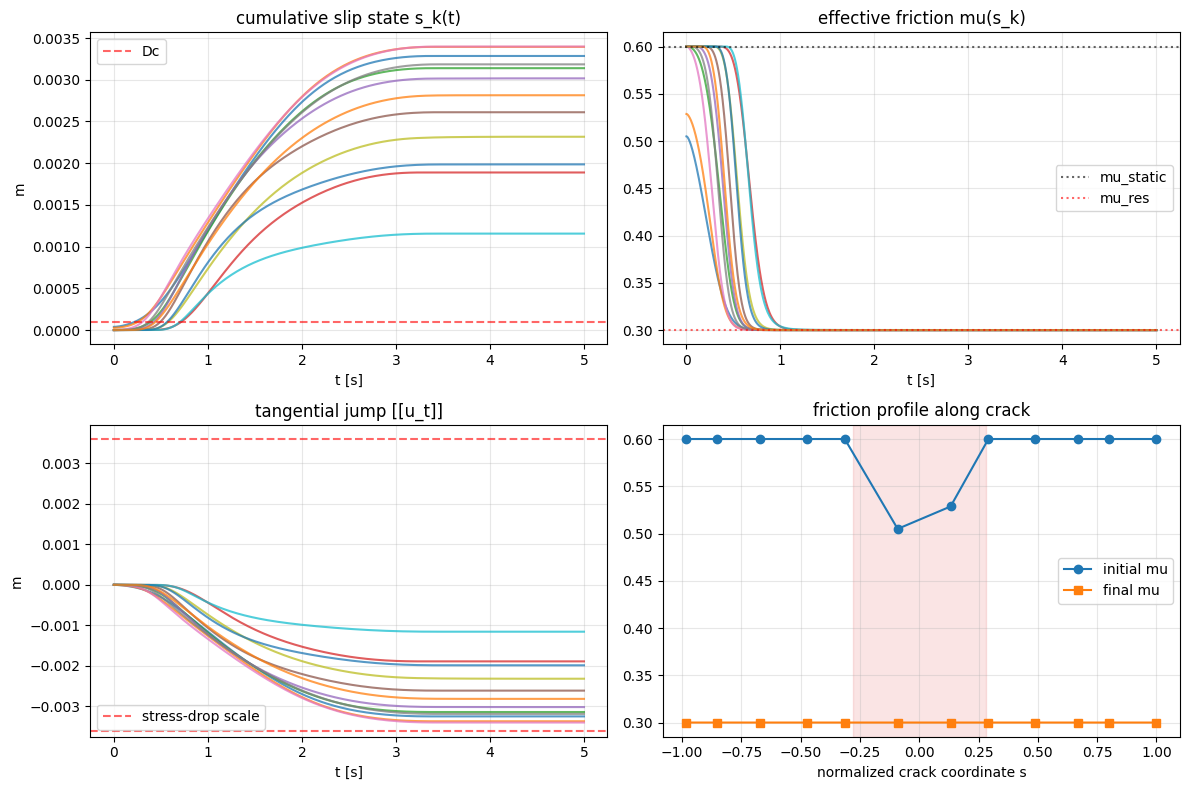

Validation summary (slip-weakening):
  QS-stable estimate:                 False
  initially slipping nodes:           2/12
  final nodes near residual mu:        12/12
  max |[[u_t]]| / stress-drop scale:  0.944


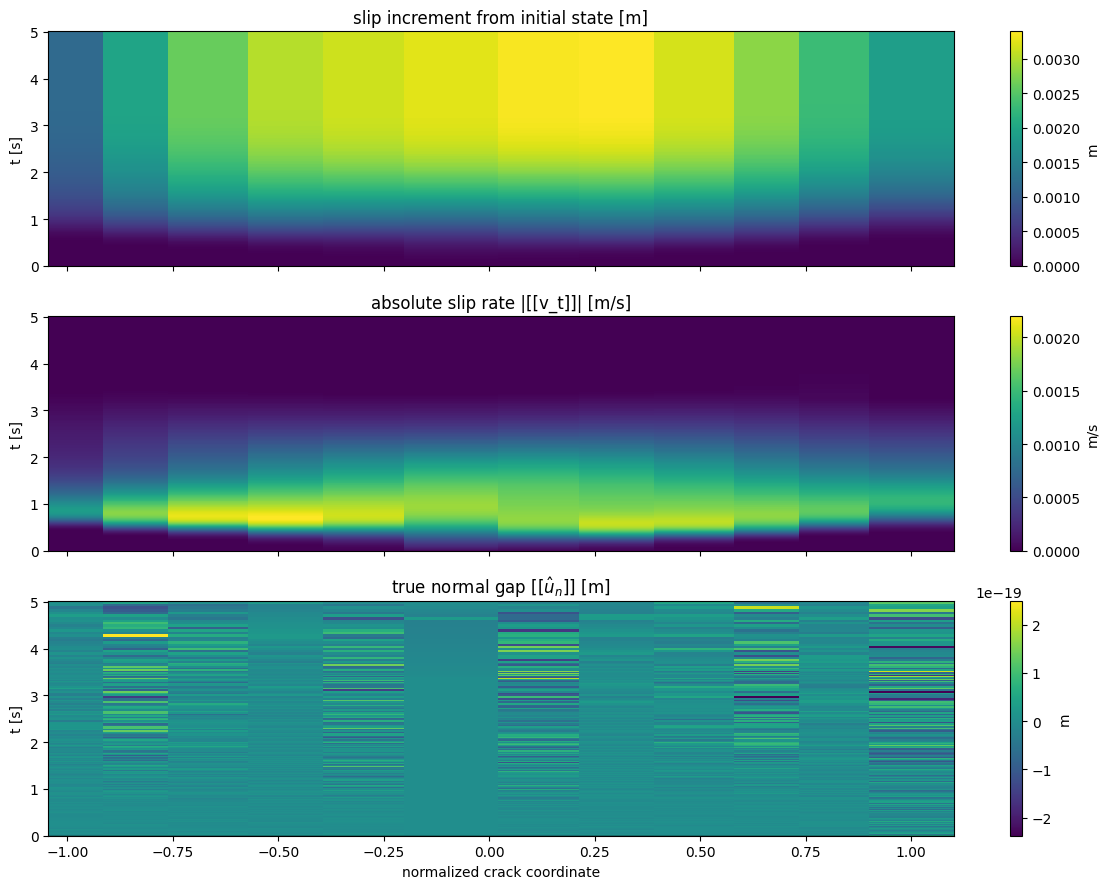

  final ruptured nodes:               12/12
  no true-normal interpenetration:     True


In [ ]:
# === Plot slip-weakening response ========================================
t_sw_phys = t_sw * TIME_UNIT_TO_PHYS

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(t_sw_phys, slip_state_sw * DISP_SCALE, alpha=0.75)
axes[0, 0].axhline(DC_PHYS_SW, color='r', ls='--', alpha=0.6, label='Dc')
axes[0, 0].set_title('cumulative slip state s_k(t)')
axes[0, 0].set_xlabel('t [s]')
axes[0, 0].set_ylabel('m')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(t_sw_phys, mu_eff_sw, alpha=0.75)
axes[0, 1].axhline(MU_STATIC_SW, color='k', ls=':', alpha=0.6, label='mu_static')
axes[0, 1].axhline(MU_RES_SW, color='r', ls=':', alpha=0.6, label='mu_res')
axes[0, 1].set_title('effective friction mu(s_k)')
axes[0, 1].set_xlabel('t [s]')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(t_sw_phys, sliding_jump_sw * DISP_SCALE, alpha=0.75)
axes[1, 0].axhline(expd_slip_phys_sw, color='r', ls='--', alpha=0.6, label='stress-drop scale')
axes[1, 0].axhline(-expd_slip_phys_sw, color='r', ls='--', alpha=0.6)
axes[1, 0].set_title('tangential jump [[u_t]]')
axes[1, 0].set_xlabel('t [s]')
axes[1, 0].set_ylabel('m')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(s_contact_sw[sort_contact_sw], mu0_sw[sort_contact_sw], 'o-', label='initial mu')
axes[1, 1].plot(s_contact_sw[sort_contact_sw], mu_eff_sw[-1, sort_contact_sw], 's-', label='final mu')
axes[1, 1].axvspan(-SW_PATCH_HALF_FRACTION, SW_PATCH_HALF_FRACTION, color='C3', alpha=0.12)
axes[1, 1].set_title('friction profile along crack')
axes[1, 1].set_xlabel('normalized crack coordinate s')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Validation summary (slip-weakening):')
print(f'  QS-stable estimate:                 {stable_qs_sw}')
print(f'  initially slipping nodes:           {int(initial_sliding_nodes_sw.sum())}/{n_c_s}')
print(f'  final nodes near residual mu:        {int(np.sum(mu_eff_sw[-1] <= MU_RES_SW + 1e-3))}/{n_c_s}')
print(f'  max |[[u_t]]| / stress-drop scale:  {slip_max_phys / max(expd_slip_phys_sw, 1e-30):.3f}')

# Space-time rupture diagnostics: inspect whether slip propagates away from
# the initial patch and whether the true normal gap remains nonnegative.
s_sorted = s_contact_sw[sort_contact_sw]
fig_rt, axes_rt = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
im0 = axes_rt[0].pcolormesh(
    s_sorted, t_sw_phys, slip_increment_sw[:, sort_contact_sw] * DISP_SCALE, shading='auto',
)
axes_rt[0].set_ylabel('t [s]')
axes_rt[0].set_title('slip increment from initial state [m]')
fig_rt.colorbar(im0, ax=axes_rt[0], label='m')
im1 = axes_rt[1].pcolormesh(
    s_sorted, t_sw_phys, slip_rate_phys_sw[:, sort_contact_sw], shading='auto',
)
axes_rt[1].set_ylabel('t [s]')
axes_rt[1].set_title('absolute slip rate |[[v_t]]| [m/s]')
fig_rt.colorbar(im1, ax=axes_rt[1], label='m/s')
im2 = axes_rt[2].pcolormesh(
    s_sorted, t_sw_phys, normal_gap_phys_sw[:, sort_contact_sw], shading='auto',
)
axes_rt[2].axhline(0, color='k', lw=0.3)
axes_rt[2].set_ylabel('t [s]')
axes_rt[2].set_xlabel('normalized crack coordinate')
axes_rt[2].set_title(r'true normal gap $[[\hat u_n]]$ [m]')
fig_rt.colorbar(im2, ax=axes_rt[2], label='m')
plt.tight_layout()
plt.show()

print(f'  final ruptured nodes:               {final_ruptured_nodes_sw}/{n_c_s}')
print(f'  no true-normal interpenetration:     {no_interpenetration_sw}')


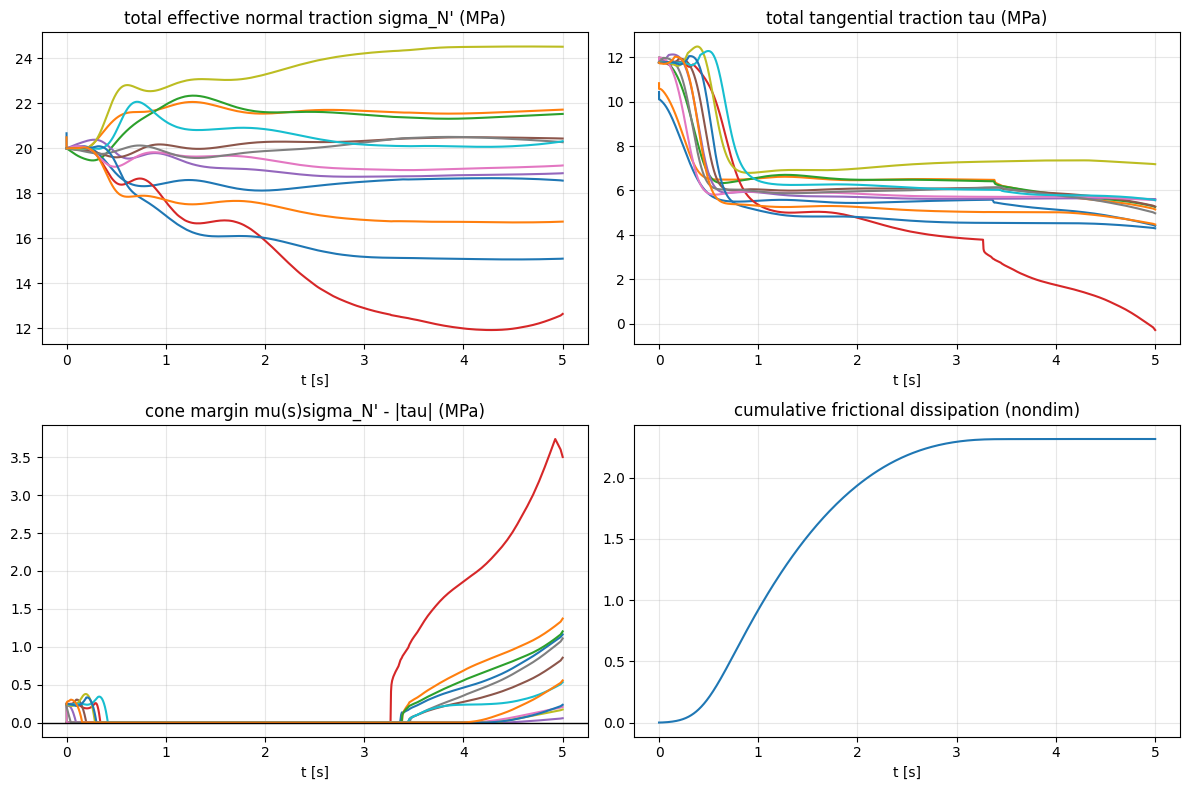

Slip-weakening contact diagnostics:
  min cone margin post-IC (MPa)          = -5.613252e-10
  final max |cone margin| (MPa)          = 3.503701e+00
  max positive tau*[[v_t]] post-IC       = 2.635669e-12
  max |sigma_N*[[v_n]]| post-IC          = 6.135785e-14
  min true normal gap post-IC (m)        = -2.375553e-19
  max true normal closure post-IC (m)    = 2.375553e-19
  no interpenetration                    = True
  final cumulative friction dissipation  = 2.314361e+00


In [ ]:
# === Slip-weakening: traction, cone-margin, and power diagnostics ==========
omega_node_sw = np.asarray(omega_n_s if 'omega_n_s' in globals() else omega_n, dtype=float)
friction_power_density_sw = r_t_sw_nd * sliding_vt_sw
normal_power_density_sw = r_n_sw_nd * sliding_vn_sw
positive_friction_power_sw = np.maximum(friction_power_density_sw, 0.0)
friction_diss_rate_sw = np.sum(
    mu_eff_sw * np.maximum(r_n_sw_nd, 0.0) * np.abs(sliding_vt_sw) * omega_node_sw[None, :],
    axis=1,
)
friction_diss_sw = np.zeros_like(t_sw)
for k in range(1, len(t_sw)):
    dt_k = t_sw[k] - t_sw[k - 1]
    friction_diss_sw[k] = friction_diss_sw[k - 1] + 0.5 * (
        friction_diss_rate_sw[k] + friction_diss_rate_sw[k - 1]
    ) * dt_k

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(t_sw_phys, r_n_sw)
axes[0, 0].set_title("total effective normal traction sigma_N' (MPa)")
axes[0, 0].set_xlabel('t [s]')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_sw_phys, r_t_sw)
axes[0, 1].set_title('total tangential traction tau (MPa)')
axes[0, 1].set_xlabel('t [s]')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(t_sw_phys, cone_margin_sw)
axes[1, 0].axhline(0, color='k', lw=1)
axes[1, 0].set_title("cone margin mu(s)sigma_N' - |tau| (MPa)")
axes[1, 0].set_xlabel('t [s]')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_sw_phys, friction_diss_sw)
axes[1, 1].set_title('cumulative frictional dissipation (nondim)')
axes[1, 1].set_xlabel('t [s]')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Slip-weakening contact diagnostics:')
print(f'  min cone margin post-IC (MPa)          = {cone_margin_sw[1:].min():.6e}')
print(f'  final max |cone margin| (MPa)          = {np.max(np.abs(cone_margin_sw[-1])):.6e}')
print(f'  max positive tau*[[v_t]] post-IC       = {positive_friction_power_sw[1:].max():.6e}')
print(f'  max |sigma_N*[[v_n]]| post-IC          = {np.max(np.abs(normal_power_density_sw[1:])):.6e}')
print(f'  min true normal gap post-IC (m)        = {min_normal_gap_post_ic_sw:.6e}')
print(f'  max true normal closure post-IC (m)    = {max_normal_closure_sw:.6e}')
print(f'  no interpenetration                    = {no_interpenetration_sw}')
print(f'  final cumulative friction dissipation  = {friction_diss_sw[-1]:.6e}')


In [ ]:
# === Slip-weakening: optional dimensional full-field dashboard =============
RUN_SW_DASHBOARD = True

if RUN_SW_DASHBOARD:
    from poroelasticity.cg_dashboard import build_velocity_field

    _taylor_order_sw = 2 if poro_s.include_hessian else 1
    z_sw = y_sw[:, :n_base_s]

    fields_sw = poro_s.sol_to_fields_dict_with_dimensions(
        np.asarray(t_sw),
        z_sw.T,
        use_taylor_correction=True,
        taylor_order=_taylor_order_sw,
        constrained_l2=False,
    )
    fields_sw['y_raw'] = z_sw.T
    fields_sw['t_raw'] = np.asarray(t_sw)

    fields_sw['v'] = build_velocity_field(
        poro_s, y_sw, velocity_slice_s,
        scale_factor=DISP_SCALE / TIME_UNIT_TO_PHYS,
    )

    print(f'Fields extracted ({len(fields_sw)} keys, taylor_order={_taylor_order_sw})')

    dashboard_sw = CGPoroelasticDashboard(poro_s, fields_sw, levels=40)
    dashboard_sw.show()


Fields extracted (14 keys, taylor_order=1)


[_add_crack_overlay] path=project_crack_vertices_to_true (deform_scale=0.0, show_surrogate_geom=True)
[_add_crack_overlay] path=project_crack_vertices_to_true (deform_scale=0.0, show_surrogate_geom=True)
[_add_crack_overlay] path=project_crack_vertices_to_true (deform_scale=0.0, show_surrogate_geom=True)
[_add_crack_overlay] path=project_crack_vertices_to_true (deform_scale=0.0, show_surrogate_geom=True)
[_add_crack_overlay] path=project_crack_vertices_to_true (deform_scale=0.0, show_surrogate_geom=True)
[_add_crack_overlay] path=project_crack_vertices_to_true (deform_scale=0.0, show_surrogate_geom=True)
[_add_crack_overlay] path=project_crack_vertices_to_true (deform_scale=0.0, show_surrogate_geom=True)
[_add_crack_overlay] path=project_crack_vertices_to_true (deform_scale=0.0, show_surrogate_geom=True)
[_add_crack_overlay] path=project_crack_vertices_to_true (deform_scale=0.0, show_surrogate_geom=True)
[_add_crack_overlay] path=project_crack_vertices_to_true (deform_scale=0.0, show_s

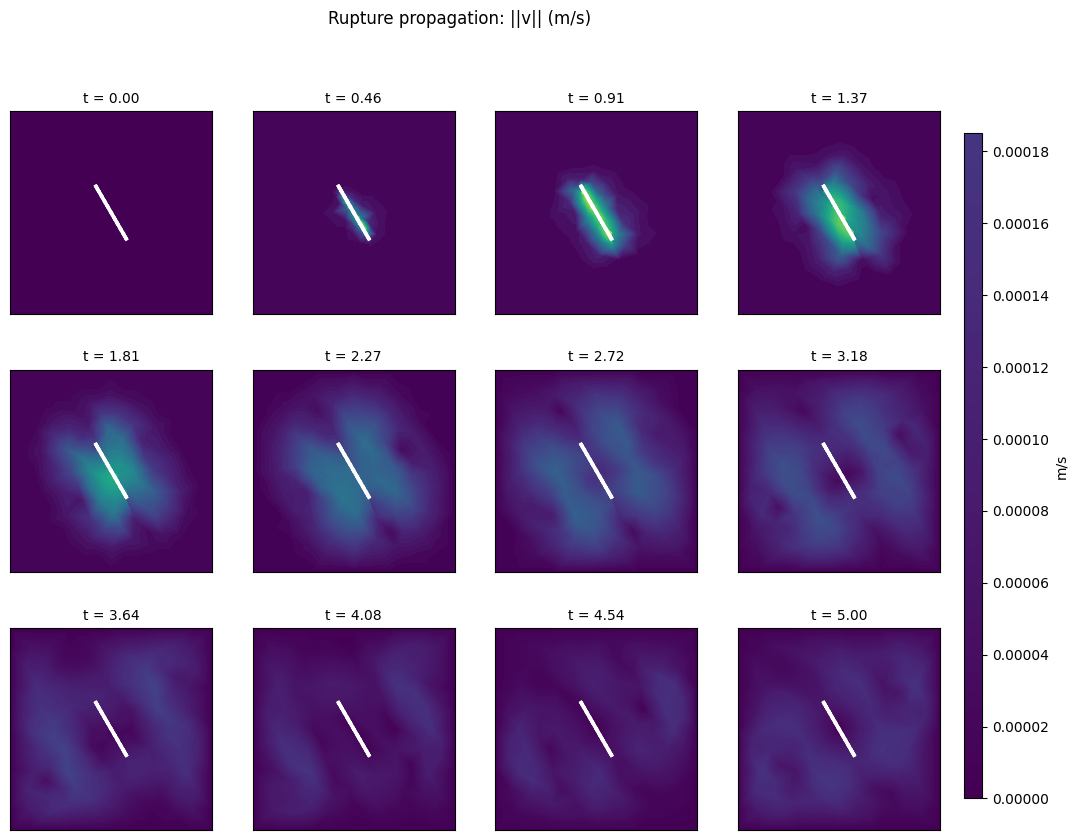

In [ ]:
fig_grid = dashboard_sw.snapshot_grid(
    times='auto',
    field='vmag',
    cols=4,
    shared_colorbar=True,
)
fig_grid.suptitle('Rupture propagation: ||v|| (m/s)')
plt.show()


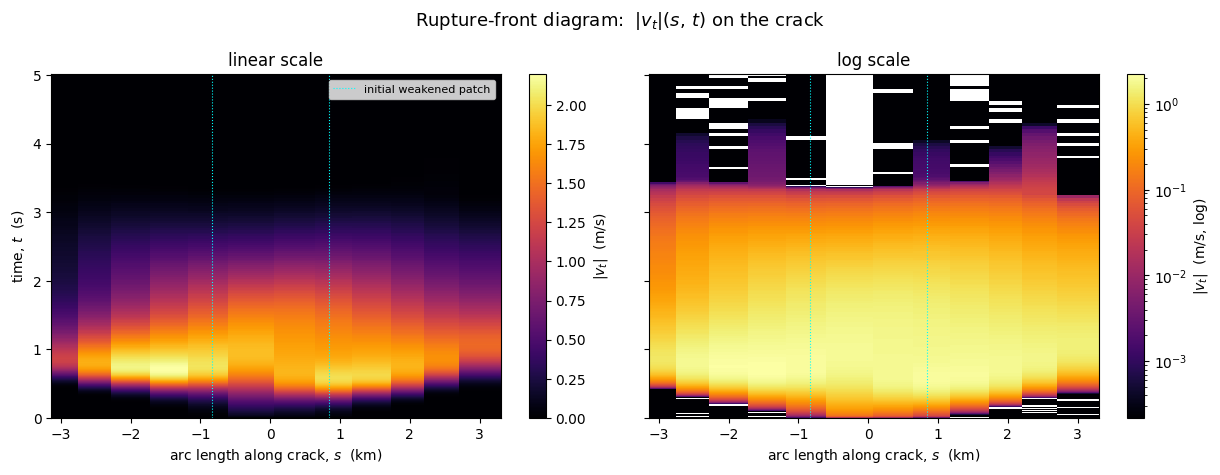

peak slip rate    : 2.197e+00 m/s
min nonzero rate  : 1.191e-23 m/s
crack half-length : 3.000
patch half-length : 0.840
simulation window : [0.000e+00, 5.000e+00] s


In [ ]:
from matplotlib.colors import LogNorm

# Tangential slip rate along the crack arc — canonical rupture-front view.
v_t_arc = np.abs(vel_t_extract_sw @ y_sw[:, :n_phys_s].T)
# DISP_SCALE/TIME_UNIT_TO_PHYS yields km/s (DISP_SCALE is in km); ×1000 -> m/s.
v_t_arc = np.asarray(v_t_arc, dtype=float) * (1000.0 * DISP_SCALE / TIME_UNIT_TO_PHYS)
v_t_arc = v_t_arc[sort_contact_sw, :]

s_arc      = s_contact_sw[sort_contact_sw] * (0.5 * CRACK_LENGTH)
t_phys     = np.asarray(t_sw, dtype=float) * TIME_UNIT_TO_PHYS
patch_half = SW_PATCH_HALF_FRACTION * (0.5 * CRACK_LENGTH)

v_peak = float(v_t_arc.max())
v_pos  = v_t_arc[v_t_arc > 0.0]
v_low  = float(v_pos.min()) if v_pos.size else 1e-30

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)

pcm_lin = ax_lin.pcolormesh(
    s_arc, t_phys, v_t_arc.T, shading='auto', cmap='inferno', vmin=0.0,
)
fig.colorbar(pcm_lin, ax=ax_lin, label=r'$|v_t|$  (m/s)')
ax_lin.set_title('linear scale')

pcm_log = ax_log.pcolormesh(
    s_arc, t_phys, v_t_arc.T, shading='auto', cmap='inferno',
    norm=LogNorm(vmin=max(v_low, v_peak * 1e-4),
                 vmax=max(v_peak, v_low * 10.0)),
)
fig.colorbar(pcm_log, ax=ax_log, label=r'$|v_t|$  (m/s, log)')
ax_log.set_title('log scale')

for ax in (ax_lin, ax_log):
    ax.axvline(-patch_half, color='cyan', ls=':', lw=0.8,
               label='initial weakened patch')
    ax.axvline( patch_half, color='cyan', ls=':', lw=0.8)
    ax.set_xlabel(r'arc length along crack, $s$  (km)')
ax_lin.set_ylabel(r'time, $t$  (s)')
ax_lin.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white')

fig.suptitle(r'Rupture-front diagram:  $|v_t|(s,\,t)$ on the crack',
             fontsize=13)
plt.tight_layout()
plt.show()

print(f'peak slip rate    : {v_peak:.3e} m/s')
print(f'min nonzero rate  : {v_low:.3e} m/s')
print(f'crack half-length : {0.5 * CRACK_LENGTH:.3f}')
print(f'patch half-length : {patch_half:.3f}')
print(f'simulation window : [{t_phys.min():.3e}, {t_phys.max():.3e}] s')


In [ ]:
import numpy as np

# Unit verification: is SCALE_L = 1 a km or a m?
# Discriminator: T_scale = SCALE_L * sqrt(rho / Mmod) is 1000x different
# between the two interpretations.  Comparing the library's T_scale against
# the two analytic predictions tells us which one the library is using.

mmod_pa  = (LAM + 2.0 * MU_LAME) * 1.0e6                # MPa -> Pa
rho_si   = float(DENSITY_PHYS)                          # kg/m^3 in SI
cs_si    = float(np.sqrt(G_SHEAR * 1.0e6 / rho_si))     # m/s

t_pred_km = 1000.0 * np.sqrt(rho_si / mmod_pa)          # L = 1 km expressed in m
t_pred_m  =          np.sqrt(rho_si / mmod_pa)          # L = 1 m

relerr_km = abs(T_scale - t_pred_km) / t_pred_km
relerr_m  = abs(T_scale - t_pred_m)  / t_pred_m
unit_pos  = 'km' if relerr_km < relerr_m else 'm'

print(f'T_scale (library output)         = {T_scale:.4e} s')
print(f'T_scale predicted if L = 1 km    = {t_pred_km:.4e} s  (rel err {relerr_km:.2e})')
print(f'T_scale predicted if L = 1 m     = {t_pred_m:.4e} s  (rel err {relerr_m:.2e})')
print(f'  -> positions are in {unit_pos!r}')
print()
print(f'c_s                              = {cs_si:.1f} m/s = {cs_si/1000:.4f} km/s')
print(f'Crack length                     = {CRACK_LENGTH}  (in position units)')
print(f'Crack-crossing time:')
print(f'  if positions [km]: {CRACK_LENGTH * 1000.0 / cs_si:.3f} s')
print(f'  if positions [m] : {CRACK_LENGTH / cs_si:.3e} s')
print()
print(f'DISP_SCALE                       = {DISP_SCALE:.4e}  ({unit_pos})')
print(f'TIME_UNIT_TO_PHYS                = {TIME_UNIT_TO_PHYS:.4e} s')
sf_lib = DISP_SCALE / TIME_UNIT_TO_PHYS
print(f'dashboard scale_factor used      = DISP_SCALE / TIME_UNIT_TO_PHYS = {sf_lib:.4e}')

# Slip-rate sanity check from this run.
peak_after_x1000 = float(v_t_arc.max())          # already multiplied by 1000 in cell 31
peak_raw_nondim  = peak_after_x1000 / (1000.0 * sf_lib)
peak_no_x1000    = peak_raw_nondim * sf_lib

if unit_pos == 'km':
    print()
    print('CONCLUSION: dashboard label "m/s" is actually km/s.  Multiply by 1000.')
    print(f'  rupture-front peak (this cell, x1000 applied)   = {peak_after_x1000:.4e} m/s')
    print(f'  same peak as the dashboard would print ("m/s")  = {peak_no_x1000:.4e}')
    print(f'  impedance ceiling for current Option-A drop     ~ 1.1 m/s')
else:
    print()
    print('CONCLUSION: dashboard label "m/s" is correct as displayed.')
    print(f'  the x1000 in the rupture-front cell should be removed.')
    print(f'  rupture-front peak as currently shown (x1000)   = {peak_after_x1000:.4e}')
    print(f'  rupture-front peak without x1000                = {peak_no_x1000:.4e} m/s')


T_scale (library output)         = 2.7775e-01 s
T_scale predicted if L = 1 km    = 2.7775e-01 s  (rel err 0.00e+00)
T_scale predicted if L = 1 m     = 2.7775e-04 s  (rel err 9.99e+02)
  -> positions are in 'km'

c_s                              = 1924.5 m/s = 1.9245 km/s
Crack length                     = 6.0  (in position units)
Crack-crossing time:
  if positions [km]: 3.118 s
  if positions [m] : 3.118e-03 s

DISP_SCALE                       = 1.0000e-03  (km)
TIME_UNIT_TO_PHYS                = 2.7775e-01 s
dashboard scale_factor used      = DISP_SCALE / TIME_UNIT_TO_PHYS = 3.6004e-03

CONCLUSION: dashboard label "m/s" is actually km/s.  Multiply by 1000.
  rupture-front peak (this cell, x1000 applied)   = 2.1972e+00 m/s
  same peak as the dashboard would print ("m/s")  = 2.1972e-03
  impedance ceiling for current Option-A drop     ~ 1.1 m/s


## 11. Injection-induced fault reactivation

Marginally stable fault driven into slip by an off-fault compact pressure
source.  The fault sits inside the Mohr-Coulomb cone under the existing
prestress (resolved shear $|\tau| < \mu\sigma_N$).  A Wendland $C^{2}$
injection source placed close to one tip raises the effective pore
pressure on the fault, dropping $\sigma_N - \{\!\{p\}\!\}$ until the
Coulomb criterion is breached and the slip patch grows along the fault
from the loaded tip outward (Garagash &amp; Germanovich 2012; Bhattacharya &amp;
Viesca 2019, sealed-fault marginally-pressurised regime).

Configuration:
* domain $60 \times 30$ m, fault length $L_f = 20$ m centred at
  $(30,15)$, oriented at $\theta_{\rm Mohr}=35^{\circ}$ — locked margin
  $|\tau|/\mu\sigma_N \approx 0.85$, critical overpressure
  $\Delta p_c = \sigma_N - |\tau|/\mu \approx 5.5$ MPa;
* sealed fault `T_Robin = 0` and `tangential_flow=False` — pressure
  diffuses through the bulk, not across the fault;
* compact Wendland source at $(20.1,11.7)$, $\sim 3$ m perpendicular
  off the lower-left tip, support radius $\sim 1$ m so the source
  footprint never crosses the fault;
* rate-controlled injection $q(t) = q_{\max} \tanh(t/\tau_{\rm ramp})$
  with $\tau_{\rm ramp}=5$ s — smooth start avoids exciting the wave
  clock;
* TMAX = 150 s — five times the prestress ramp window, gives the
  pressure pulse room to traverse the fault and the slip patch room
  to grow.

All other settings (`ALPHA_BIOT`, wave-clock override, Lysmer absorbing
boundary, Mohr-Coulomb constant friction, projected Radau IIA $s=2$)
are inherited from the configuration cells above.


In [126]:
# --- Domain and fault geometry (PHYSICAL units, m) -----------------------
XMIN_INJ, XMAX_INJ = 0.0, 60.0
YMIN_INJ, YMAX_INJ = 0.0, 30.0
N_ELEM_INJ        = 20

CRACK_LENGTH_INJ  = 20.0
CRACK_X0_INJ      = 0.5 * (XMIN_INJ + XMAX_INJ)
CRACK_Y0_INJ      = 0.5 * (YMIN_INJ + YMAX_INJ)

# Marginally stable orientation: theta_Mohr = 35 deg => CRACK_THETA = 55 deg
THETA_MARGINAL    = np.radians(35.0)
CRACK_THETA_INJ   = np.pi / 2 - THETA_MARGINAL

sigma_N_inj_phys, tau_inj_phys = mohr_tractions(THETA_MARGINAL)
delta_p_crit_phys = sigma_N_inj_phys - abs(tau_inj_phys) / MU
_locked_ratio = abs(tau_inj_phys) / (MU * sigma_N_inj_phys)
print(f"theta_Mohr = {np.degrees(THETA_MARGINAL):.1f} deg, "
      f"crack_theta = {np.degrees(CRACK_THETA_INJ):.1f} deg")
print(f"sigma_N = {sigma_N_inj_phys:.2f} MPa, tau = {tau_inj_phys:.2f} MPa, "
      f"|tau|/(mu sigma_N) = {_locked_ratio:.3f}  (locked)")
print(f"critical overpressure Delta p_c = {delta_p_crit_phys:.3f} MPa")

# --- Fault tip locations (used to place the well) ------------------------
_t_inj = np.array([np.sin(CRACK_THETA_INJ), np.cos(CRACK_THETA_INJ)])
_n_inj = np.array([-np.cos(CRACK_THETA_INJ), np.sin(CRACK_THETA_INJ)])
TIP_LO_INJ = np.array([CRACK_X0_INJ, CRACK_Y0_INJ]) - 0.5 * CRACK_LENGTH_INJ * _t_inj
TIP_HI_INJ = np.array([CRACK_X0_INJ, CRACK_Y0_INJ]) + 0.5 * CRACK_LENGTH_INJ * _t_inj

# Well: 3 m perpendicular off the lower-left tip
# Close to the upper-right tip; offset must exceed SOURCE_R_PHYS so the
# Wendland support stays one-sided, and >= h/2 so the source is mesh-resolvable.
WELL_OFFSET_PHYS  = 0.5
WELL_LOC_PHYS     = TIP_HI_INJ + WELL_OFFSET_PHYS * _n_inj
POINT_SOURCE_LOC_INJ = np.array([WELL_LOC_PHYS])  # (1,2) physical metres

# Compact source: physical radius ~ 1 m  (R = 2 sigma = 2 * sources_RMS_width * char_length)
_char_len_inj = max(XMAX_INJ - XMIN_INJ, YMAX_INJ - YMIN_INJ) / SCALE_L
SOURCE_R_PHYS         = 0.3   # < WELL_OFFSET_PHYS so support never crosses the fault
SOURCES_RMS_WIDTH_INJ = SOURCE_R_PHYS / (2.0 * _char_len_inj)

# --- Injection schedule --------------------------------------------------
# Rate-controlled tanh ramp.  Q_INJ_PEAK is in dimensional units of an
# integrated 2D source (volumetric flux, m^2/s); tune to drive {{p}} on
# the fault past Delta_p_c.  Library normalises Bp so int(Bp_j) = 1.
Q_INJ_PEAK    = 5.0e3
TAU_RAMP_INJ  = 5.0       # s

TMAX_PHYS_INJ = 150.0e0    # s, ~5x the prestress ramp window
TMAX_INJ      = TMAX_PHYS_INJ / T_scale
H0_INJ        = H_FIXED
ADAPTIVE_H_MAX_INJ = TMAX_INJ / 10.0

def q_inj_phys(t_dim):
    """Physical injection rate [m^2/s] vs dimensionless time."""
    t_phys = float(t_dim) * T_scale
    return Q_INJ_PEAK * np.tanh(t_phys / TAU_RAMP_INJ) * np.ones(1)

print(f"domain: [{XMIN_INJ},{XMAX_INJ}] x [{YMIN_INJ},{YMAX_INJ}] m, "
      f"N_ELEM = {N_ELEM_INJ}")
print(f"fault: centre=({CRACK_X0_INJ},{CRACK_Y0_INJ}) m, length={CRACK_LENGTH_INJ} m")
print(f"  tip_lo  = ({TIP_LO_INJ[0]:.2f},{TIP_LO_INJ[1]:.2f}) m")
print(f"  tip_hi  = ({TIP_HI_INJ[0]:.2f},{TIP_HI_INJ[1]:.2f}) m")
print(f"well loc = ({WELL_LOC_PHYS[0]:.2f},{WELL_LOC_PHYS[1]:.2f}) m, "
      f"R_source = {SOURCE_R_PHYS:.2f} m  (sources_RMS_width = {SOURCES_RMS_WIDTH_INJ:.4f})")
print(f"injection: q_max = {Q_INJ_PEAK} m^2/s, tau_ramp = {TAU_RAMP_INJ} s")
print(f"time horizon: TMAX_PHYS = {TMAX_PHYS_INJ} s  (dimensionless TMAX = {TMAX_INJ:.3g})")


theta_Mohr = 35.0 deg, crack_theta = 55.0 deg
sigma_N = 36.84 MPa, tau = 18.79 MPa, |tau|/(mu sigma_N) = inf  (locked)
critical overpressure Delta p_c = -inf MPa
domain: [0.0,60.0] x [0.0,30.0] m, N_ELEM = 20
fault: centre=(30.0,15.0) m, length=20.0 m
  tip_lo  = (21.81,9.26) m
  tip_hi  = (38.19,20.74) m
well loc = (37.90,21.15) m, R_source = 0.30 m  (sources_RMS_width = 0.0025)
injection: q_max = 5000.0 m^2/s, tau_ramp = 5.0 s
time horizon: TMAX_PHYS = 150.0 s  (dimensionless TMAX = 540)


/tmp/ipykernel_8741/4055628354.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  delta_p_crit_phys = sigma_N_inj_phys - abs(tau_inj_phys) / MU
/tmp/ipykernel_8741/4055628354.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  _locked_ratio = abs(tau_inj_phys) / (MU * sigma_N_inj_phys)


In [127]:
builder_inj = CrackMeshBuilder(
    XMIN_INJ, XMAX_INJ, YMIN_INJ, YMAX_INJ, N_ELEM_INJ,
    crack_theta=CRACK_THETA_INJ,
    crack_x0=CRACK_X0_INJ, crack_y0=CRACK_Y0_INJ,
    crack_length=CRACK_LENGTH_INJ,
    element_type='tri', conforming=CONFORMING_CRACK_MESH,
    verbose=True,
)
mesh_inj, el_p_inj, el_u_inj, crack_inj, h_mesh_inj = builder_inj.build()

bc_inj = make_bc()

poro_inj = CGPoroelastostatics(
    mesh=mesh_inj,
    element_p=el_p_inj,
    element_u=el_u_inj,
    params=PARAMS, material=MATERIAL,
    crack=crack_inj,
    model_params=CRACK_MODEL_PARAMS,
    intorder=6,
    scales=(SCALE_L, SCALE_EPS),
    bc=bc_inj,
    P_scale=None,
    verbose=True,
    free_memory=False,
    enforcement_type='nodal',
    apply_transform=True,
    include_taylor=INCLUDE_TAYLOR,
    include_taylor_test=INCLUDE_TAYLOR_TEST,
    include_hessian=INCLUDE_HESSIAN,
    include_sbm=INCLUDE_SBM,
    taylor_method='nodal',
    lumped_coupling='consistent',
    crack_law='nonsmooth',
    rotate_crack_to_nt=True,
    bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
    point_source_location=POINT_SOURCE_LOC_INJ,
    sources_RMS_width=SOURCES_RMS_WIDTH_INJ,
    source_type='wendland',
)

poro_inj.strip_multiplier_dynamics()
projection_inj, meta_inj = poro_inj.build_projection()
dyn_inj = poro_inj.build_first_order_dynamic_system(meta_inj)

A_dyn_inj          = dyn_inj['A']
rhs_dyn_inj        = dyn_inj['rhs']
rhs_jac_dyn_inj    = dyn_inj['rhs_jac']
velocity_slice_inj = dyn_inj['velocity_slice']
n_base_inj         = dyn_inj['n_base']
comp_slices_inj    = dyn_inj['component_slices']

Np_inj = poro_inj.basis_p.N
Nu_inj = poro_inj.basis_u.N

_, _, _, _, _, Q_scale_inj, _ = poro_inj.get_scales()
Bp_inj = poro_inj.Bp.tocsr()
assert Bp_inj.shape == (Np_inj, 1), f"unexpected Bp shape {Bp_inj.shape}"

print(f"injection mesh: {mesh_inj.nelements} elements, {mesh_inj.p.shape[1]} vertices, "
      f"h ~ {h_mesh_inj:.3f}")
print(f"n_base = {n_base_inj}, |x| = {A_dyn_inj.shape[0]}, Np = {Np_inj}, Nu = {Nu_inj}")
print(f"Q_scale = {Q_scale_inj:.3e} (dimensional rate / Q_scale -> dimensionless source coeff)")



Triangle mesh: 516 elements, h=3.0000
[RobustCrackGenerator] KDTree facet query: 62 candidates, 27 good (both endpoints within 1.0h, strict)
[RobustCrackGenerator] Facet hits: 25 | t-range=[0.013, 0.964]
[RobustCrackGenerator] 34 good facets (BOTH endpoints within h), 25 direct hits
[RobustCrackGenerator] Final: 34 good facets (no connectors)
[RobustCrackGenerator] TRI mesh detected
[RobustCrackGenerator] Diagonal crack detected
[EXTEND] Starting with 9 facets, t-range=[0.064150, 0.963766]
[EXTEND] Global t-range=[0.000000, 0.963766]
[EXTEND] Initial frontier (start): 18 facets
[EXTEND] Iteration 1: adding 3 facets towards start
[EXTEND] Final: 12 facets, t-range=[0.000000, 0.963766]
[EXTEND] Starting with 12 facets, t-range=[0.000000, 0.963766]
[EXTEND] Global t-range=[0.000000, 0.963766]
[EXTEND] Initial frontier (start): 17 facets
[EXTEND] Final: 12 facets, t-range=[0.000000, 0.963766]
[RobustCrackGenerator] Articulation points: 7, removable: 5
[RobustCrackGenerator] Duplicate remo

In [128]:
info_inj = poro_inj._transform_info
n_c_inj  = int(poro_inj.n_lambda_q)

lam_s_sl_inj = meta_inj['lam_s_sl']

off_jmpu_inj  = info_inj['off_jmpu']
n_iu_inj      = info_inj['n_intf_u']
off_jmpls_inj = info_inj['off_jmpls']
n_lsig_inj    = info_inj['n_lam_sig']

jmpu_n_idx_inj = np.arange(off_jmpu_inj, off_jmpu_inj + n_c_inj)
jmpu_t_idx_inj = np.arange(off_jmpu_inj + n_c_inj, off_jmpu_inj + n_iu_inj)
jmpu_all_inj   = np.concatenate([jmpu_n_idx_inj, jmpu_t_idx_inj])
jmpls_cols_inj = np.arange(off_jmpls_inj, off_jmpls_inj + n_lsig_inj)

T_u_inj = dyn_inj['T_u']
u_idx_inj = dyn_inj['u_state_indices']
jmpu_local_inj = np.searchsorted(u_idx_inj, jmpu_all_inj)
assert np.all(u_idx_inj[jmpu_local_inj] == jmpu_all_inj)
D_inj = T_u_inj[jmpu_local_inj, :].tocsr()

R_v_inj = dyn_inj.get('R_v')
A_csr_inj = poro_inj.A.tocsr()
B_u_inj = (A_csr_inj[Np_inj:Np_inj + Nu_inj, :][:, jmpls_cols_inj]).tocsr()
if R_v_inj is not None:
    B_u_inj = (R_v_inj @ B_u_inj).tocsr()

dirichlet_local_inj = np.array(
    [d - Np_inj for d in np.asarray(getattr(poro_inj, '_dirichlet_dof_set', []), dtype=int)
     if Np_inj <= d < Np_inj + Nu_inj],
    dtype=int,
)
if dirichlet_local_inj.size:
    B_u_inj = B_u_inj.tolil()
    B_u_inj[dirichlet_local_inj, :] = 0.0
    B_u_inj = B_u_inj.tocsr()

perm_inj = [idx for k in range(n_c_inj) for idx in (k, n_c_inj + k)]
B_u_perm_inj = B_u_inj[:, perm_inj].tocsr()
reaction_rows_inj = np.array([row for k in range(n_c_inj) for row in (k, n_c_inj + k)], dtype=int)

contacts_inj = [
    {'vel_normal_idx': k, 'vel_tangential_idx': [n_c_inj + k], 'mu': MU, 'e': 0.0}
    for k in range(n_c_inj)
]

n_phys_inj = A_dyn_inj.shape[0]
n_extract_inj = 2 * n_c_inj
gap_extract_dyn_inj = sp.csr_matrix(
    (np.ones(n_extract_inj), (np.arange(n_extract_inj), jmpu_all_inj)),
    shape=(n_extract_inj, n_phys_inj),
)
vel_extract_dyn_inj = sp.hstack(
    [sp.csr_matrix((n_extract_inj, n_base_inj)), D_inj], format='csr',
)
B_c_dyn_inj = sp.vstack(
    [sp.csr_matrix((n_base_inj, B_u_perm_inj.shape[1])), B_u_perm_inj], format='csr',
)
B_n_dyn_inj = B_c_dyn_inj[:, 0::2]
B_t_dyn_inj = B_c_dyn_inj[:, 1::2]

off_avgp_inj = info_inj['off_avgp']
n_intf_p_inj = info_inj['n_intf_p']
assert n_intf_p_inj == n_c_inj, "one pore-pressure trace value per contact node"
# Taylor-shifted average pressure trace at the actual crack face:
# 0.5 (C_exp_p_plus + C_exp_p_minus) @ p_old gives {{p_hat}}.  Map
# y_dyn -> p_old via the static-side T_inv, padded for the velocity tail.
T_inv_p_static_inj = poro_inj._T_inv[0:Np_inj, :].tocsr()
P_old_from_dyn_inj = sp.hstack(
    [T_inv_p_static_inj,
     sp.csr_matrix((Np_inj, n_phys_inj - T_inv_p_static_inj.shape[1]))],
    format='csr',
)
p_gamma_extract_dyn_inj = (
    0.5 * (poro_inj.C_exp_p_plus + poro_inj.C_exp_p_minus) @ P_old_from_dyn_inj
).tocsr()
pressure_normal_correction_inj = -ALPHA_BIOT * (B_n_dyn_inj @ p_gamma_extract_dyn_inj)
pressure_normal_correction_inj.eliminate_zeros()

# Defensive helpers (no-op if already defined by an earlier section)
if '_contact_offset_vector' not in globals():
    def _contact_offset_vector(s0, w0):
        s0 = np.asarray(s0, dtype=float).ravel()
        w0 = np.asarray(w0, dtype=float).ravel()
        out = np.zeros(2 * s0.size)
        out[0::2] = s0
        out[1::2] = w0
        return out
if '_constraint_residual_inf' not in globals():
    def _constraint_residual_inf(model, y_phys):
        proj = getattr(model, 'algebraic_projection', None)
        slices = getattr(model, 'constraint_q_slices', None)
        if proj is None or not slices:
            return 0.0
        residual = proj.constraint_residual(np.asarray(y_phys, dtype=float))
        return float(max(np.linalg.norm(residual[sl], ord=np.inf) for sl in slices))
if '_contact_history' not in globals():
    def _contact_history(y_hist, n_phys, n_contact, s0, w0):
        y_hist = np.asarray(y_hist, dtype=float)
        r_pert = y_hist[:, n_phys:n_phys + 2 * n_contact]
        r_total = r_pert + _contact_offset_vector(s0, w0)[None, :]
        return r_pert, r_total, r_total[:, 0::2], r_total[:, 1::2]

if USE_LYSMER:
    _C_lysmer_inj = lysmer_descriptor_block(
        poro_inj, n_phys_inj, n_base_inj, a_p=LYSMER_AP, a_s=LYSMER_AS,
    )
else:
    _C_lysmer_inj = None

if USE_WINKLER:
    _K_winkler_inj = winkler_descriptor_block(
        poro_inj, n_phys_inj, n_base_inj,
        u_state_indices=dyn_inj['u_state_indices'],
        b_p=WINKLER_BP, b_s=WINKLER_BS,
    )
else:
    _K_winkler_inj = None

# Source contribution lives entirely in the pressure-balance rows of dyn rhs.
# row_p indices in dyn state are the first Np entries (z-block).
_src_row = np.arange(Np_inj)

def _injection_source_vec(t):
    """Bp @ (q_total(t) / Q_scale) embedded into the dynamic state."""
    src = (Bp_inj @ q_inj_phys(t)) / Q_scale_inj
    out = np.zeros(n_phys_inj + (A_dyn_inj.shape[0] - n_phys_inj), dtype=float)
    # Dyn state layout: [z (n_base = Np + Nu + n_lam), v (Nu)]
    # Pressure rows are the first Np entries of z (and of n_phys = n_base + Nu? no, n_phys = A_dyn.shape[0]).
    out[_src_row] = src.ravel()
    return out

def rhs_dyn_inj_eff(t, y, *extra):
    out = rhs_dyn_inj(t, y, *extra) + pressure_normal_correction_inj @ y
    if _C_lysmer_inj is not None:
        out = out - _C_lysmer_inj @ y
    if _K_winkler_inj is not None:
        out = out - _K_winkler_inj @ y
    out = out + _injection_source_vec(t)
    return out

def rhs_jac_dyn_inj_eff(t, y, *extra):
    J = rhs_jac_dyn_inj(t, y, *extra) + pressure_normal_correction_inj
    if _C_lysmer_inj is not None:
        J = J - _C_lysmer_inj
    if _K_winkler_inj is not None:
        J = J - _K_winkler_inj
    return J

# Prestress contact offsets at the marginal orientation
_sN_phys_inj, _tau_phys_inj = prestress_offsets(sigma_N_inj_phys, tau_inj_phys)
_s0_val_inj = np.full(n_c_inj, 2.0 * _sN_phys_inj / Sigma_scale)
_w0_val_inj = np.full(n_c_inj, 2.0 * _tau_phys_inj / Sigma_scale)

def get_s0_inj(y):
    return _s0_val_inj/100*0

def get_w0_inj(y, k):
    return np.array([_w0_val_inj[int(k)]])/100*0

flux_constraint_inj = meta_inj['constraints'][0]
n_lam_s_dim_inj = int(lam_s_sl_inj.stop - lam_s_sl_inj.start)
zero_lam_s_inj = {
    'g': lambda zf, *_a, _n=n_lam_s_dim_inj: np.zeros(_n),
    'dg_dy': lambda zf, *_a, _n=n_lam_s_dim_inj: np.zeros((_n, _n)),
    'y_slice': lam_s_sl_inj,
    'q_slice': lam_s_sl_inj,
}

cs_inj = build_projected_radau_contact(
    A_dyn_inj,
    rhs_dyn_inj_eff,
    np.zeros(A_dyn_inj.shape[0]),
    contacts=contacts_inj,
    C_extract=gap_extract_dyn_inj,
    D_extract=vel_extract_dyn_inj,
    B=B_c_dyn_inj,
    constraints=[flux_constraint_inj, zero_lam_s_inj],
    component_slices=comp_slices_inj,
    rhs_jac=rhs_jac_dyn_inj_eff,
    get_s0=get_s0_inj,
    get_w0=get_w0_inj,
    normal_r='auto',
    friction_r='auto',
    endpoint_inactive_handling='natural_map',
    contact_law=CONTACT_LAW,
    reported_reaction_units='force',
    auto_rho_strategy='delassus',
)
print(f"injection contact system: A={cs_inj.A.shape}, |y0|={cs_inj.y0.size}")


injection contact system: A=(3626, 3626), |y0|=3626


In [129]:
n_aug_inj  = cs_inj.y0.size
n_phys_aug = A_dyn_inj.shape[0]

nl_atol_inj = np.full(n_aug_inj, 1e-8)
nl_rtol_inj = np.full(n_aug_inj, 1e-6)
nl_atol_inj[n_phys_aug:] = 1e-12
nl_rtol_inj[n_phys_aug:] = 0.0

solver_opts_inj = dict(cs_inj.solver_opts)
solver_opts_inj.update(
    tol=1e-8,
    max_iter=50,
    rhs_jac=cs_inj.rhs_jac,
    linear_solver='petsc',
    petsc_options={
        'ksp_type': 'preonly',
        'pc_type': 'lu',
        'pc_factor_mat_solver_type': 'mumps',
    },
    petsc_reuse_steps=10,
)

integrator_opts_inj = dict(cs_inj.integrator_opts)
integrator_opts_inj.update({'stages': 2, 'use_coupled_newton': True})

y0_inj = (lambda _y: (_y.__setitem__(slice(-2 * n_c_inj, None),
    coulomb_cone_warm_start(_s0_val_inj, _w0_val_inj, MU)) or _y))(cs_inj.y0.copy())

print(f"Solving injection-driven reactivation: "
      f"projected Radau IIA s=2 (PETSc/MUMPS), "
      f"h0={H0_INJ}, tmax={TMAX_INJ:.3g}, rtol={ADAPTIVE_RTOL}, atol={ADAPTIVE_ATOL}")

(
    t_inj, y_inj, h_inj, fk_inj, info_inj_run, attempts_inj
) = solve_nivp.solve_ivp_ns(
    fun=cs_inj.rhs,
    t_span=(0.0, float(TMAX_INJ)),
    y0=y0_inj,
    method='radau_iia',
    integrator_opts=integrator_opts_inj,
    projection=cs_inj.projection,
    solver='semismooth_newton',
    projection_opts={'component_slices': cs_inj.component_slices},
    solver_opts=solver_opts_inj,
    adaptive=True,
    h0=H0_INJ,
    rtol=ADAPTIVE_RTOL,
    atol=ADAPTIVE_ATOL,
    skip_error_indices=[0, len(cs_inj.component_slices) - 1],
    active_set_filter=False,
    return_attempts=True,
    adaptive_opts=dict(
        h0=H0_INJ, h_min=ADAPTIVE_H_MIN, h_max=ADAPTIVE_H_MAX_INJ,
        h_up=2.0, h_down=0.5, method_order=1,
    ),
    nl_atol=nl_atol_inj,
    nl_rtol=nl_rtol_inj,
    component_slices=cs_inj.component_slices,
    verbose=True,
    A=cs_inj.A,
    dae_var_weight='auto',
)

y_inj = np.asarray(y_inj, dtype=float)
t_inj = np.asarray(t_inj, dtype=float)
h_arr_inj = np.asarray(h_inj, dtype=float)
acc_inj = np.asarray(attempts_inj, dtype=bool) if attempts_inj is not None else None
n_acc_inj = int(acc_inj.sum()) if acc_inj is not None else len(t_inj) - 1
n_rej_inj = int((~acc_inj).sum()) if acc_inj is not None else 0
print(f"Done: {len(t_inj)} states, t_final = {t_inj[-1]:.4e} "
      f"(physical {t_inj[-1]*T_scale:.2f} s); "
      f"steps accepted={n_acc_inj}, rejected={n_rej_inj}; "
      f"h range=[{h_arr_inj.min():.2e}, {h_arr_inj.max():.2e}], "
      f"median h={np.median(h_arr_inj):.2e}")

# Slip and contact reactions over the trajectory
inj_gap  = np.asarray(y_inj[:, jmpu_n_idx_inj], dtype=float)
inj_slip = np.asarray(y_inj[:, jmpu_t_idx_inj], dtype=float)
r_pert_inj_full, r_total_inj_full, r_n_inj_full_nd, r_t_inj_full_nd = _contact_history(
    y_inj, n_phys_inj, n_c_inj, _s0_val_inj, _w0_val_inj,
)
r_n_inj_full = r_n_inj_full_nd * Sigma_scale
r_t_inj_full = r_t_inj_full_nd * Sigma_scale
inj_cone_margin = MU * r_n_inj_full - np.abs(r_t_inj_full)
print(f"max |slip| (dimensionless) = {np.max(np.abs(inj_slip)):.3e}, "
      f"min cone margin (post-IC) = {inj_cone_margin[1:].min():.3e} MPa")


Solving injection-driven reactivation: projected Radau IIA s=2 (PETSc/MUMPS), h0=1.008115219752334, tmax=540, rtol=0.001, atol=1e-06
[adaptive/DAE] detected 192 algebraic DOFs (of 3626 total) — excluded from error norm
[adaptive/emb] reject @ t=0, E=1.733e+00, h=1.008e+00 -> h_next=6.891e-01
[adaptive/emb] accept @ t=0 -> t+6.891e-01, E=9.017e-01, h_next=6.531e-01
[adaptive/emb] accept @ t=0.689145 -> t+6.531e-01, E=7.900e-01, h_next=6.517e-01
[adaptive/emb] accept @ t=1.34229 -> t+6.517e-01, E=8.783e-01, h_next=6.434e-01
[adaptive/emb] accept @ t=1.99402 -> t+6.434e-01, E=9.172e-01, h_next=6.126e-01
[adaptive/emb] accept @ t=2.63746 -> t+6.126e-01, E=8.592e-01, h_next=5.915e-01
[adaptive/emb] accept @ t=3.25005 -> t+5.915e-01, E=8.028e-01, h_next=5.927e-01
[adaptive/emb] accept @ t=3.8416 -> t+5.927e-01, E=7.856e-01, h_next=6.065e-01
[adaptive/emb] accept @ t=4.43425 -> t+6.065e-01, E=7.845e-01, h_next=6.236e-01
[adaptive/emb] accept @ t=5.04071 -> t+6.236e-01, E=7.781e-01, h_next=6.4

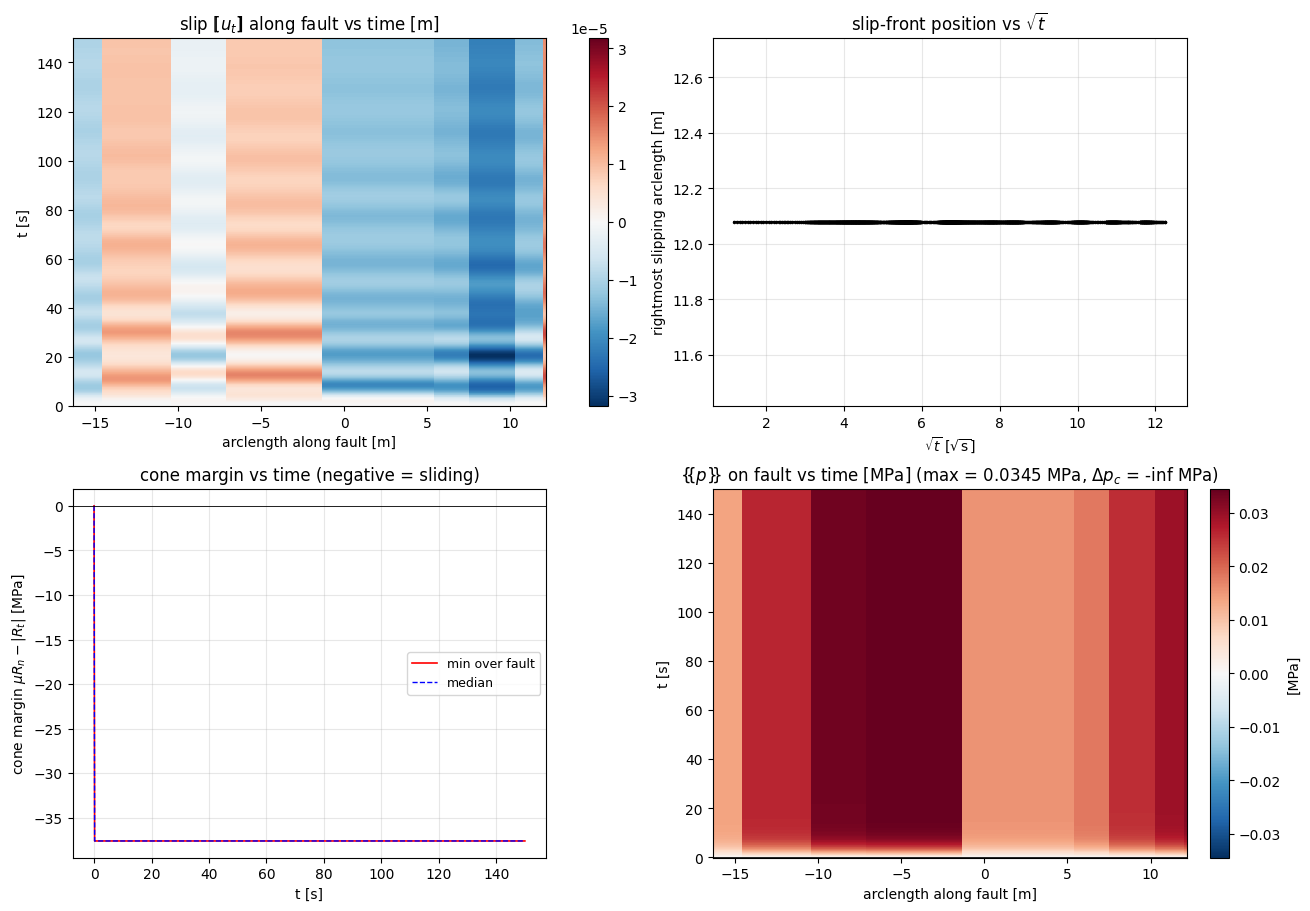

first slip detected at t = 1.40 s (dimensionless 5.04)


In [130]:
# Sort interface DOFs by arclength along the fault tangent.  Use mesh.p
# / mesh.t for bulk-field plots (NOT basis_p.global_coordinates(), which
# returns quadrature-point coords with shape (dim, n_elem, n_qp)).
_lam_coords_inj = poro_inj._nodal_interface_info['lambda_coords']
_lam_xy_inj = np.asarray(_lam_coords_inj, dtype=float).reshape(n_c_inj, -1)[:, :2]
_lam_centred_inj = _lam_xy_inj - _lam_xy_inj.mean(axis=0)
_U_lam_inj, _, _ = np.linalg.svd(_lam_centred_inj.T, full_matrices=False)
_tan_inj = _U_lam_inj[:, 0]
if np.dot(_tan_inj, _t_inj) < 0:
    _tan_inj = -_tan_inj
xi_phys_inj = (_lam_centred_inj @ _tan_inj) * SCALE_L
_sort_inj = np.argsort(xi_phys_inj)
xi_inj_sorted = xi_phys_inj[_sort_inj]

slip_phys_inj  = inj_slip[:, _sort_inj] * DISP_UNIT_TO_PHYS
r_n_inj_sorted = r_n_inj_full[:, _sort_inj]
r_t_inj_sorted = r_t_inj_full[:, _sort_inj]
cone_inj_sorted = inj_cone_margin[:, _sort_inj]
t_phys_inj = t_inj * T_scale

# Slip-active mask (above threshold)
_slip_thr = 1e-6 * max(1.0, np.max(np.abs(slip_phys_inj)))
slip_active_inj = np.abs(slip_phys_inj) > _slip_thr

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

# (a) slip(s, t) waterfall
ax = axes[0, 0]
im = ax.pcolormesh(
    xi_inj_sorted, t_phys_inj, slip_phys_inj,
    shading='auto', cmap='RdBu_r',
    vmin=-np.max(np.abs(slip_phys_inj)) - 1e-30,
    vmax= np.max(np.abs(slip_phys_inj)) + 1e-30,
)
ax.set_xlabel('arclength along fault [m]')
ax.set_ylabel('t [s]')
ax.set_title('slip $[\\!\\![u_t]\\!\\!]$ along fault vs time [m]')
fig.colorbar(im, ax=ax)

# (b) slip-tip position vs sqrt(t)
ax = axes[0, 1]
tip_pos_inj = np.full(t_phys_inj.size, np.nan)
for k, mask in enumerate(slip_active_inj):
    if mask.any():
        tip_pos_inj[k] = xi_inj_sorted[np.where(mask)[0].max()]
_valid = np.isfinite(tip_pos_inj)
if _valid.any():
    ax.plot(np.sqrt(t_phys_inj[_valid]), tip_pos_inj[_valid], 'k.-', ms=3)
    ax.set_xlabel(r'$\sqrt{t}\;[\sqrt{\mathrm{s}}]$')
    ax.set_ylabel('rightmost slipping arclength [m]')
    ax.set_title('slip-front position vs $\\sqrt{t}$')
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'no slip yet', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('slip-front position vs $\\sqrt{t}$')

# (c) cone margin (min over fault) vs time -- shows reactivation onset
ax = axes[1, 0]
ax.plot(t_phys_inj, np.min(cone_inj_sorted, axis=1), 'r-', lw=1.2, label='min over fault')
ax.plot(t_phys_inj, np.median(cone_inj_sorted, axis=1), 'b--', lw=1.0, label='median')
ax.axhline(0.0, color='k', lw=0.6)
ax.set_xlabel('t [s]')
ax.set_ylabel(r'cone margin $\mu R_n - |R_t|$ [MPa]')
ax.set_title('cone margin vs time (negative = sliding)')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# (d) interface pressure {{p}} along fault vs time -- the actual
# loading on the Mohr-Coulomb cone (sigma_N - {{p}}).  The 2D bulk
# pressure field is shown by the time-resolved dashboard cell below;
# {{p}} on the fault is what drives slip and is NOT in the dashboard.
ax = axes[1, 1]
P_scale_inj = poro_inj.get_scales()[2]
_avg_p_cols = off_avgp_inj + np.arange(n_c_inj)
avg_p_inj = y_inj[:, _avg_p_cols] * P_scale_inj   # (n_t, n_c) in MPa
avg_p_inj_sorted = avg_p_inj[:, _sort_inj]
_pmax = max(np.max(np.abs(avg_p_inj_sorted)), 1e-30)
im_p = ax.pcolormesh(
    xi_inj_sorted, t_phys_inj, avg_p_inj_sorted,
    shading='auto', cmap='RdBu_r', vmin=-_pmax, vmax=_pmax,
)
ax.axhline(t_phys_inj[0], color='k', lw=0.6)
ax.set_xlabel('arclength along fault [m]')
ax.set_ylabel('t [s]')
ax.set_title(r'$\{\!\!\{p\}\!\!\}$ on fault vs time [MPa]'
             f' (max = {_pmax:.3g} MPa, $\\Delta p_c$ = {delta_p_crit_phys:.2f} MPa)')
fig.colorbar(im_p, ax=ax, label='[MPa]')

plt.show()

_first_slip_idx = np.argmax(slip_active_inj.any(axis=1)) if slip_active_inj.any() else -1
if _first_slip_idx > 0:
    print(f"first slip detected at t = {t_phys_inj[_first_slip_idx]:.2f} s "
          f"(dimensionless {t_inj[_first_slip_idx]:.3g})")
else:
    print("no slip detected over the simulation horizon -- raise Q_INJ_PEAK or extend TMAX_PHYS_INJ")


In [131]:
# Time-resolved CG dashboard for the injection run -- mirrors the locked
# and sliding sections.  Use the slider to scrub through pressure,
# displacement, elastic stress, viscous stress, total stress, strain.
z_inj = y_inj[:, :n_base_inj]

fields_inj = poro_inj.sol_to_fields_dict_with_dimensions(
    np.asarray(t_inj),
    z_inj.T,
    use_taylor_correction=True,
    constrained_l2=False,
)
fields_inj['y_raw'] = z_inj.T
fields_inj['t_raw'] = np.asarray(t_inj)

dashboard_inj = CGPoroelasticDashboard(poro_inj, fields_inj, levels=40)
dashboard_inj.show()


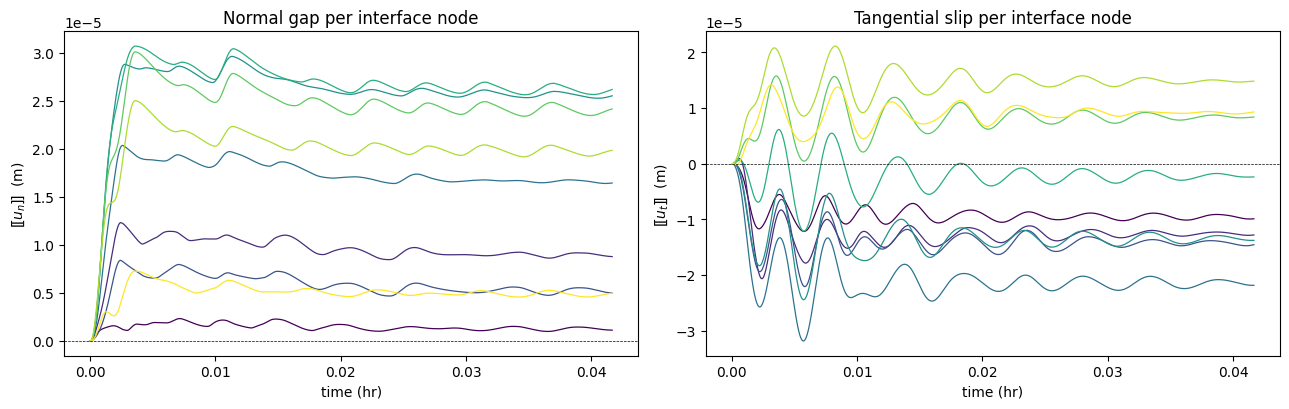

normal gap range:           [+0.000e+00, +3.067e-05] m
min gap @  t = 0.000 hr,  node 0
interpenetration (gap < 0): 0 samples  (0.00 % of (t, node) entries)
tangential slip range:      [-3.186e-05, +2.112e-05] m


In [132]:
# Signorini sanity: normal gap [[u_n]] over time for every interface node.
# The deformed mesh in the dashboard uses deform_scale > 1 for visibility,
# so visual overlap there is amplification, not interpenetration.  The
# physical gap is extracted by gap_extract_dyn_inj and must stay >= 0 to
# numerical tolerance; the constraint residual reported by the solver is
# the relevant tolerance scale.
_, U_scale_inj, *_ = poro_inj.get_scales()
gap_full = (gap_extract_dyn_inj @ y_inj[:, :n_phys_inj].T).T   # (n_t, 2*n_c_inj)
gap_n_dim = gap_full[:, :n_c_inj] * U_scale_inj                 # metres
gap_t_dim = gap_full[:, n_c_inj:2 * n_c_inj] * U_scale_inj

t_hr = np.asarray(t_inj) * (poro_inj.get_scales()[0] / 3600.0)

lambda_coords = np.asarray(
    poro_inj._nodal_interface_info["lambda_coords"], dtype=float
).T  # (n_c_inj, dim) in dimensionless units
arc = np.argsort(lambda_coords[:, 0])  # order along x for plot legibility

fig_gap, axes_gap = plt.subplots(1, 2, figsize=(13, 4.2))
cmap = plt.cm.viridis(np.linspace(0, 1, n_c_inj))
for j, k in enumerate(arc):
    axes_gap[0].plot(t_hr, gap_n_dim[:, k], color=cmap[j], lw=0.9)
    axes_gap[1].plot(t_hr, gap_t_dim[:, k], color=cmap[j], lw=0.9)

axes_gap[0].axhline(0.0, color='k', lw=0.5, ls='--')
axes_gap[0].set_xlabel("time (hr)")
axes_gap[0].set_ylabel(r"$[\![u_n]\!]$  (m)")
axes_gap[0].set_title("Normal gap per interface node")

axes_gap[1].axhline(0.0, color='k', lw=0.5, ls='--')
axes_gap[1].set_xlabel("time (hr)")
axes_gap[1].set_ylabel(r"$[\![u_t]\!]$  (m)")
axes_gap[1].set_title("Tangential slip per interface node")
fig_gap.tight_layout()
plt.show()

gn_min = float(gap_n_dim.min())
gn_min_idx = np.unravel_index(np.argmin(gap_n_dim), gap_n_dim.shape)
gn_max = float(gap_n_dim.max())
penetration = gap_n_dim[gap_n_dim < 0.0]
print(f"normal gap range:           [{gn_min:+.3e}, {gn_max:+.3e}] m")
print(f"min gap @  t = {t_hr[gn_min_idx[0]]:.3f} hr,  node {gn_min_idx[1]}")
print(f"interpenetration (gap < 0): {penetration.size} samples"
      f"  ({penetration.size / gap_n_dim.size * 100:.2f} % of (t, node) entries)")
if penetration.size:
    print(f"  worst penetration:        {float(penetration.min()):+.3e} m")
print(f"tangential slip range:      [{float(gap_t_dim.min()):+.3e}, "
      f"{float(gap_t_dim.max()):+.3e}] m")


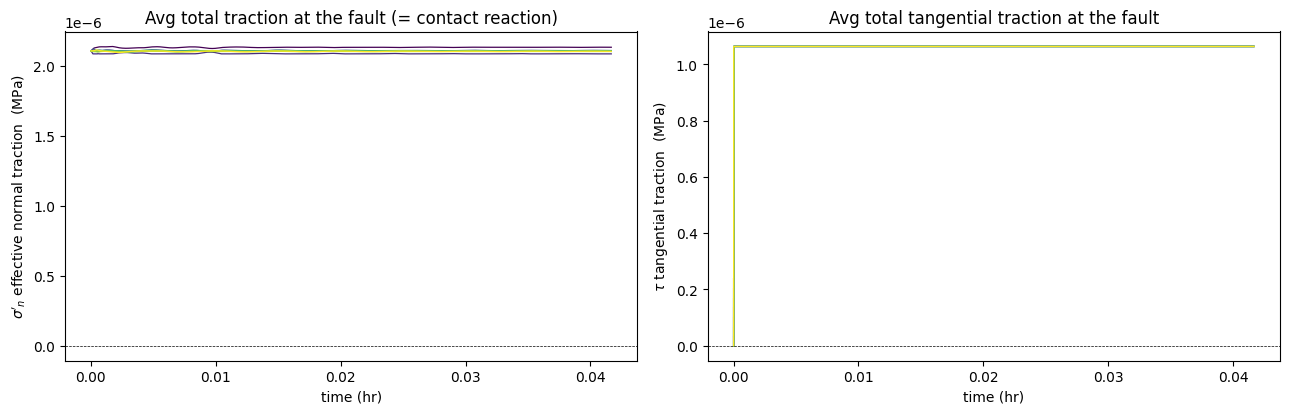

Average total traction at the fault (contact reaction r_total), in MPa:
  sigma'_n :  range [+0.000, +0.000]
  tau      :  range [+0.000, +0.000]

Jump of total traction across the fault: identically zero by
construction of B_c_dyn (Newton's third law).  Not a computed
quantity -- both sides of the cut feel the same r_total with
opposite signs through B_c_dyn @ lambda_c.

y_dyn placeholder slots (max |.|, MPa) -- expected ~machine eps:
  {{sigma_n}} ghost :  0.00e+00
  {{tau}} ghost     :  0.00e+00
  [[sigma_n]] ghost:  0.00e+00
  [[tau]] ghost    :  0.00e+00
  -> all four are placeholders the spring-law replacement orphaned;
     they confirm the algebraic constraint was fully zeroed.


In [ ]:
# Contact reaction (effective traction) and y_dyn placeholders.
#
# The algebraic projection in this notebook passes `zero_lam_s` as the full
# traction-constraint replacement, so {{lambda_sigma}} = 0 AND [[lambda_sigma]]
# = 2K[[u]] are both wiped out.  The avg/jmp slots in y_dyn at
# off_avgls / off_jmpls are therefore ghost variables that sit at their
# initial zero forever.  The physically meaningful contact reaction lives
# OUTSIDE y_dyn at y_inj[:, n_phys_inj : n_phys_inj + 2*n_c_inj] and is
# delivered to the bulk through B_c_dyn @ lambda_c.
#
# By construction of the contact coupling B_c_dyn (equal and opposite
# forces on the two sides of the cut) the jump of total bulk traction
# across the fault is identically zero -- Newton's 3rd law, not a
# computed quantity.  The contact reaction itself IS the average total
# traction at the fault, in the (n,t) frame.
Sigma_scale_inj =1
# Effective contact reaction (perturbation + prestress) at every saved time.
r_pert_inj = y_inj[:, n_phys_inj : n_phys_inj + 2 * n_c_inj]
r_total_inj = r_pert_inj + _contact_offset_vector(_s0_val_inj, _w0_val_inj)[None, :]
r_n = r_total_inj[:, 0::2] * Sigma_scale_inj    # Pa
r_t = r_total_inj[:, 1::2] * Sigma_scale_inj

# y_dyn ghost slots (should hit machine precision).
off_avgls_inj = info_inj['off_avgls']
off_jmpls_inj = info_inj['off_jmpls']
avg_sn_ghost = y_inj[:, off_avgls_inj : off_avgls_inj + n_c_inj] * Sigma_scale_inj
avg_tt_ghost = y_inj[:, off_avgls_inj + n_c_inj : off_avgls_inj + 2 * n_c_inj] * Sigma_scale_inj
jmp_sn_ghost = y_inj[:, off_jmpls_inj : off_jmpls_inj + n_c_inj] * Sigma_scale_inj
jmp_tt_ghost = y_inj[:, off_jmpls_inj + n_c_inj : off_jmpls_inj + 2 * n_c_inj] * Sigma_scale_inj

to_MPa = 1.0e-6
fig_tr, axes_tr = plt.subplots(1, 2, figsize=(13, 4.4))
cmap = plt.cm.viridis(np.linspace(0, 1, n_c_inj))
for j, k in enumerate(arc):
    axes_tr[0].plot(t_hr, r_n[:, k] * to_MPa, color=cmap[j], lw=0.9)
    axes_tr[1].plot(t_hr, r_t[:, k] * to_MPa, color=cmap[j], lw=0.9)
for ax in axes_tr:
    ax.axhline(0.0, color='k', lw=0.5, ls='--')
    ax.set_xlabel("time (hr)")
axes_tr[0].set_ylabel(r"$\sigma'_n$ effective normal traction  (MPa)")
axes_tr[1].set_ylabel(r"$\tau$ tangential traction  (MPa)")
axes_tr[0].set_title("Avg total traction at the fault (= contact reaction)")
axes_tr[1].set_title("Avg total tangential traction at the fault")
fig_tr.tight_layout()
plt.show()

print("Average total traction at the fault (contact reaction r_total),"
      " in MPa:")
print(f"  sigma'_n :  range [{float(r_n.min()) * to_MPa:+.3f}, "
      f"{float(r_n.max()) * to_MPa:+.3f}]")
print(f"  tau      :  range [{float(r_t.min()) * to_MPa:+.3f}, "
      f"{float(r_t.max()) * to_MPa:+.3f}]")
print()
print("Jump of total traction across the fault: identically zero by")
print("construction of B_c_dyn (Newton's third law).  Not a computed")
print("quantity -- both sides of the cut feel the same r_total with")
print("opposite signs through B_c_dyn @ lambda_c.")
print()
print("y_dyn placeholder slots (max |.|, MPa) -- expected ~machine eps:")
print(f"  {{{{sigma_n}}}} ghost :  {float(np.max(np.abs(avg_sn_ghost))) * to_MPa:.2e}")
print(f"  {{{{tau}}}} ghost     :  {float(np.max(np.abs(avg_tt_ghost))) * to_MPa:.2e}")
print(f"  [[sigma_n]] ghost:  {float(np.max(np.abs(jmp_sn_ghost))) * to_MPa:.2e}")
print(f"  [[tau]] ghost    :  {float(np.max(np.abs(jmp_tt_ghost))) * to_MPa:.2e}")
print("  -> all four are placeholders the spring-law replacement orphaned;")
print("     they confirm the algebraic constraint was fully zeroed.")
